In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xmm_py_spec import plotting_settings
plotting_settings.set_mpl()

In [2]:
target_columns = [
 'src_num',
 'obs_id',
 'ons_start_date',
 'pn_ontime',
 'm1_ontime',
 'm2_ontime']


In [4]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_results.csv')
src_5359_M1_df = pd.read_csv('../data/source_201237001010017_5359_individual_M1_results.csv')
# src_5359_clustered_df = pd.read_csv('../data/source_201237001010017_5359_clustered_results.csv')
# # src_5359_old_df = pd.read_csv('../data/source_201237001010017_5359_results_old.csv')
# src_1430_df = pd.read_csv('../data/source_201237001015028_1430_results.csv')
# src_7170_df = pd.read_csv('../data/source_201237001015035_7170_results.csv')

In [8]:
def old_plot_date_gamma(
        df, title, color, ax=None, pad=False, lolim=-0.5, uplim=3.1, alpha=.5
    ):

    if not ax:
        _, ax = plt.subplots(figsize=(10, 6))

    df['date_obs'] = pd.to_datetime(df['date_obs']).dt.floor('D')

    # Add date formatter
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    padding = pd.Timedelta(days=50)  # Add 30 days padding on each side

    x_delta = pd.Timedelta(days=-15) if pad else pd.Timedelta(days=0)

    ax.errorbar(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        yerr=[df['mo2_PhoIndex_step_2d_nerr'], df['mo2_PhoIndex_step_2d_perr']],
        fmt='o', markersize=0, alpha=alpha, capsize=4, capthick=1.5, ecolor=color,
        lw=2, label=title
        )

    ax.scatter(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        s=3, zorder=5, color='k'
        )

    ax.set_ylim(lolim, uplim)
    ax.set_xlim(
        pd.to_datetime('2000-04-27 03:34:45') - padding,
        pd.to_datetime('2002-12-04 04:47:08') + padding
    )
    ax.axhline(1.4, color='gray', ls='--', alpha=0.3)

    ax.set_ylabel('Г')

    ax.tick_params(axis='x', which='minor', length=0)
    ax.tick_params(axis='x', which='major', length=2)

    # ax.set_title(f'srcid {title}; ph*zph*zpo', loc='left')

    ax.legend(loc='upper left')

    plt.xticks(rotation=70)

    # plt.show()

    return ax

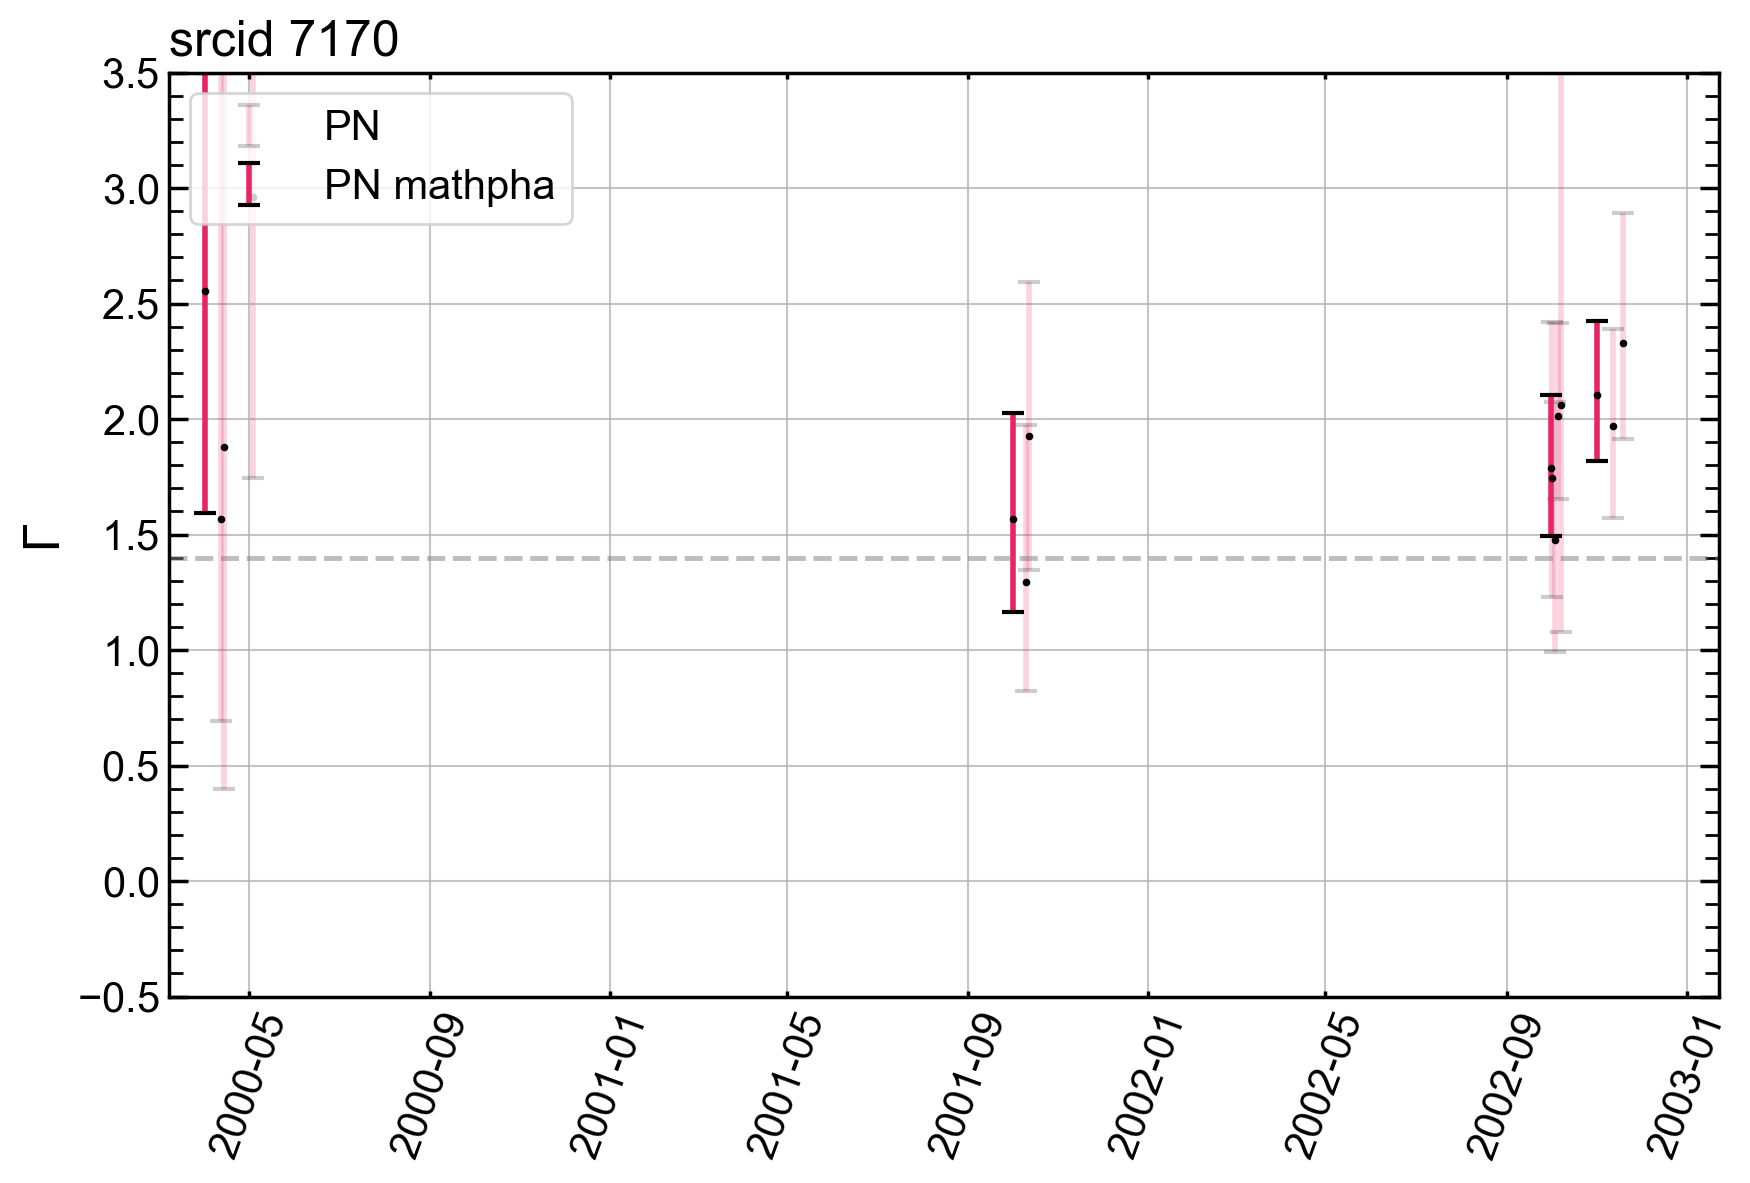

In [9]:
src_7170_PN_df = pd.read_csv('../data/source_201237001015035_7170_individual_PN_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_7170_PN_df, "PN", color='C1', alpha=0.2, pad=True, uplim=3.5)

src_7170_PN_addspec_df = pd.read_csv('../data/source_201237001015035_7170_clustered_PN_gap30_addspec_results.csv')
old_plot_date_gamma(src_7170_PN_addspec_df, "PN mathpha", color='C1', alpha=1, ax=ax, uplim=3.5)

ax.set_title('srcid 7170', loc='left')

plt.show()

# src_7170_PN_sascombine_df = pd.read_csv('../data/source_201237001015035_7170_clustered_PN_gap30_epicspeccombine_results.csv')
# old_plot_date_gamma(src_7170_PN_sascombine_df, "sascombine", color='C1', alpha=1, ax=ax, uplim=4)

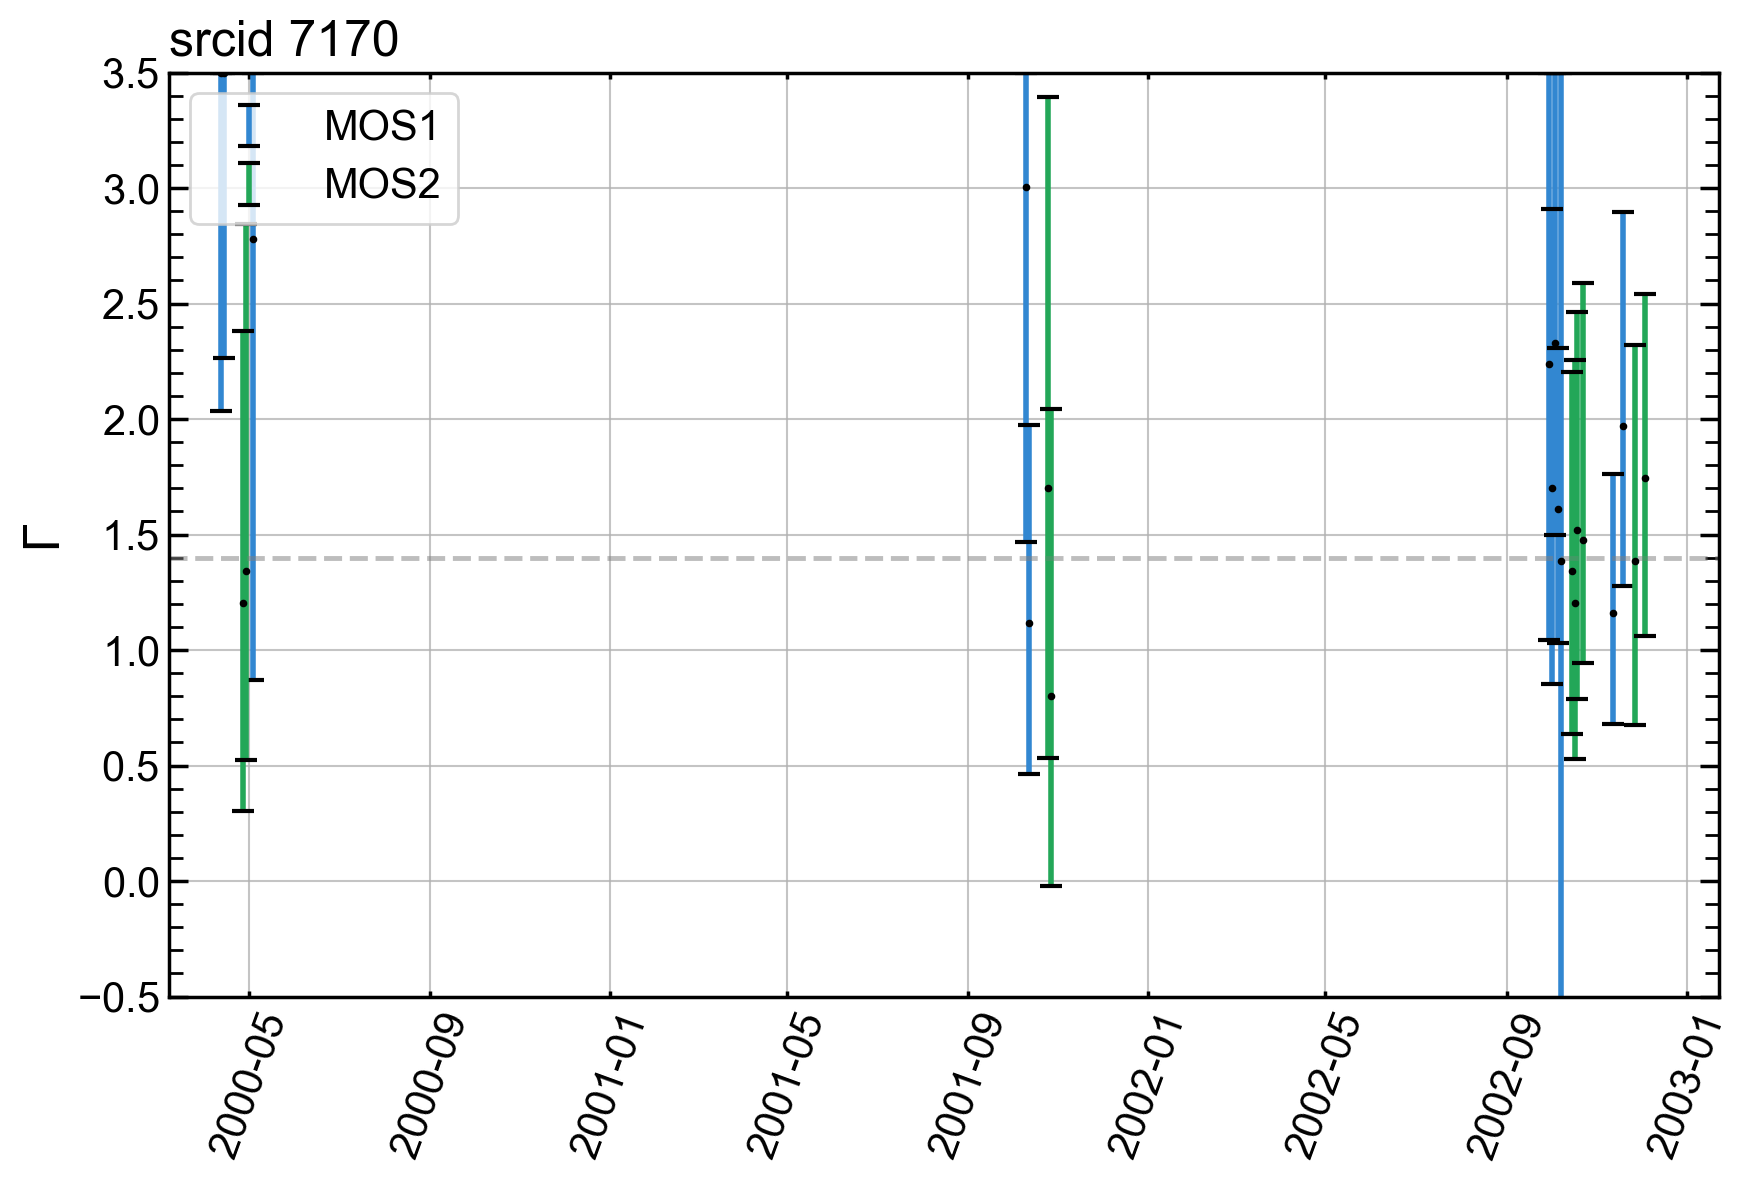

In [10]:
src_7170_PN_df = pd.read_csv('../data/source_201237001015035_7170_individual_M1_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_7170_PN_df, "MOS1", color='C0', alpha=1, pad=True, uplim=3.5)

src_7170_PN_addspec_df = pd.read_csv('../data/source_201237001015035_7170_individual_M2_gap30_epicspeccombine_results.csv')
old_plot_date_gamma(src_7170_PN_addspec_df, "MOS2", color='C2', alpha=1, ax=ax, uplim=3.5)

ax.set_title('srcid 7170', loc='left')

plt.show()

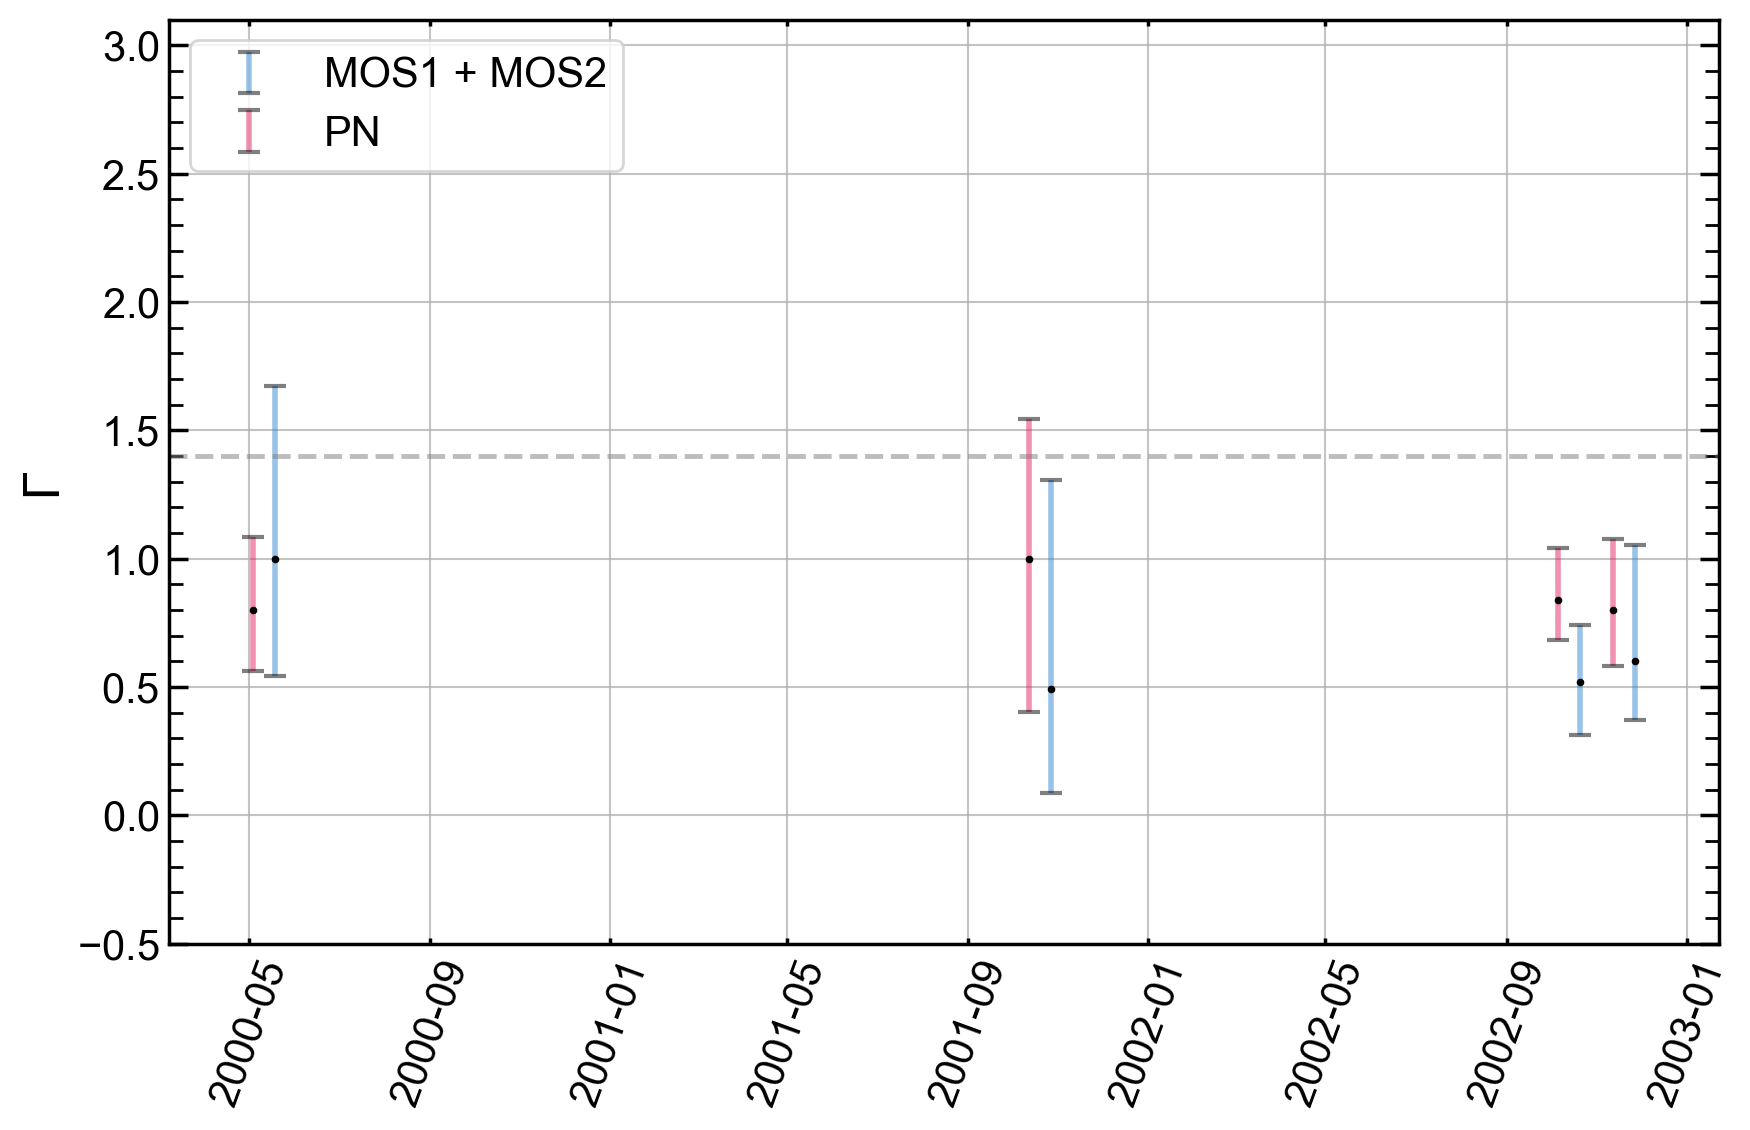

In [11]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_MOS_gap30_results.csv')
ax = old_plot_date_gamma(src_5359_df, 'MOS1 + MOS2', color='C0')

src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_results.csv')
ax = old_plot_date_gamma(src_5359_df, "PN", color='C1', ax=ax, pad=True)

# ax.set_title("srcid 5359 | PN and MOS1 + MOS2 clustered; ph*zph*zpo", loc='left')

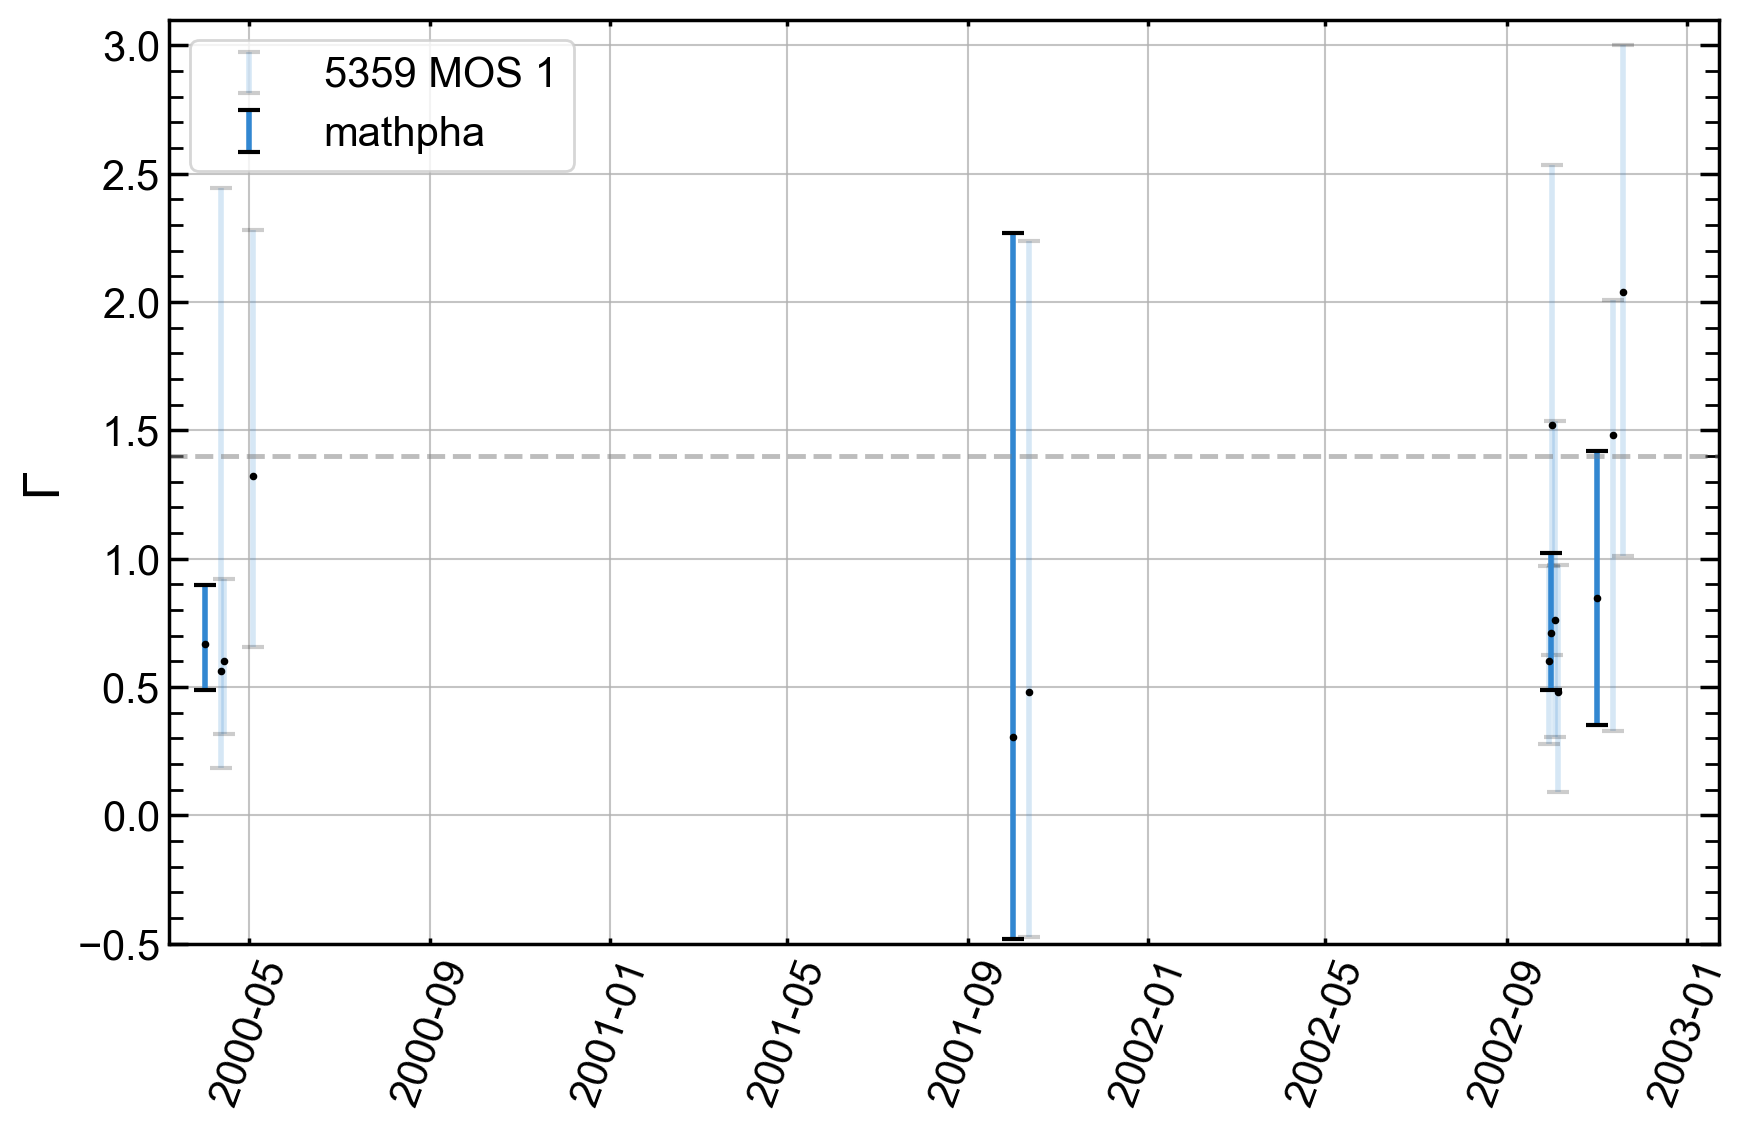

In [12]:
src_5359_M1_df = pd.read_csv('../data/source_201237001010017_5359_individual_M1_results.csv')
ax = old_plot_date_gamma(src_5359_M1_df, "5359 MOS 1", color='C0', alpha=0.2, pad=True)

src_5359_M1_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_5359_M1_addspec_df, "mathpha", color='C0', alpha=1, ax=ax)

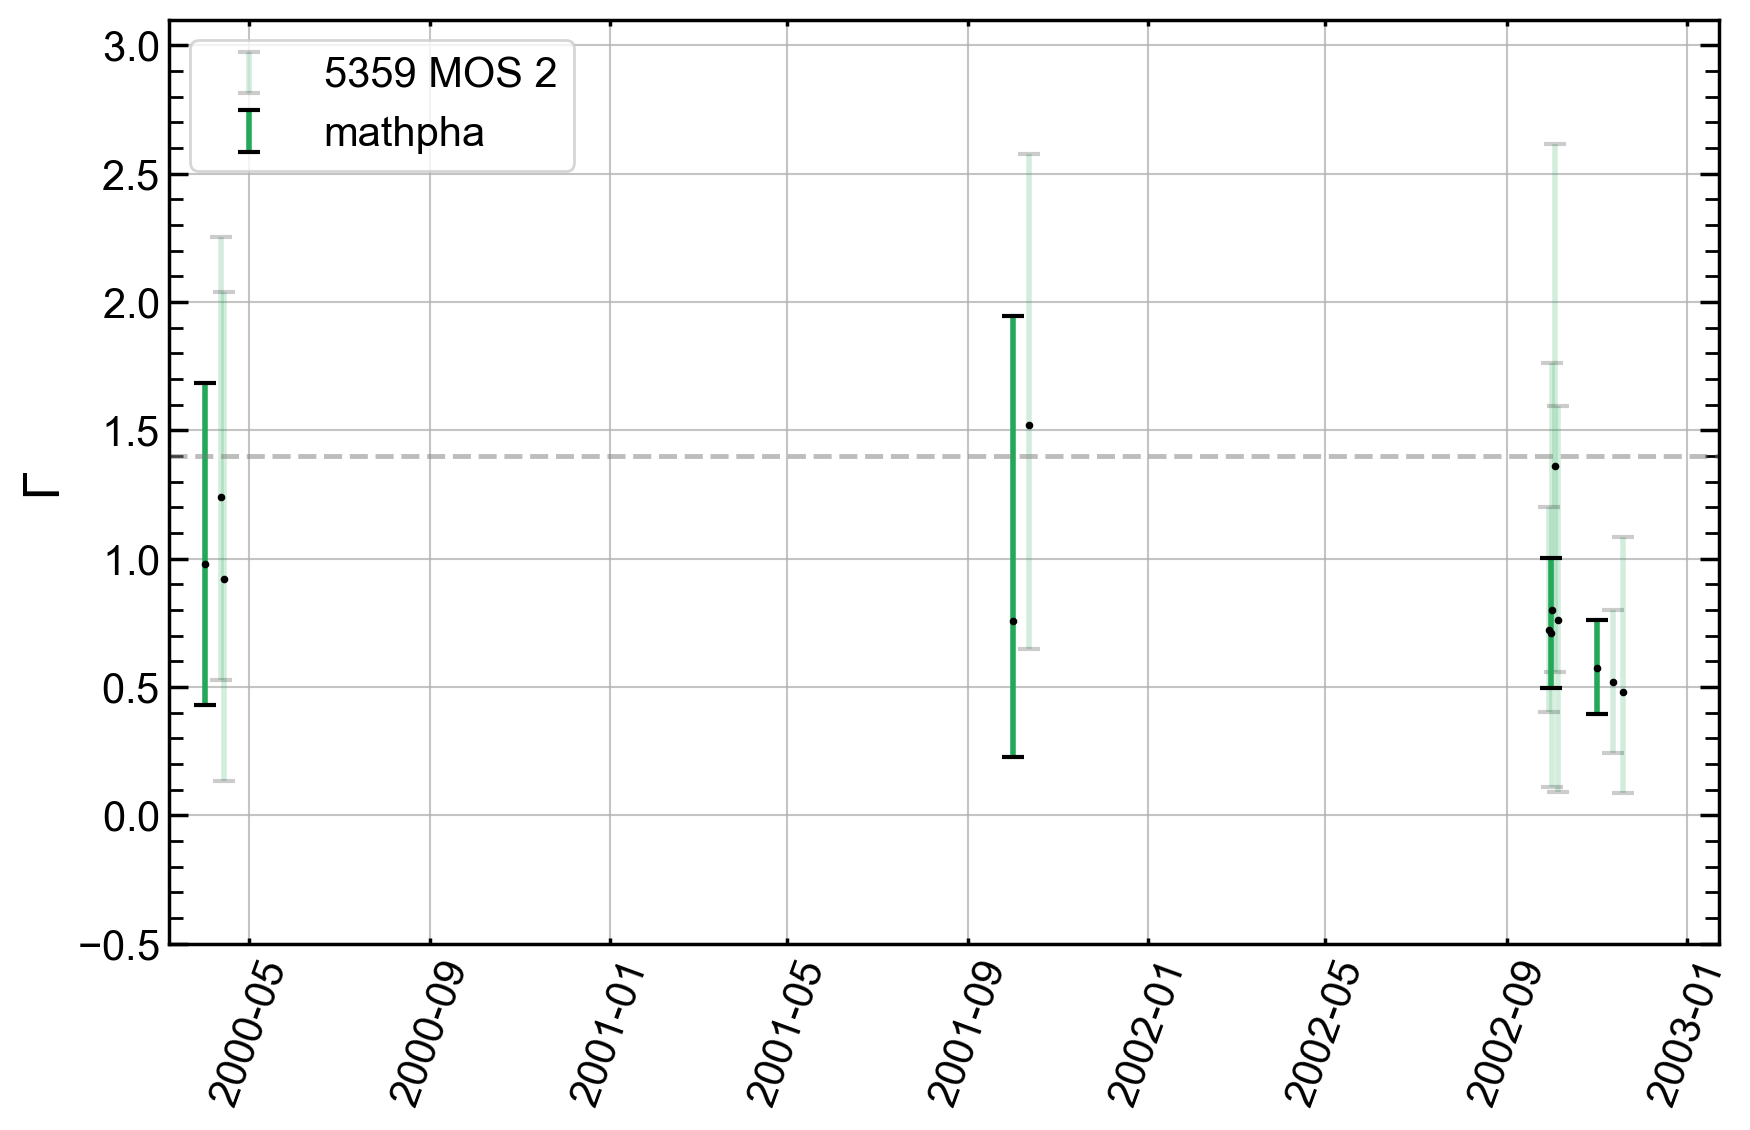

In [13]:
src_5359_M2_df = pd.read_csv('../data/source_201237001010017_5359_individual_M2_results.csv')
ax = old_plot_date_gamma(src_5359_M2_df, "5359 MOS 2", color='C2', alpha=0.2, pad=True)

src_5359_M2_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_5359_M2_addspec_df, "mathpha", color='C2', alpha=1, ax=ax)

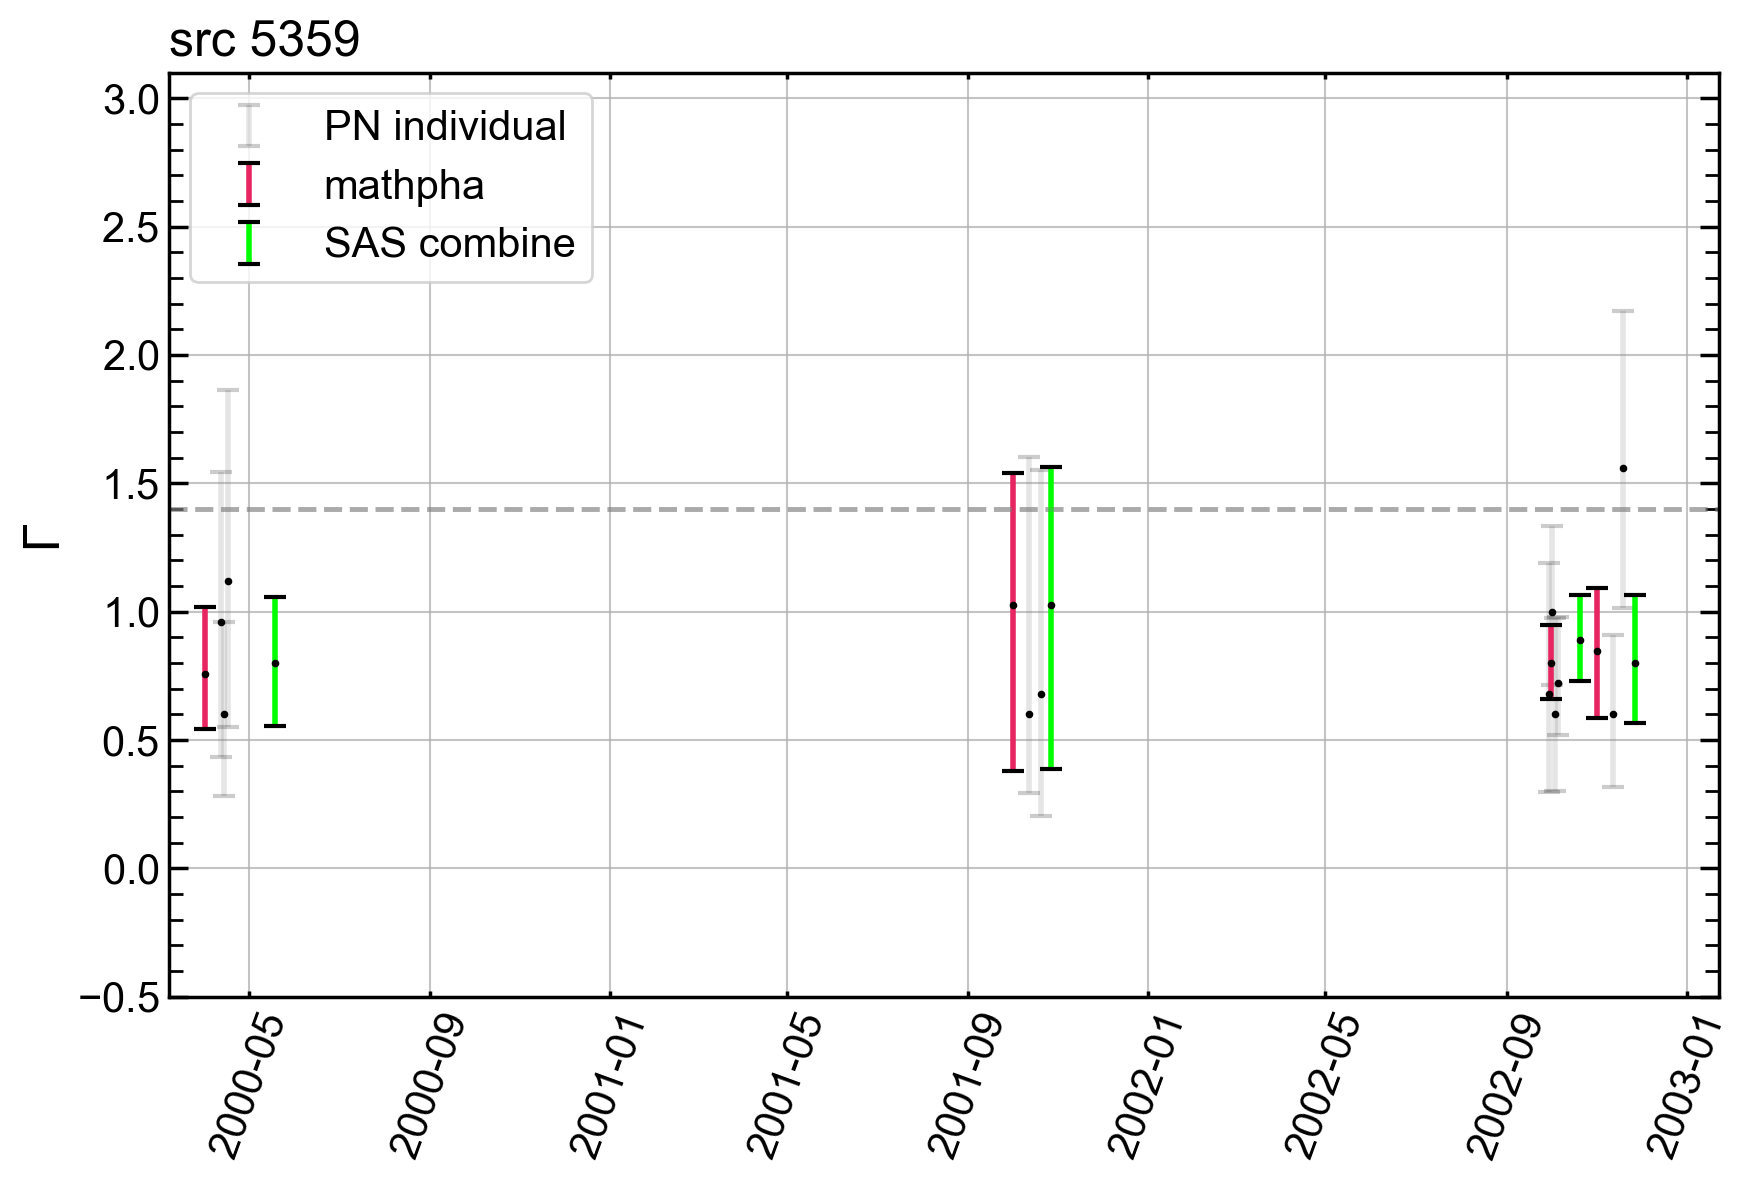

In [14]:
src_5359_PN_df = pd.read_csv('../data/source_201237001010017_5359_individual_PN_results.csv')
ax = old_plot_date_gamma(src_5359_PN_df, "PN individual", color='gray', alpha=0.2, pad=True)

src_5359_PN_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_5359_PN_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_5359_PN_sascombine_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_5359_PN_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 5359', loc='left')
plt.show()

In [15]:
src_5359_PN_df.sort_values('date_obs').reset_index(drop=True)

,filename,date_obs,obs_id,mo2_model,mo2_cstat,mo2_dof,mo2_cstat_r,flux,flux_nerr,flux_perr,...,mo2_PhoIndex_step_2d,mo2_PhoIndex_step_2d_lower,mo2_PhoIndex_step_2d_upper,mo2_PhoIndex_step_2d_perr,mo2_PhoIndex_step_2d_nerr,mo2_nH_step_2d,mo2_nH_step_2d_lower,mo2_nH_step_2d_upper,mo2_nH_step_2d_perr,mo2_nH_step_2d_nerr
0,P0123700101PNS003SRSPEC0011.FTZ,2000-04-27,123700101,ph*zph*zpo,13.308702,23,0.578639,7.207678e-15,5.064265e-15,7.764784e-15,...,0.96,0.434745,1.543945,0.583945,0.525255,2.089296,0.217246,4.613212,2.523916,1.872050e+00
1,P0123700201PNS003SRSPEC0012.FTZ,2000-04-29,123700201,ph*zph*zpo,80.240500,56,1.432866,8.845030e-15,6.852128e-15,9.607335e-15,...,0.60,0.280979,0.959000,0.359000,0.319021,1.380384,0.397561,3.001842,1.621458,9.828233e-01
2,P0123700401PNS003SRSPEC000E.FTZ,2000-05-02,123700401,ph*zph*zpo,5.557697,4,1.389424,1.057044e-14,5.236532e-15,1.116697e-14,...,1.12,0.550164,1.862996,0.742996,0.569836,1.995262,0.469280,5.557726,3.562464,1.525983e+00
3,P0022740201PNS003SRSPEC001C.FTZ,2001-10-27,22740201,ph*zph*zpo,21.534534,20,1.076727,6.331120e-15,4.814180e-15,6.864330e-15,...,0.60,0.292709,1.602374,1.002374,0.307291,0.263027,0.100000,5.708206,5.445179,1.630268e-01
4,P0022740301PNS003SRSPEC001C.FTZ,2001-11-04,22740301,ph*zph*zpo,2.413990,4,0.603497,5.649834e-15,3.236852e-15,6.152869e-15,...,0.68,0.201346,1.552087,0.872087,0.478654,0.575440,0.100000,4.974114,4.398674,4.754399e-01
5,P0147510101PNS003SRSPEC0013.FTZ,2002-10-15,147510101,ph*zph*zpo,22.328699,25,0.893148,4.089611e-15,3.298616e-15,4.413186e-15,...,0.68,0.297278,1.187596,0.507596,0.382722,0.954993,0.100000,3.585214,2.630221,8.549926e-01
6,P0147510801PNS003SRSPEC0009.FTZ,2002-10-17,147510801,ph*zph*zpo,29.521378,33,0.894587,6.208091e-15,4.987638e-15,6.521193e-15,...,1.00,0.714175,1.334873,0.334873,0.285825,0.912011,0.335011,1.888648,0.976637,5.769997e-01
7,P0147510901PNS003SRSPEC0024.FTZ,2002-10-19,147510901,ph*zph*zpo,28.749067,27,1.064780,5.455343e-15,3.611554e-15,5.682500e-15,...,0.60,0.300348,0.973068,0.373068,0.299652,0.100000,0.100000,1.026339,0.926339,1.387779e-17
8,P0147511001PNS003SRSPEC0011.FTZ,2002-10-21,147511001,ph*zph*zpo,23.476224,18,1.304235,5.097015e-15,4.470379e-15,5.432900e-15,...,0.72,0.517683,0.980342,0.260342,0.202317,0.165959,0.100000,0.855609,0.689650,6.595869e-02
9,P0147511601PNS003SRSPEC0022.FTZ,2002-11-27,147511601,ph*zph*zpo,48.208984,34,1.417911,5.068747e-15,4.171174e-15,5.442919e-15,...,0.60,0.314490,0.910136,0.310136,0.285510,0.724436,0.100000,1.763878,1.039442,6.244360e-01


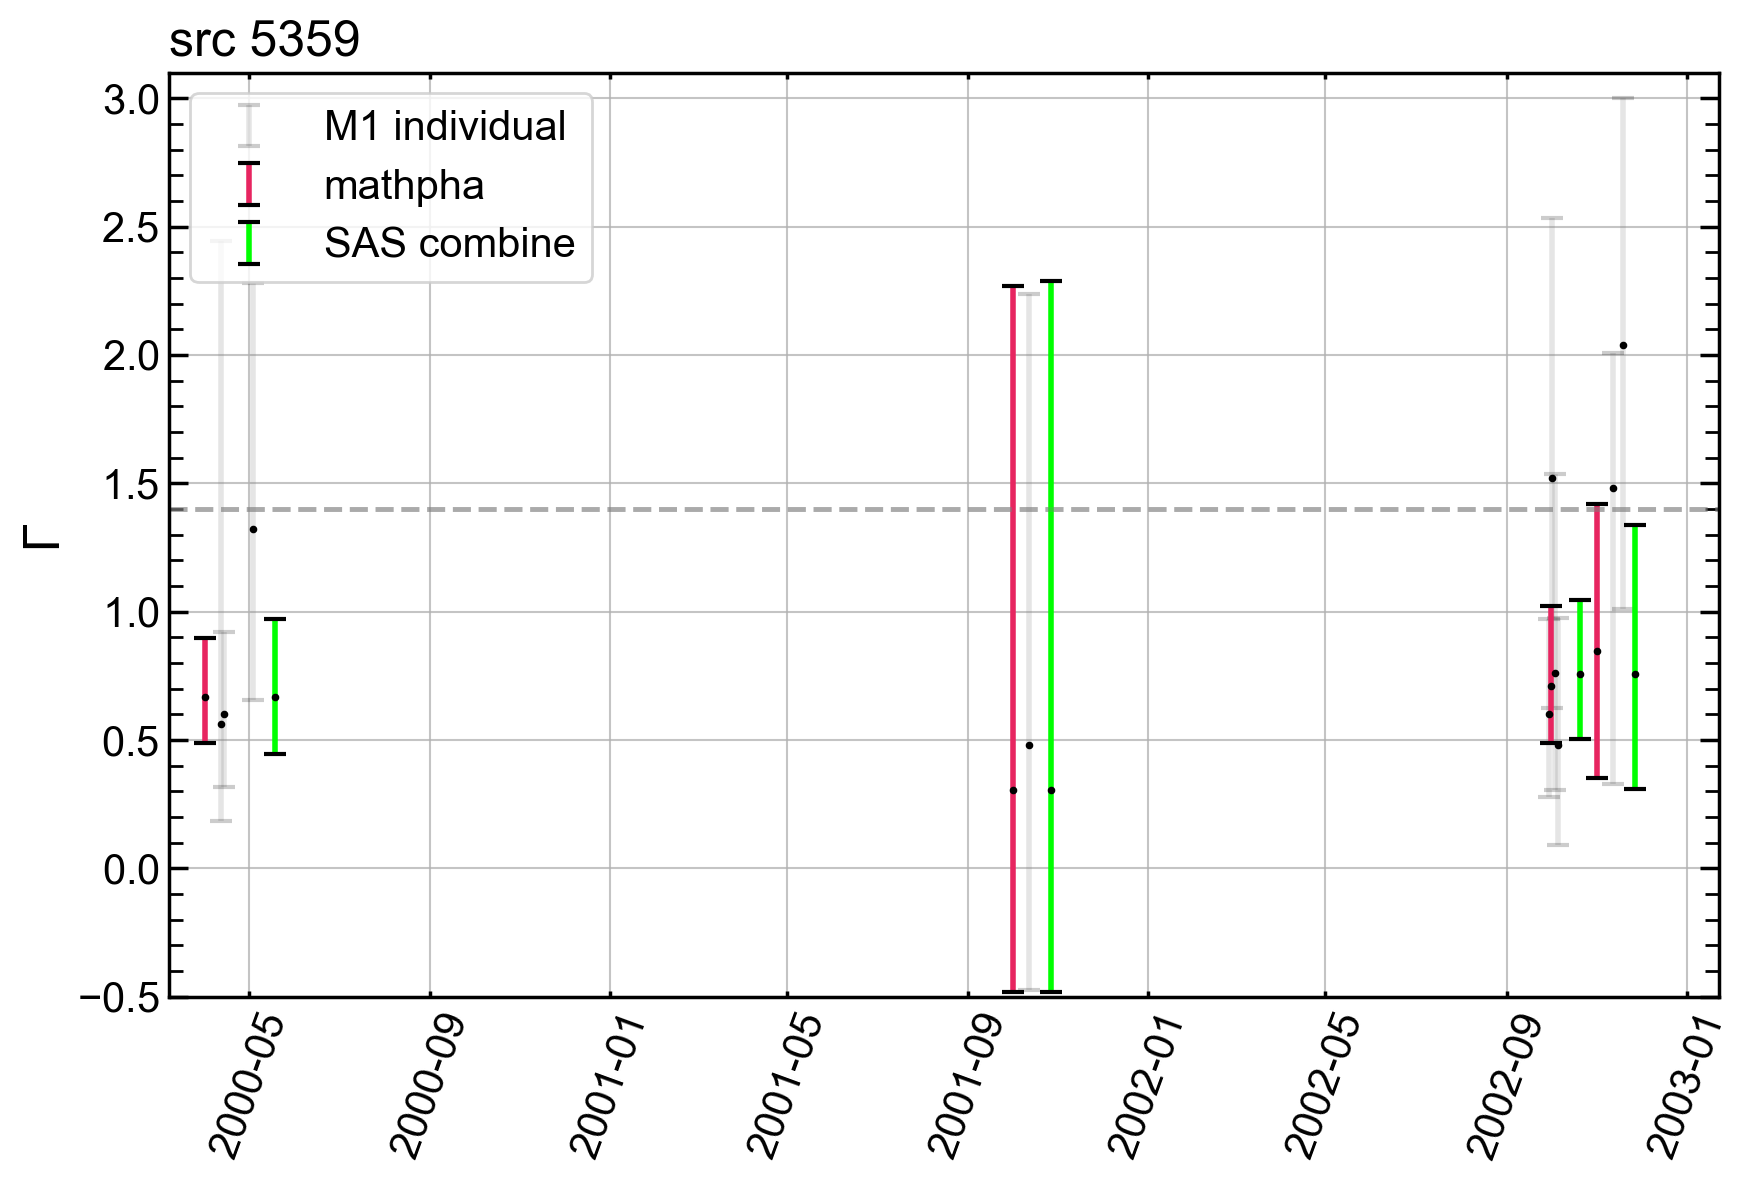

In [16]:
src_5359_M1_df = pd.read_csv('../data/source_201237001010017_5359_individual_M1_results.csv')
ax = old_plot_date_gamma(src_5359_M1_df, "M1 individual", color='gray', alpha=0.2, pad=True)

src_5359_M1_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_5359_M1_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_5359_M1_sascombine_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_5359_M1_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 5359', loc='left')
plt.show()

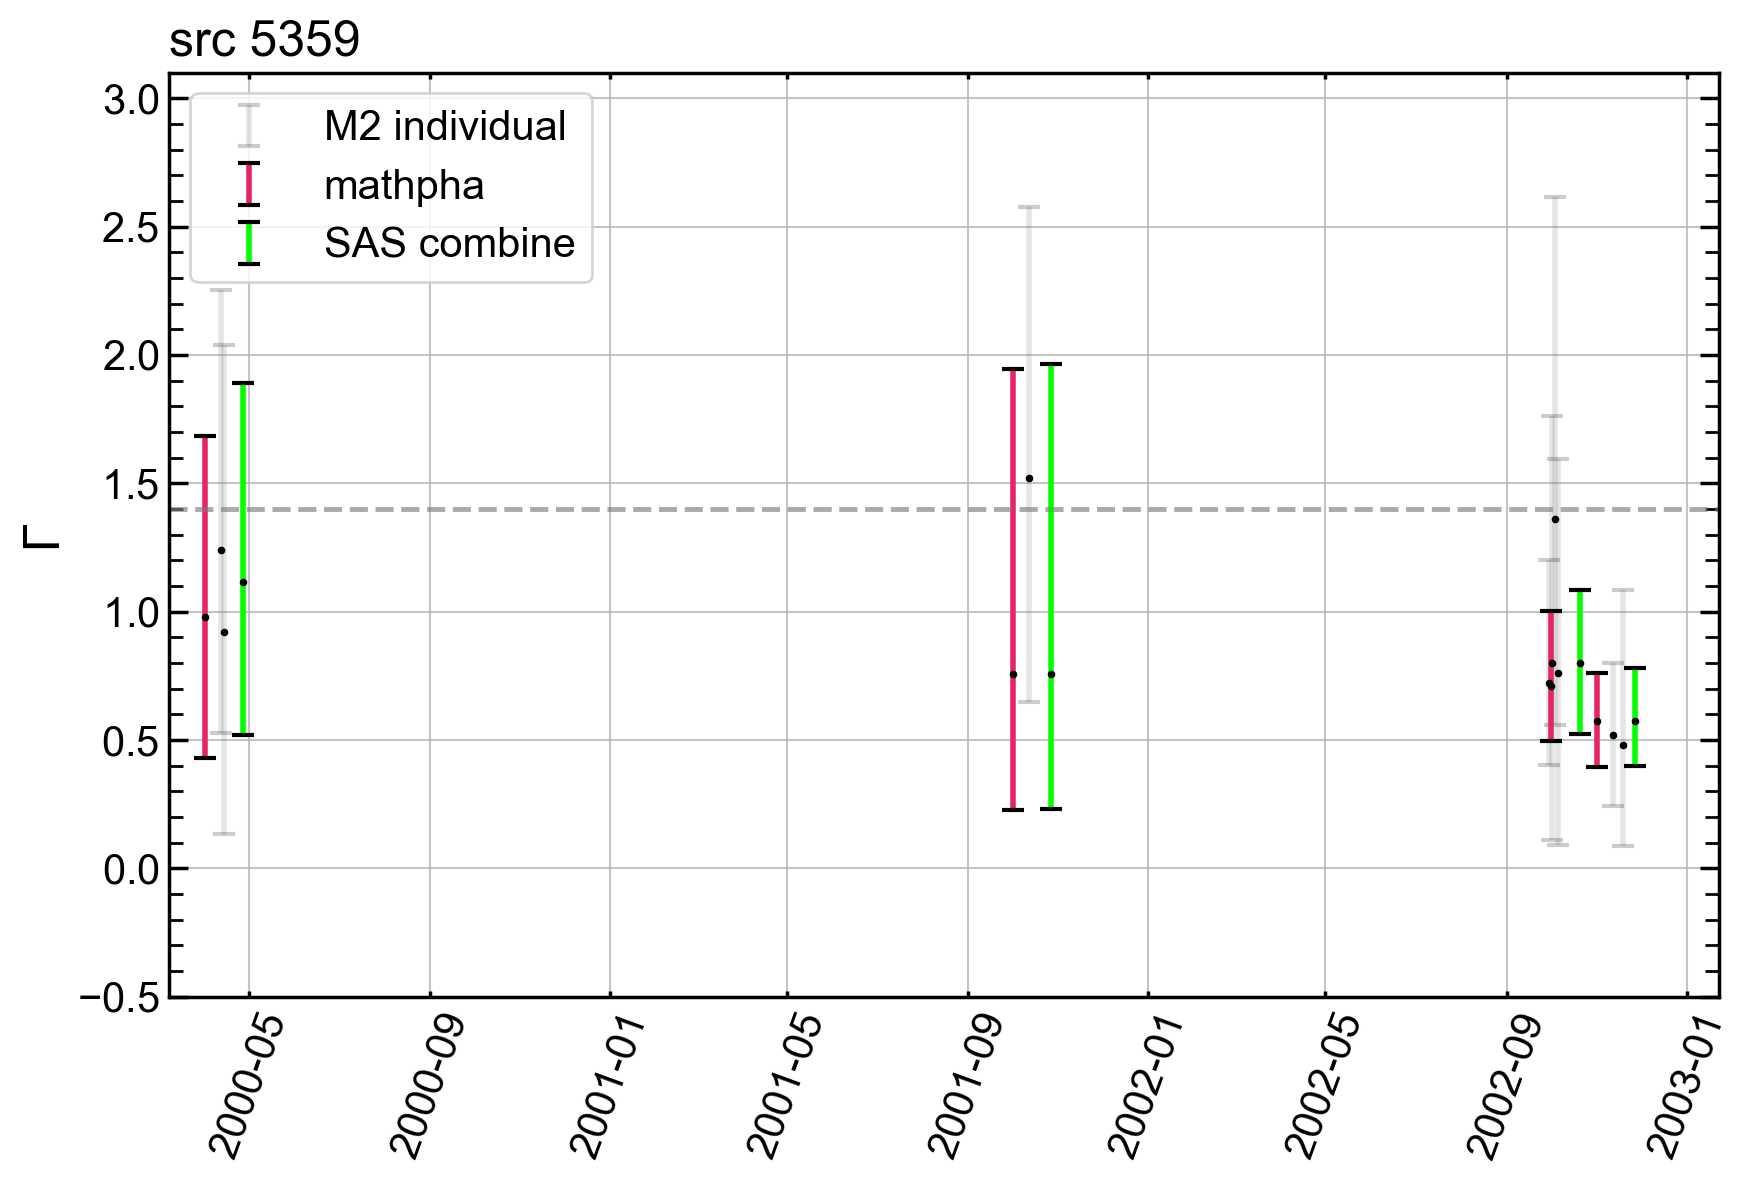

In [17]:
src_5359_M2_df = pd.read_csv('../data/source_201237001010017_5359_individual_M2_results.csv')
ax = old_plot_date_gamma(src_5359_M2_df, "M2 individual", color='gray', alpha=0.2, pad=True)

src_5359_M2_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_5359_M2_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_5359_M2_sascombine_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_5359_M2_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 5359', loc='left')
plt.show()

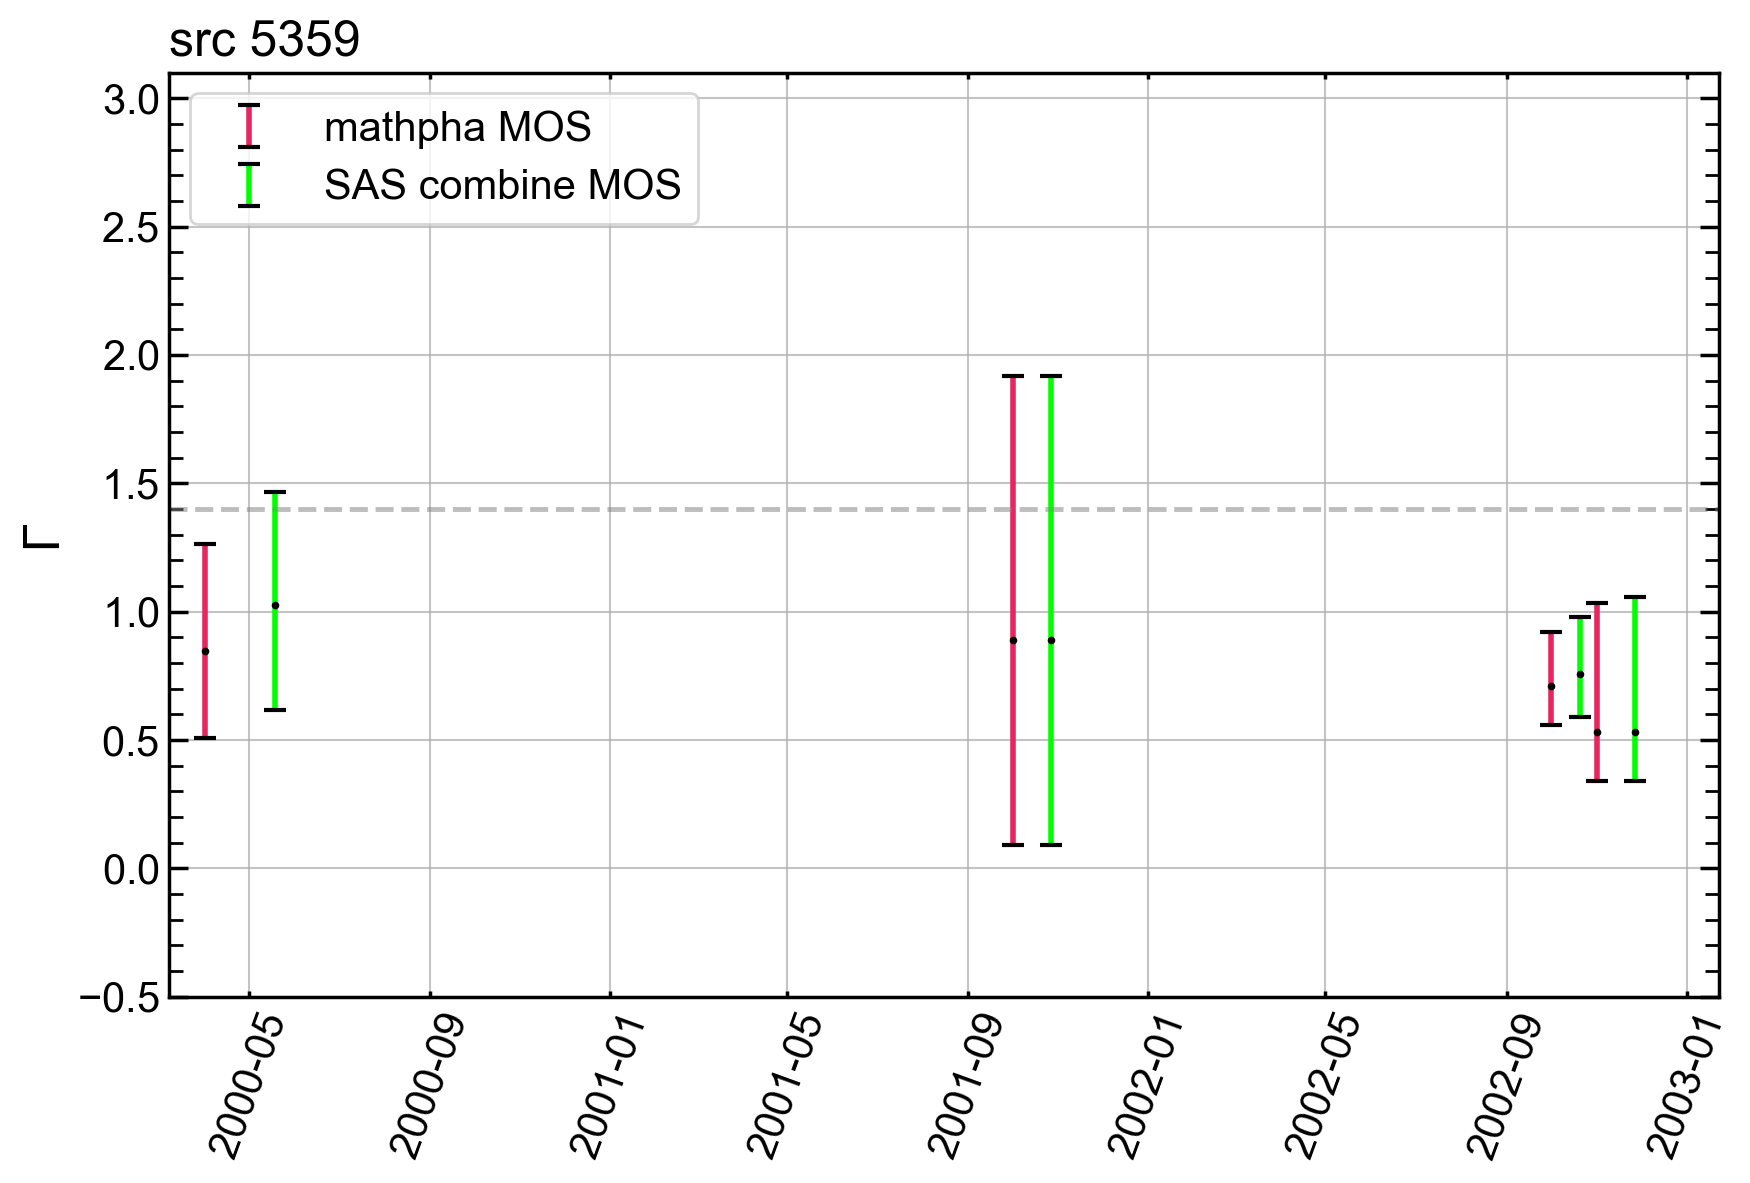

In [18]:
src_5359_MOS_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_MOS_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_5359_MOS_addspec_df, "mathpha MOS", color='C1', alpha=1)

src_5359_MOS_sascombine_df = pd.read_csv('../data/source_201237001010017_5359_clustered_MOS_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_5359_MOS_sascombine_df, "SAS combine MOS", color='lime', alpha=1, ax=ax)

ax.set_title('src 5359', loc='left')
plt.show()

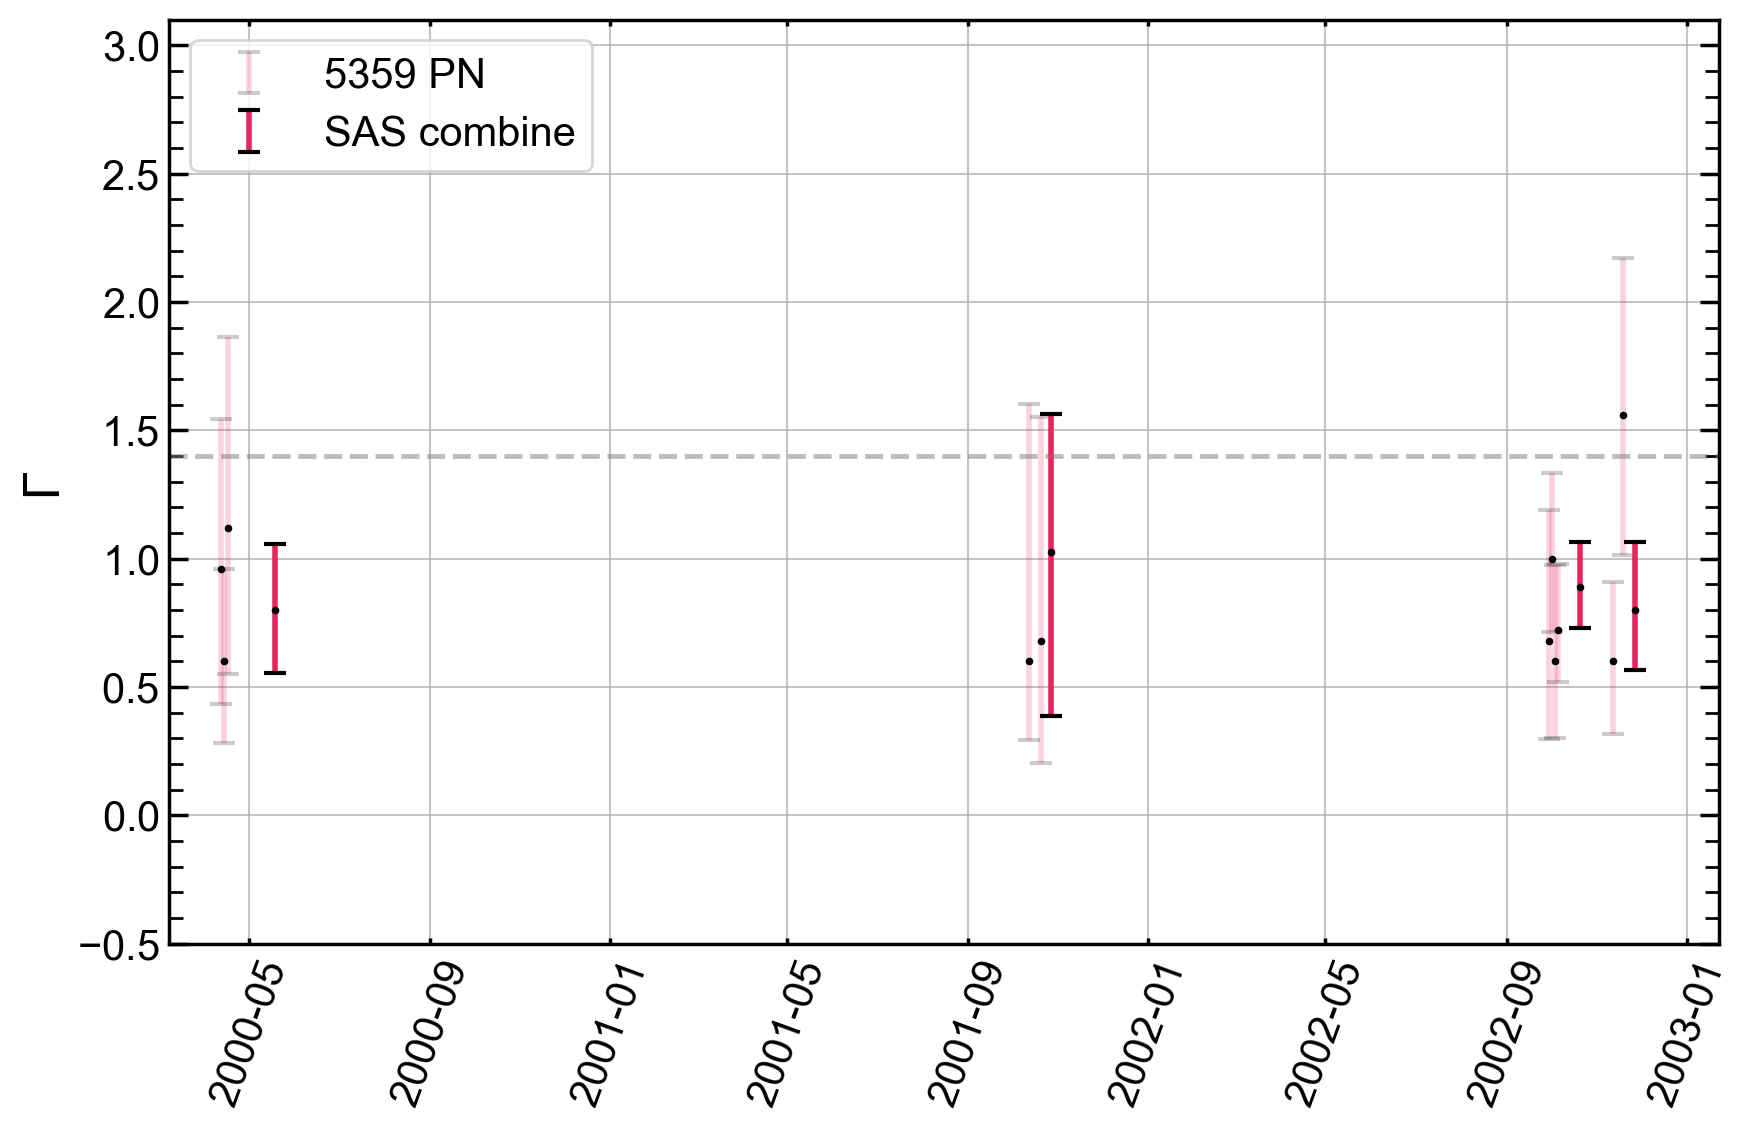

In [19]:
src_5359_PN_df = pd.read_csv('../data/source_201237001010017_5359_individual_PN_results.csv')
ax = old_plot_date_gamma(src_5359_PN_df, "5359 PN", color='C1', alpha=0.2, pad=True)

src_5359_PN_addspec_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_5359_PN_addspec_df, "SAS combine", color='C1', alpha=1, ax=ax)

<Axes: ylabel='Г'>

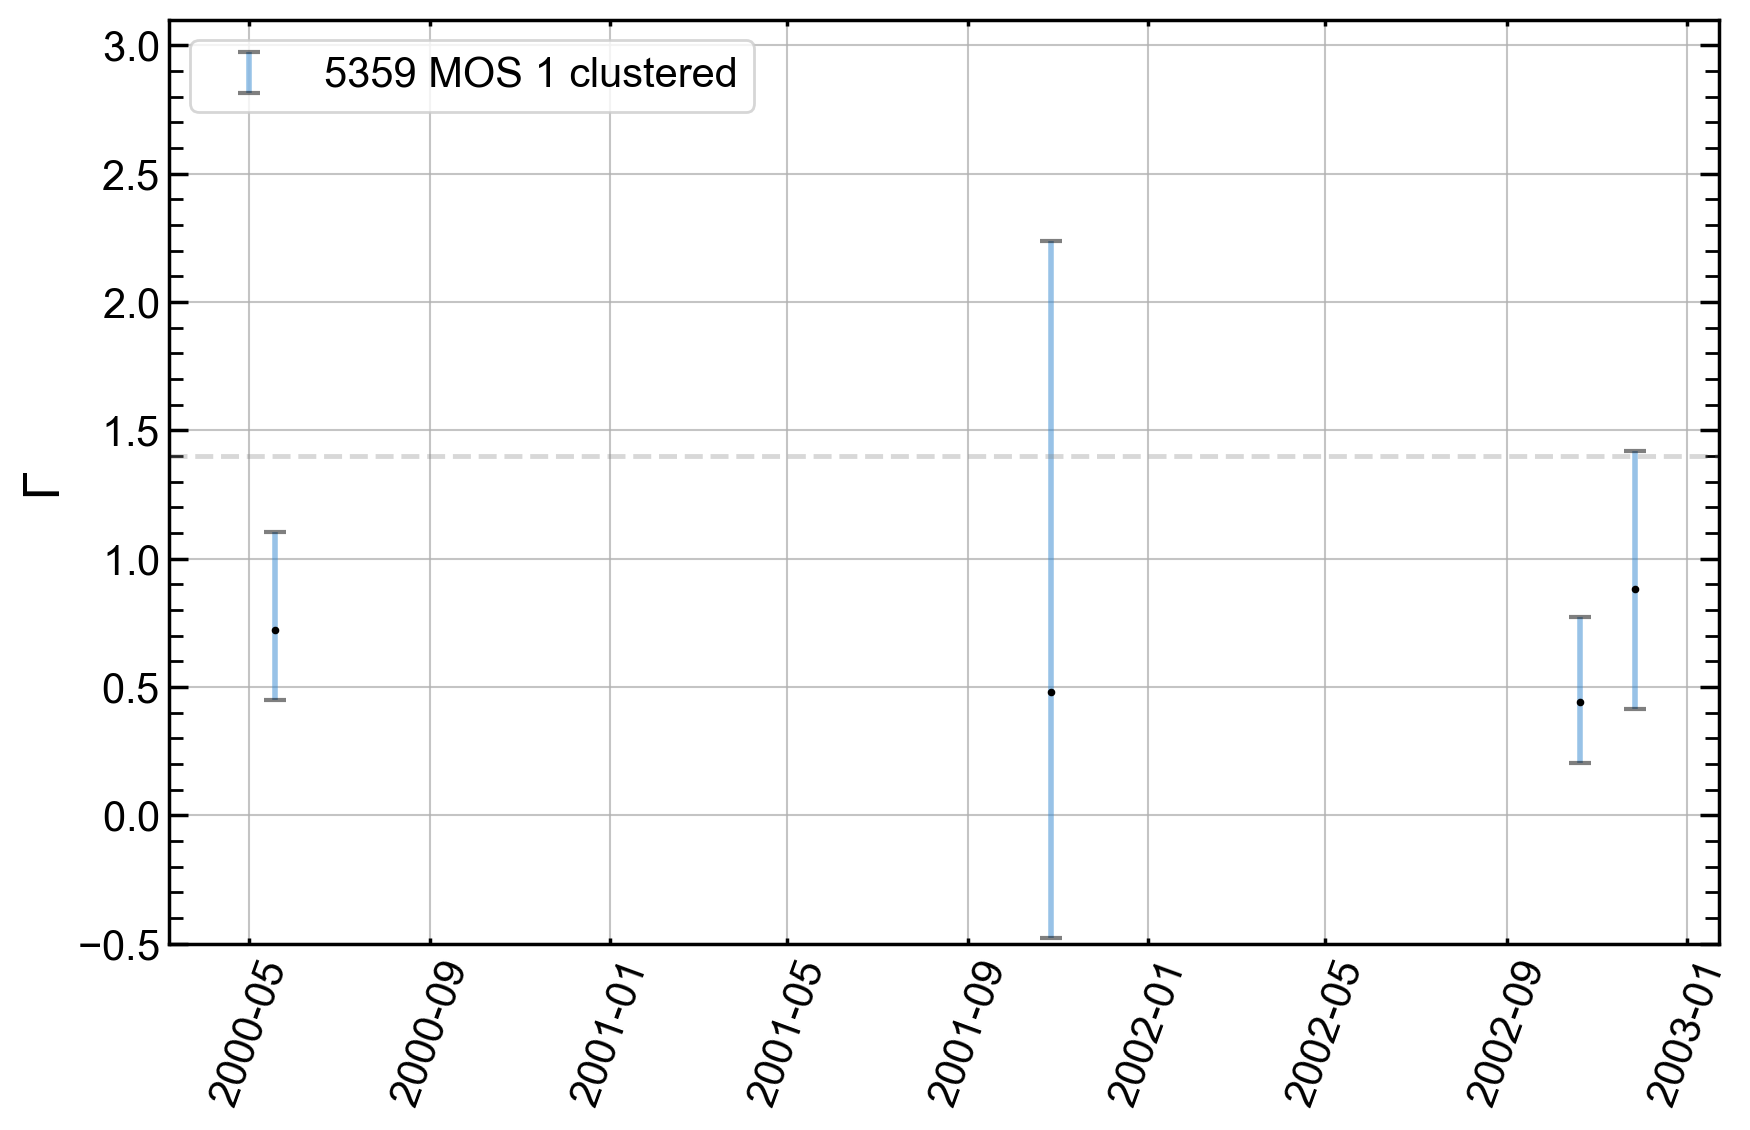

In [20]:
src_5359_M1_cluster_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M1_gap30_results.csv')

old_plot_date_gamma(src_5359_M1_cluster_df, "5359 MOS 1 clustered", color='C0')

<Axes: ylabel='Г'>

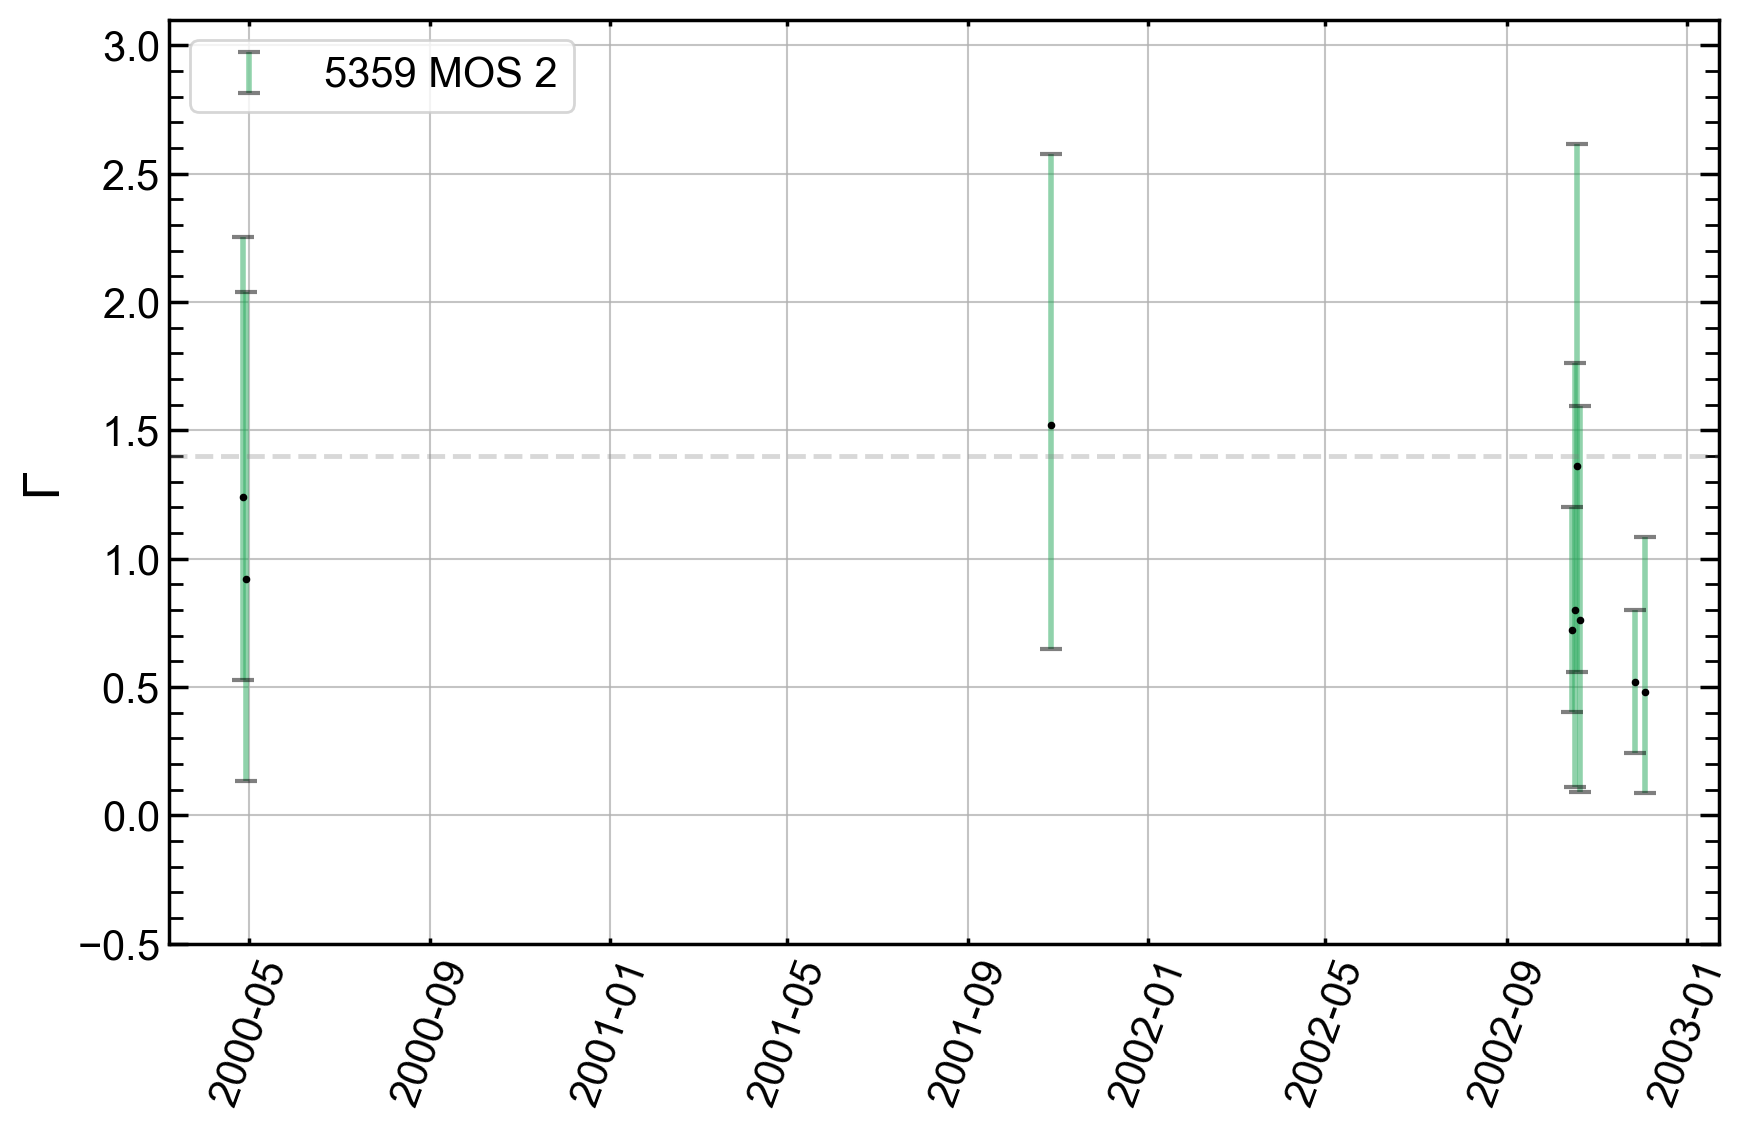

In [21]:
src_5359_M2_df = pd.read_csv('../data/source_201237001010017_5359_individual_M2_results.csv')

old_plot_date_gamma(src_5359_M2_df, "5359 MOS 2", color='C2')

<Axes: ylabel='Г'>

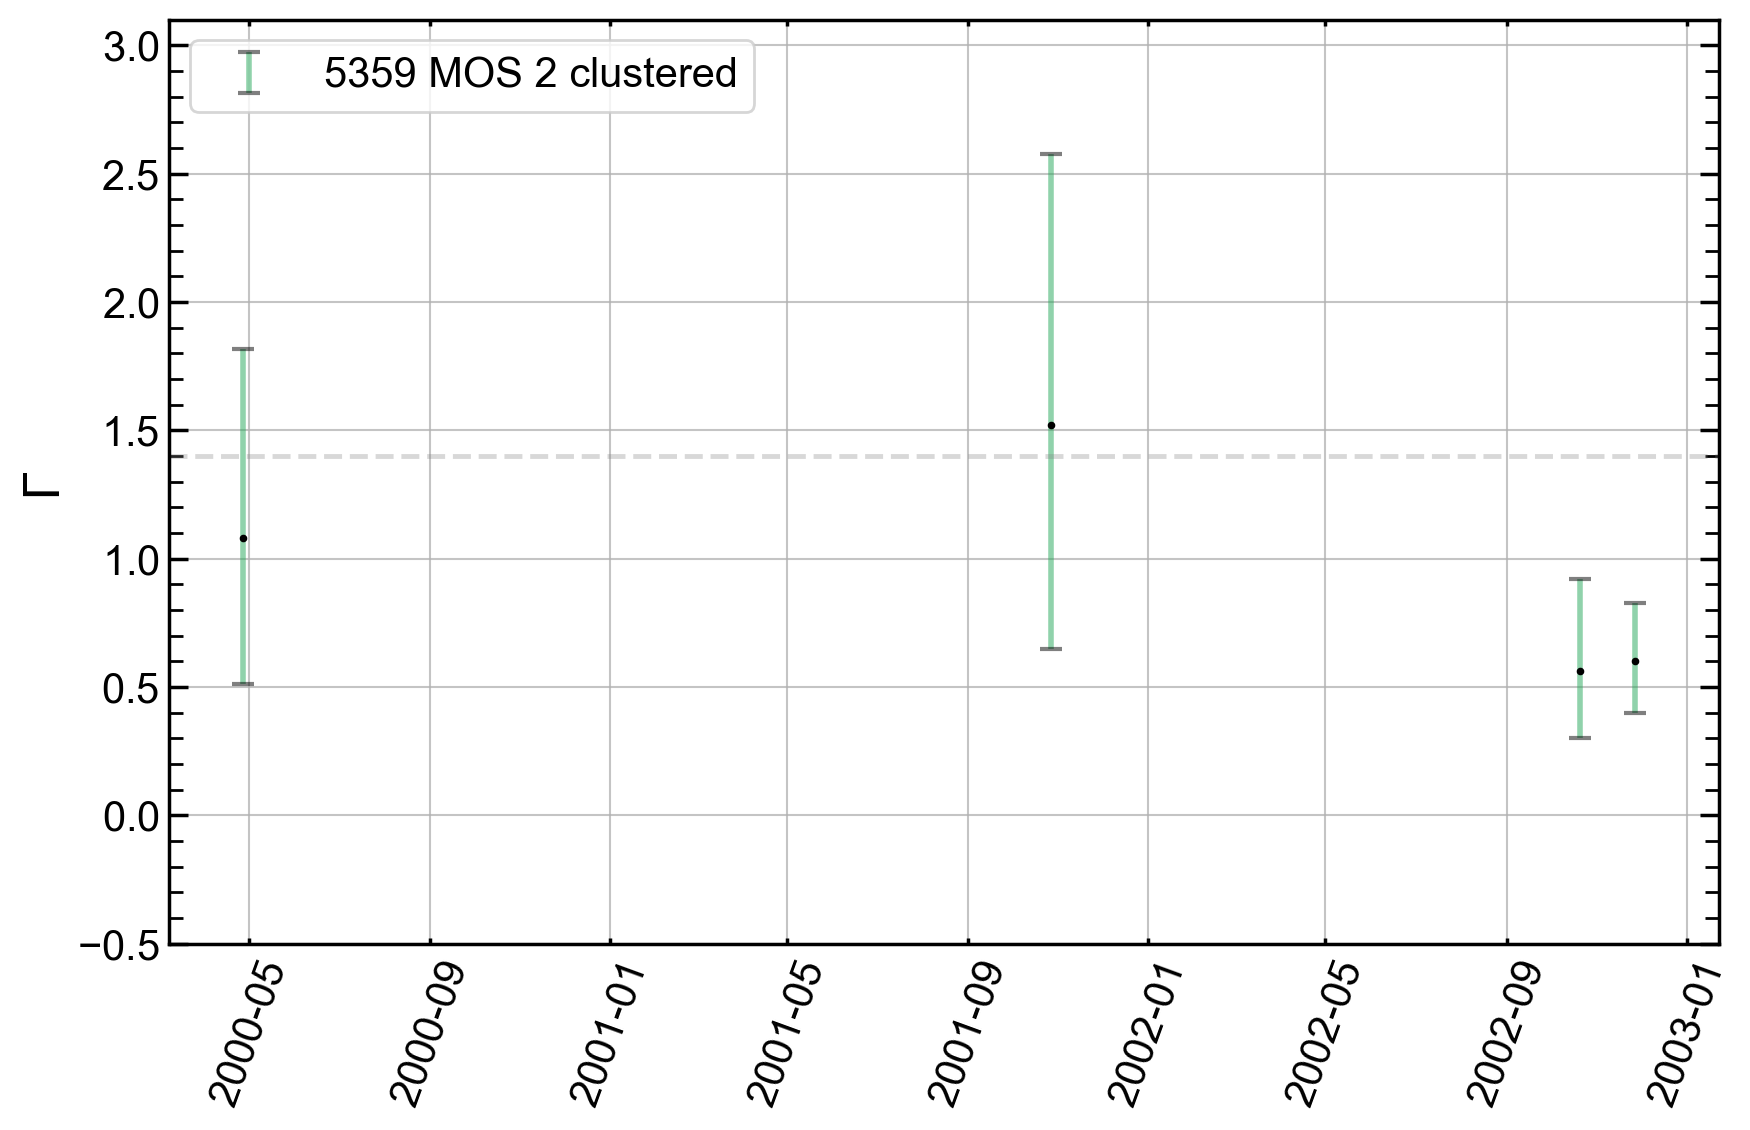

In [22]:
src_5359_M2_cluster_df = pd.read_csv('../data/source_201237001010017_5359_clustered_M2_gap30_results.csv')

old_plot_date_gamma(src_5359_M2_cluster_df, "5359 MOS 2 clustered", color='C2')

<Axes: ylabel='Г'>

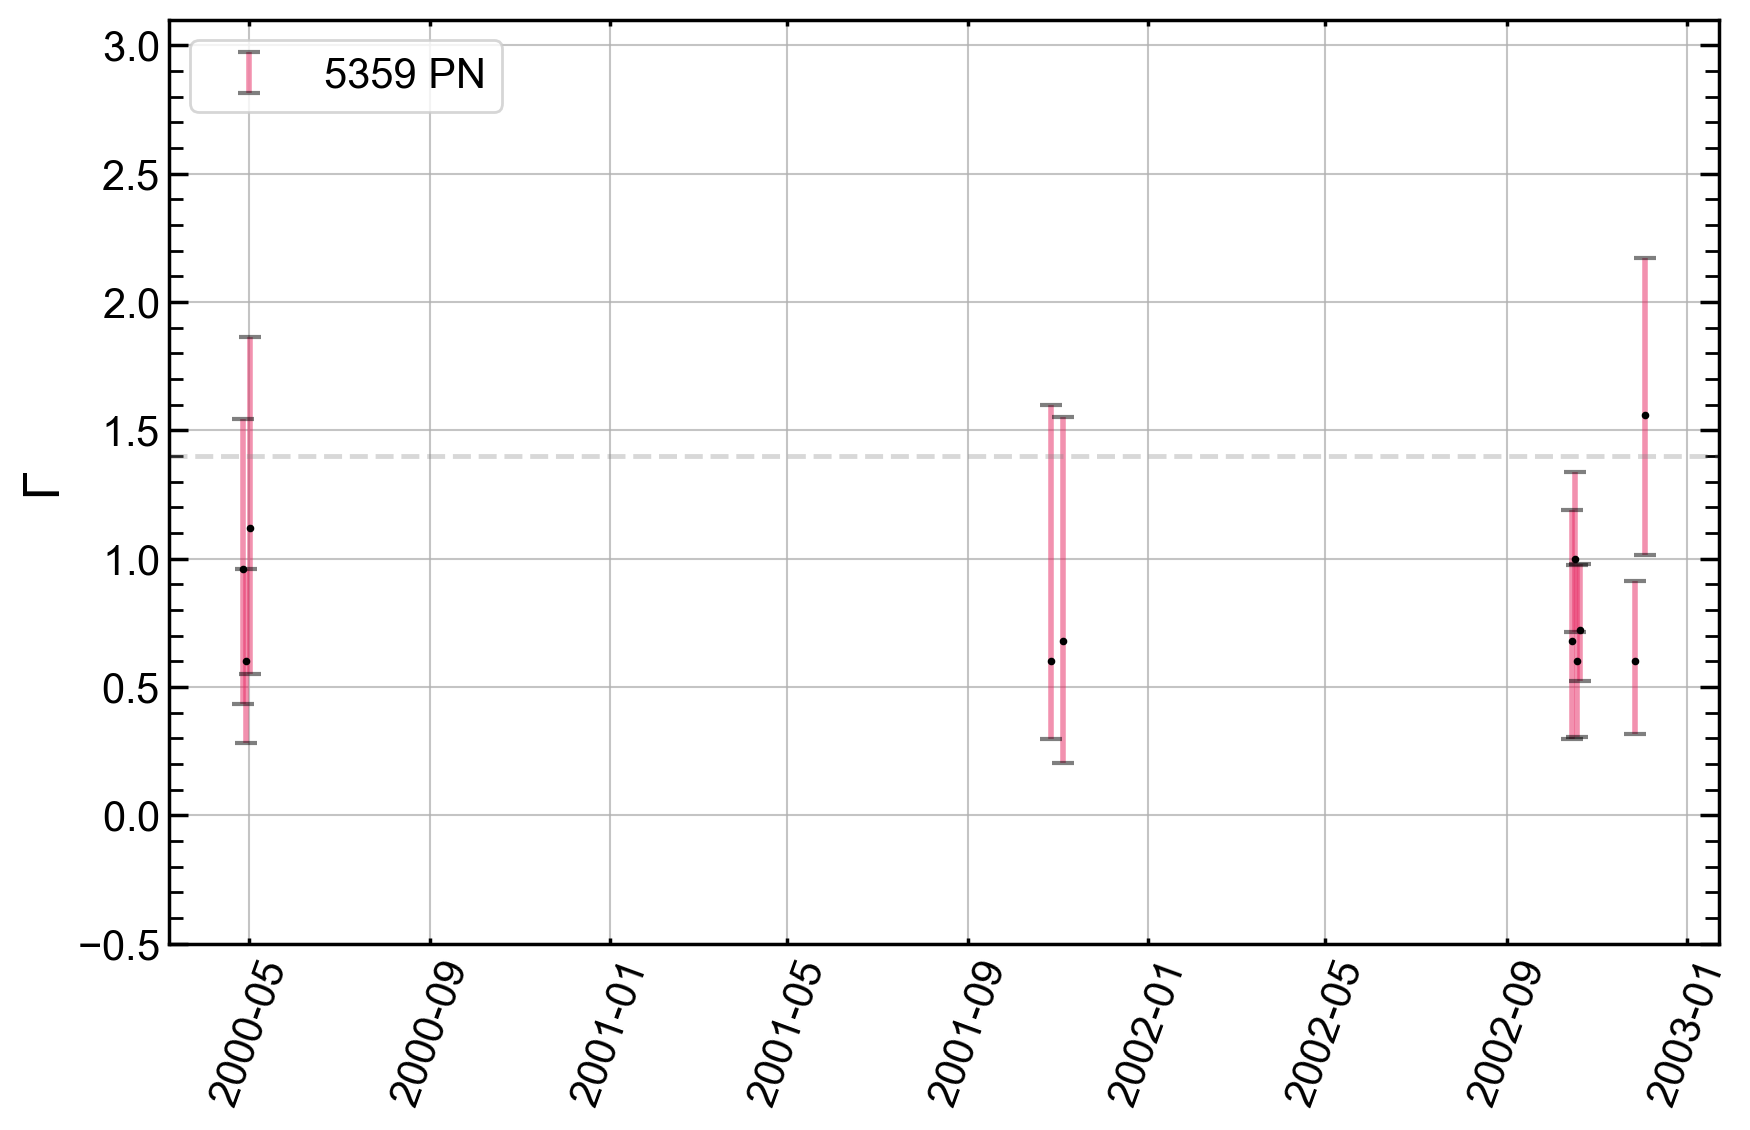

In [23]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_results.csv')

old_plot_date_gamma(src_5359_df, "5359 PN", color='C1')

<Axes: ylabel='Г'>

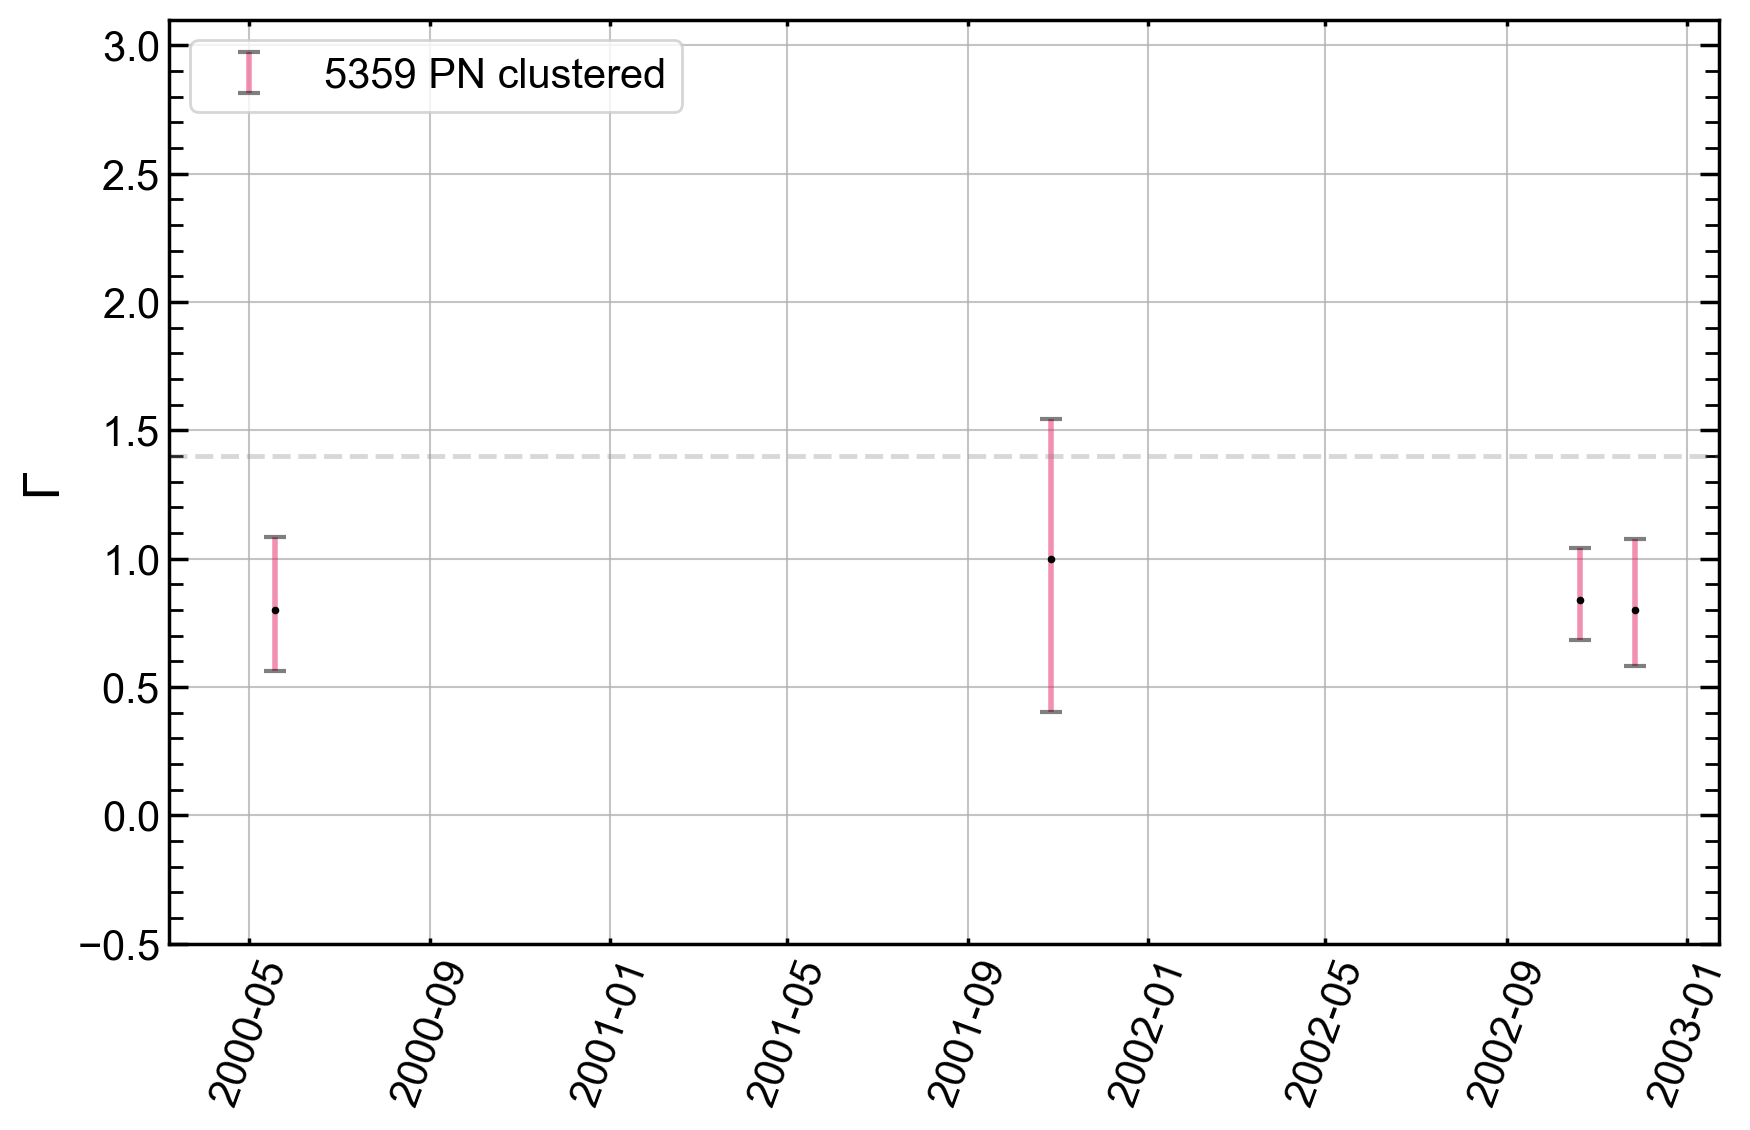

In [24]:
src_5359_df = pd.read_csv('../data/source_201237001010017_5359_clustered_PN_gap30_results.csv')

old_plot_date_gamma(src_5359_df, "5359 PN clustered", color='C1')

In [25]:
src_5359_df

,filename,date_obs,obs_id,mo2_model,mo2_cstat,mo2_dof,mo2_cstat_r,flux,flux_nerr,flux_perr,...,mo2_PhoIndex_step_2d,mo2_PhoIndex_step_2d_lower,mo2_PhoIndex_step_2d_upper,mo2_PhoIndex_step_2d_perr,mo2_PhoIndex_step_2d_nerr,mo2_nH_step_2d,mo2_nH_step_2d_lower,mo2_nH_step_2d_upper,mo2_nH_step_2d_perr,mo2_nH_step_2d_nerr
0,combined_spectrum_PN_2000_04_gap30.ds,2000-05-19,123701001,ph*zph*zpo,33.797883,22,1.536267,7.488282e-15,6.526805e-15,7.906162e-15,...,0.80,0.562857,1.085381,0.285381,0.237143,1.737801,0.791100,3.197354,1.459553,0.946701
1,combined_spectrum_PN_2001_10_gap30.ds,2001-10-27,22740201,ph*zph*zpo,26.033932,20,1.301697,5.772907e-15,4.460899e-15,6.196556e-15,...,1.00,0.403577,1.543579,0.543579,0.596423,2.089296,0.100000,5.156189,3.066893,1.989296
2,combined_spectrum_PN_2002_10_gap30.ds,2002-10-21,147511001,ph*zph*zpo,24.622044,18,1.367891,4.647884e-15,4.351102e-15,4.855791e-15,...,0.84,0.682009,1.040126,0.200126,0.157991,0.870964,0.464433,1.550924,0.679960,0.406531
3,combined_spectrum_PN_2002_11_gap30.ds,2002-11-27,147511601,ph*zph*zpo,50.399759,34,1.482346,4.863993e-15,4.353379e-15,5.132839e-15,...,0.80,0.581891,1.076200,0.276200,0.218109,1.047129,0.432955,2.048722,1.001593,0.614173


In [26]:
src_5359_M1_cluster_df

,filename,date_obs,obs_id,mo2_model,mo2_cstat,mo2_dof,mo2_cstat_r,flux,flux_nerr,flux_perr,...,mo2_PhoIndex_step_2d,mo2_PhoIndex_step_2d_lower,mo2_PhoIndex_step_2d_upper,mo2_PhoIndex_step_2d_perr,mo2_PhoIndex_step_2d_nerr,mo2_nH_step_2d,mo2_nH_step_2d_lower,mo2_nH_step_2d_upper,mo2_nH_step_2d_perr,mo2_nH_step_2d_nerr
0,combined_spectrum_M1_2000_04_gap30.ds,2000-05-19,123701001,ph*zph*zpo,14.598640,5,2.919728,1.155800e-14,9.285976e-15,1.224720e-14,...,0.72,0.449274,1.103690,0.383690,0.270726,0.263027,0.100000,1.717669,1.454642,0.163027
1,combined_spectrum_M1_2001_10_gap30.ds,2001-10-27,22740201,ph*zph*zpo,0.973718,1,0.973718,3.331454e-15,0.000000e+00,3.454661e-15,...,0.48,-0.477576,2.238051,1.758051,0.957576,0.549541,0.100000,10.000000,9.450459,0.449541
2,combined_spectrum_M1_2002_10_gap30.ds,2002-10-21,147511001,ph*zph*zpo,12.716043,3,4.238681,5.395760e-15,4.587027e-15,5.618522e-15,...,0.44,0.201490,0.771715,0.331715,0.238510,0.263027,0.100000,1.134256,0.871229,0.163027
3,combined_spectrum_M1_2002_11_gap30.ds,2002-11-27,147511601,ph*zph*zpo,18.710168,13,1.439244,5.221843e-15,3.863897e-15,5.636888e-15,...,0.88,0.412813,1.418531,0.538531,0.467187,2.398833,0.395225,5.464883,3.066050,2.003608


In [27]:
src_5359_M2_cluster_df

,filename,date_obs,obs_id,mo2_model,mo2_cstat,mo2_dof,mo2_cstat_r,flux,flux_nerr,flux_perr,...,mo2_PhoIndex_step_2d,mo2_PhoIndex_step_2d_lower,mo2_PhoIndex_step_2d_upper,mo2_PhoIndex_step_2d_perr,mo2_PhoIndex_step_2d_nerr,mo2_nH_step_2d,mo2_nH_step_2d_lower,mo2_nH_step_2d_upper,mo2_nH_step_2d_perr,mo2_nH_step_2d_nerr
0,combined_spectrum_M2_2000_04_gap30.ds,2000-04-27,123700101,ph*zph*zpo,14.501526,16,0.906345,8.626116e-15,4.227867e-15,8.914424e-15,...,1.08,0.509881,1.815221,0.735221,0.570119,2.511886,0.405442,6.986829,4.474943,2.106444
1,combined_spectrum_M2_2001_10_gap30.ds,2001-10-27,22740201,ph*zph*zpo,5.681712,3,1.893904,7.479381e-15,0.000000e+00,7.541658e-15,...,1.52,0.648468,2.576884,1.056884,0.871532,3.630781,0.510447,9.390503,5.759723,3.120333
2,combined_spectrum_M2_2002_10_gap30.ds,2002-10-21,147511001,ph*zph*zpo,31.220018,3,10.406673,5.196534e-15,4.469937e-15,5.423485e-15,...,0.56,0.301299,0.921530,0.361530,0.258701,0.363078,0.100000,1.292162,0.929084,0.263078
3,combined_spectrum_M2_2002_11_gap30.ds,2002-11-27,147511601,ph*zph*zpo,19.127926,13,1.471379,5.831895e-15,4.433720e-15,5.960041e-15,...,0.60,0.397237,0.826858,0.226858,0.202763,0.100000,0.100000,0.763479,0.663479,0.000000


In [28]:
src_5359_M2_cluster_df.at[0, 'date_obs'] = pd.to_datetime('2000-05-19 00:00:00')

In [32]:
def plot_date_gamma(
        df, title, color, ax=None, pad_days=None, lolim=-0.5, uplim=3.1, alpha=.5,
        marker='o'
    ):

    if not ax:
        _, ax = plt.subplots(figsize=(4, 4))

    df['date_obs'] = pd.to_datetime(df['date_obs']).dt.floor('D')

    # Add date formatter
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    padding = pd.Timedelta(days=50)  # Add 30 days padding on each side

    x_delta = pd.Timedelta(days=pad_days) if pad_days is not None else pd.Timedelta(days=0)

    _, caps, _ = ax.errorbar(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        yerr=[df['mo2_PhoIndex_step_2d_nerr'], df['mo2_PhoIndex_step_2d_perr']],
        fmt='o', markersize=0, alpha=alpha, capsize=4, capthick=1.5,
        ecolor=color, lw=2
        )
    
    for cap in caps:
        cap.set_markeredgecolor(color)   # the property that actually controls the visible cap
        cap.set_markerfacecolor(color)

    ax.scatter(
        x=df['date_obs'] + x_delta, y=df['mo2_PhoIndex_step_2d'],
        s=15, zorder=5, color=color, marker=marker, label=title
        )

    ax.set_ylim(lolim, uplim)
    ax.set_xlim(
        pd.to_datetime('2000-04-27 03:34:45') - padding,
        pd.to_datetime('2002-12-04 04:47:08') + padding
    )
    ax.axhline(1.3, color='gray', ls='--', alpha=0.3)

    ax.set_xlabel('Observation date', fontsize=14)
    ax.set_ylabel(r'Photon index $\Gamma$', fontsize=14)

    ax.tick_params(axis='x', which='minor', length=0)
    ax.tick_params(axis='x', which='major', length=2)

    # ax.set_title(f'srcid {title}; ph*zph*zpo', loc='left')

    ax.legend(loc='upper left', fontsize=12)

    # axis='x' → horizontal lines at y ticks; turn off y-axis grid from rcParams
    ax.grid(True, axis='y', alpha=0.25)
    ax.grid(False, axis='x')

    plt.xticks(rotation=0, fontsize=12)

    # plt.show()

    return ax

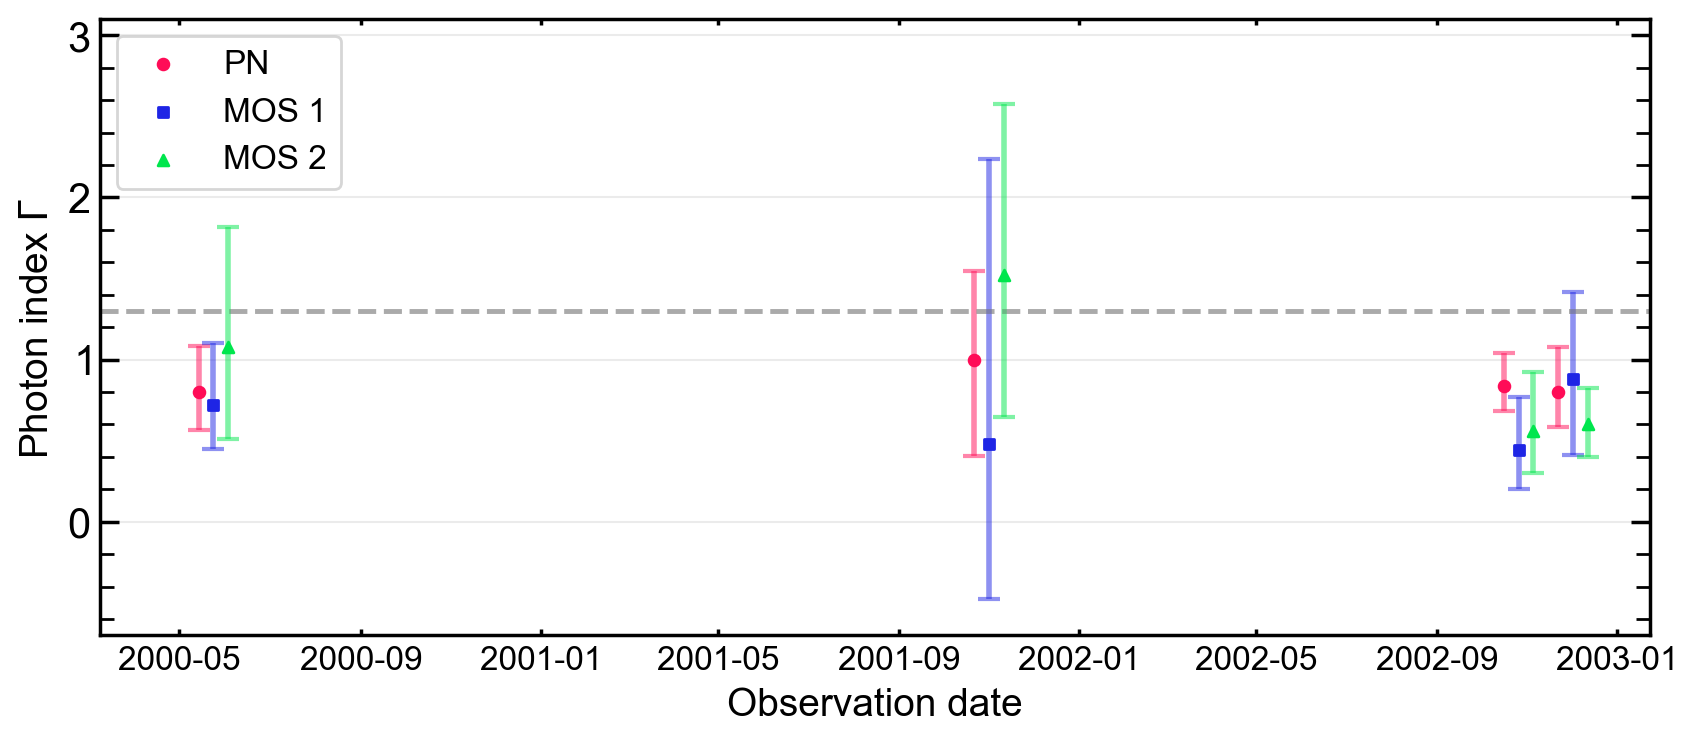

In [ ]:
colors = ['#1E25E5', '#FF0C57', '#00E64D']
markers = ['o', 's', '^']

ax = plot_date_gamma(
    src_5359_df, "PN", color='#FF0C57', pad_days=-5, marker='o'
    )
plot_date_gamma(
    src_5359_M1_cluster_df, "MOS 1", color='#1E25E5', ax=ax,
    pad_days=5, marker='s'
    )
plot_date_gamma(
    src_5359_M2_cluster_df, "MOS 2", color='#00E64D', ax=ax,
    marker='^', pad_days=15, lolim=-0.7
    )

# ax.figure.savefig(
#     '../data/plots/gamma_time_series.pdf', bbox_inches='tight'
#     )

plt.show()

In [ ]:
# dfs = [src_1430_df, src_5359_df, src_7170_df]
# srcids = "1430", "5359", "7170"

# for df, title in zip(dfs, srcids):
#     old_plot_date_gamma(df, title)

***

**Downloading details**

In [21]:
# df = pd.read_csv('../data/spectra_to_download/deep_xmm_lh_full_ontime.csv')

# slim_ontime_df = df.query('user_srcid == 5359').sort_values('pn_ontime', ascending=False)[target_columns].reset_index(drop=True)

# download_log_df = pd.read_csv('../data/downloaded_spectra/download_meta.csv')

# slim_status_df = download_log_df[['src_num', 'obs_id', 'status']]

# slim_ontime_df.merge(slim_status_df, on=['src_num', 'obs_id'])

***

### 1430

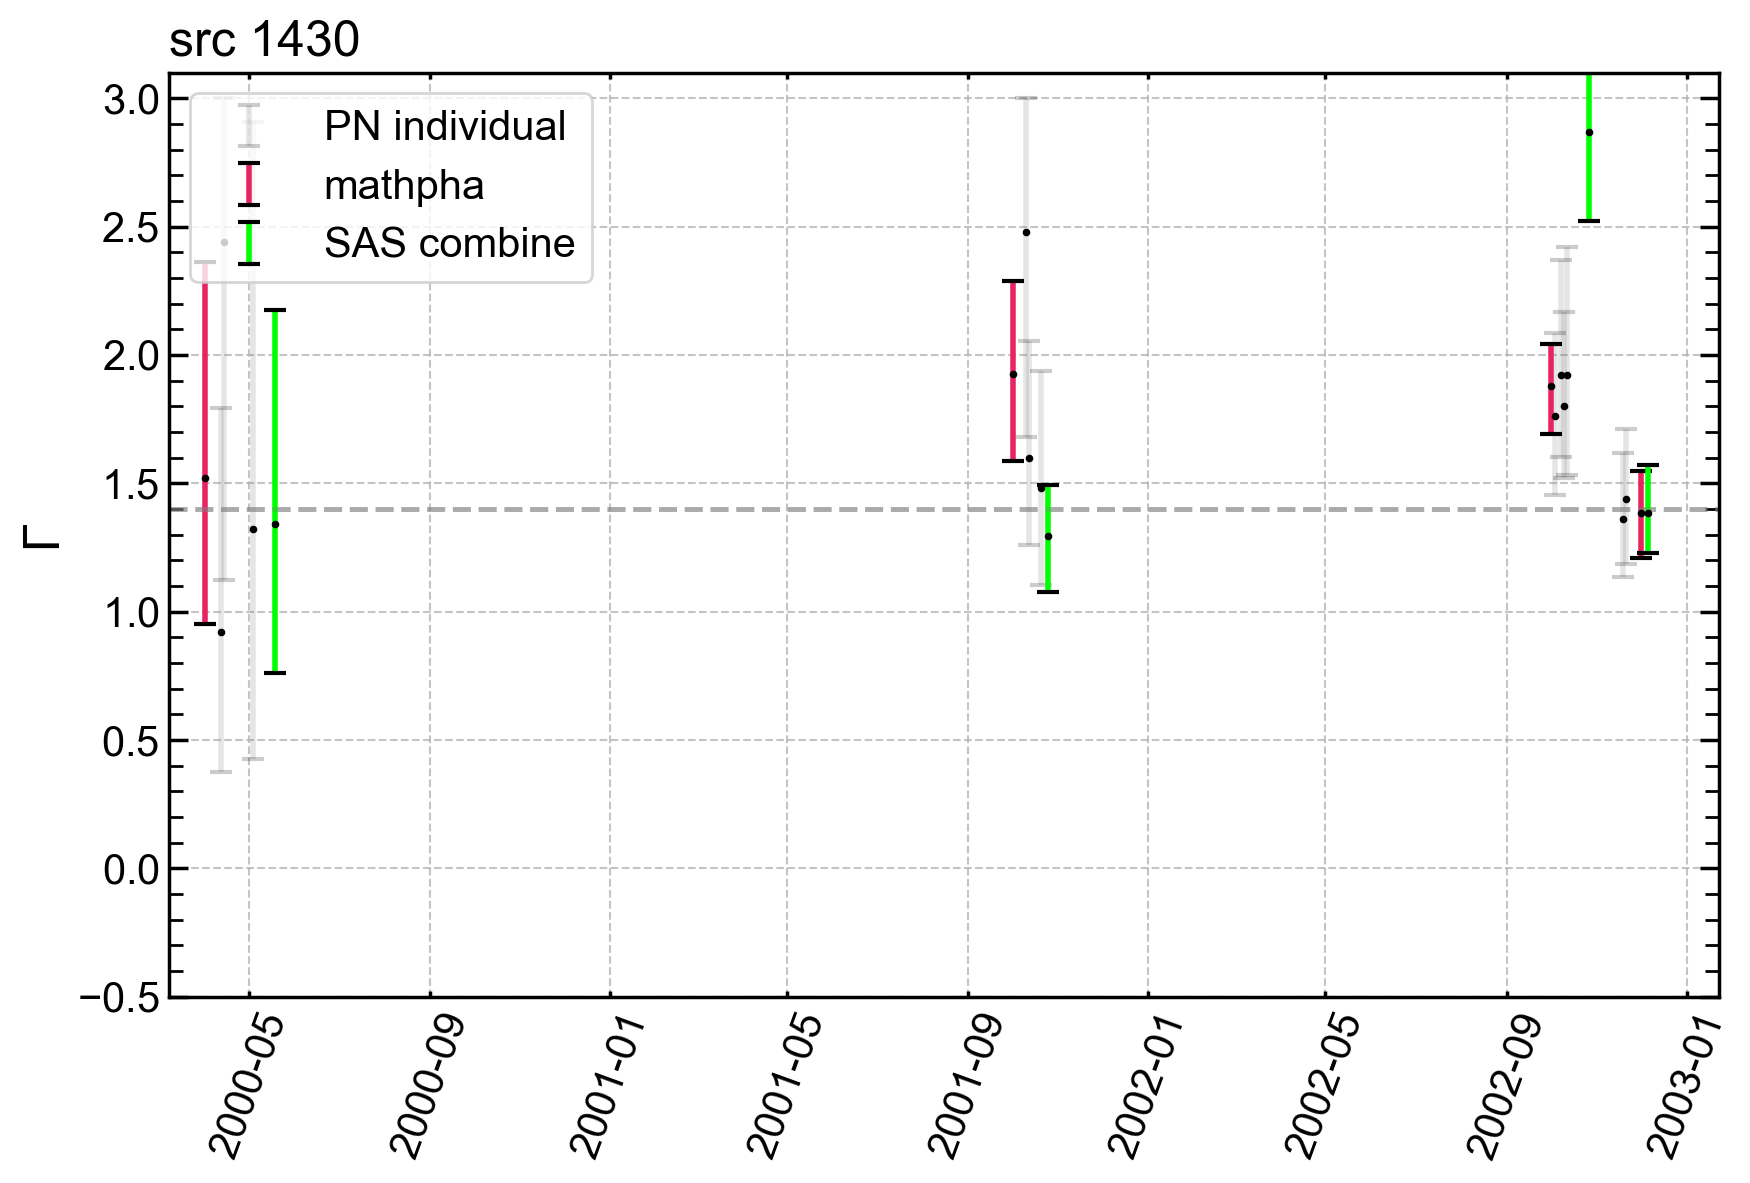

In [ ]:
src_1430_PN_df = pd.read_csv('../data/source_201237001015028_1430_individual_PN_gap30_results.csv')
ax = old_plot_date_gamma(src_1430_PN_df, "PN individual", color='gray', alpha=0.2, pad=True)

src_1430_PN_addspec_df = pd.read_csv('../data/source_201237001015028_1430_clustered_PN_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_1430_PN_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_1430_PN_sascombine_df = pd.read_csv('../data/source_201237001015028_1430_clustered_PN_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_1430_PN_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 1430', loc='left')
plt.show()

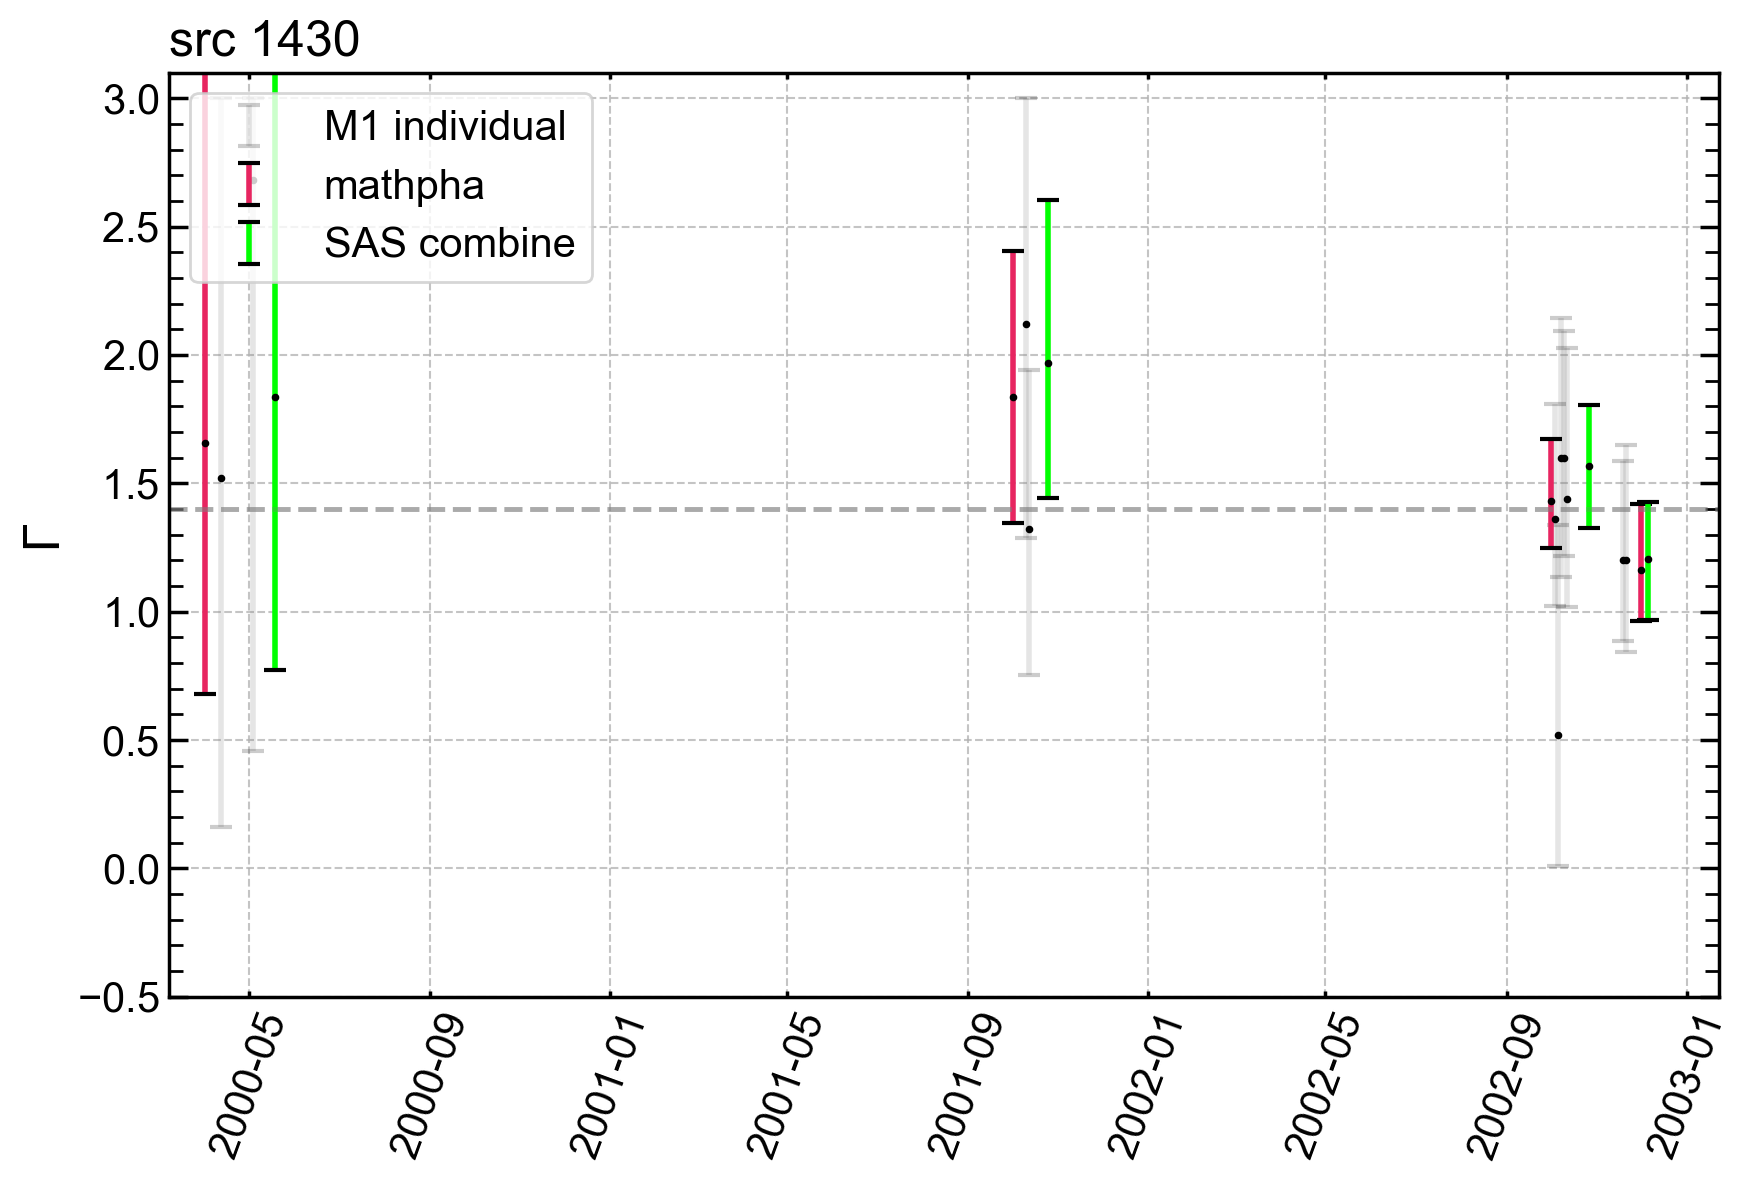

In [ ]:
src_1430_M1_df = pd.read_csv('../data/source_201237001015028_1430_individual_M1_gap30_results.csv')
ax = old_plot_date_gamma(src_1430_M1_df, "M1 individual", color='gray', alpha=0.2, pad=True)

src_1430_M1_addspec_df = pd.read_csv('../data/source_201237001015028_1430_clustered_M1_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_1430_M1_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_1430_M1_sascombine_df = pd.read_csv('../data/source_201237001015028_1430_clustered_M1_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_1430_M1_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 1430', loc='left')
plt.show()

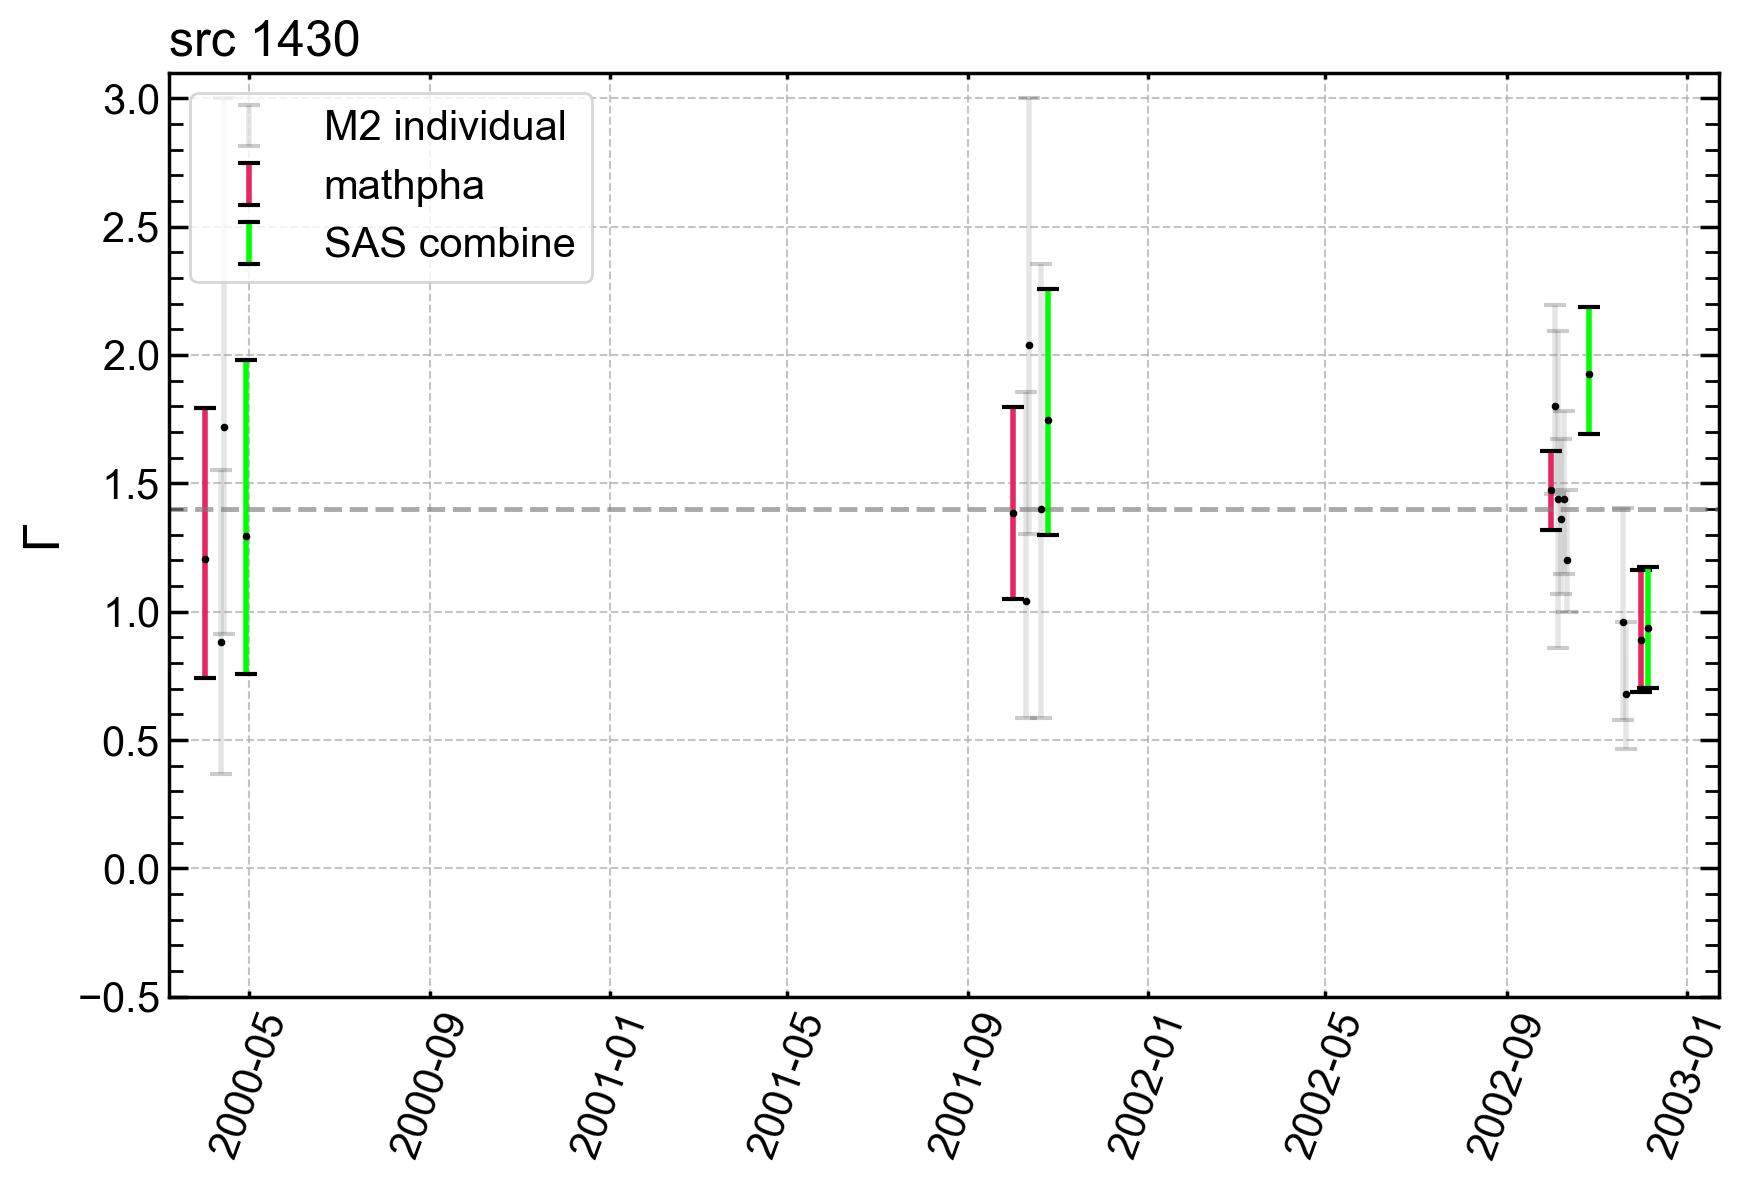

In [ ]:
src_1430_M2_df = pd.read_csv('../data/source_201237001015028_1430_individual_M2_gap30_results.csv')
ax = old_plot_date_gamma(src_1430_M2_df, "M2 individual", color='gray', alpha=0.2, pad=True)

src_1430_M2_addspec_df = pd.read_csv('../data/source_201237001015028_1430_clustered_M2_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_1430_M2_addspec_df, "mathpha", color='C1', alpha=1, ax=ax)

src_1430_M2_sascombine_df = pd.read_csv('../data/source_201237001015028_1430_clustered_M2_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_1430_M2_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 1430', loc='left')
plt.show()

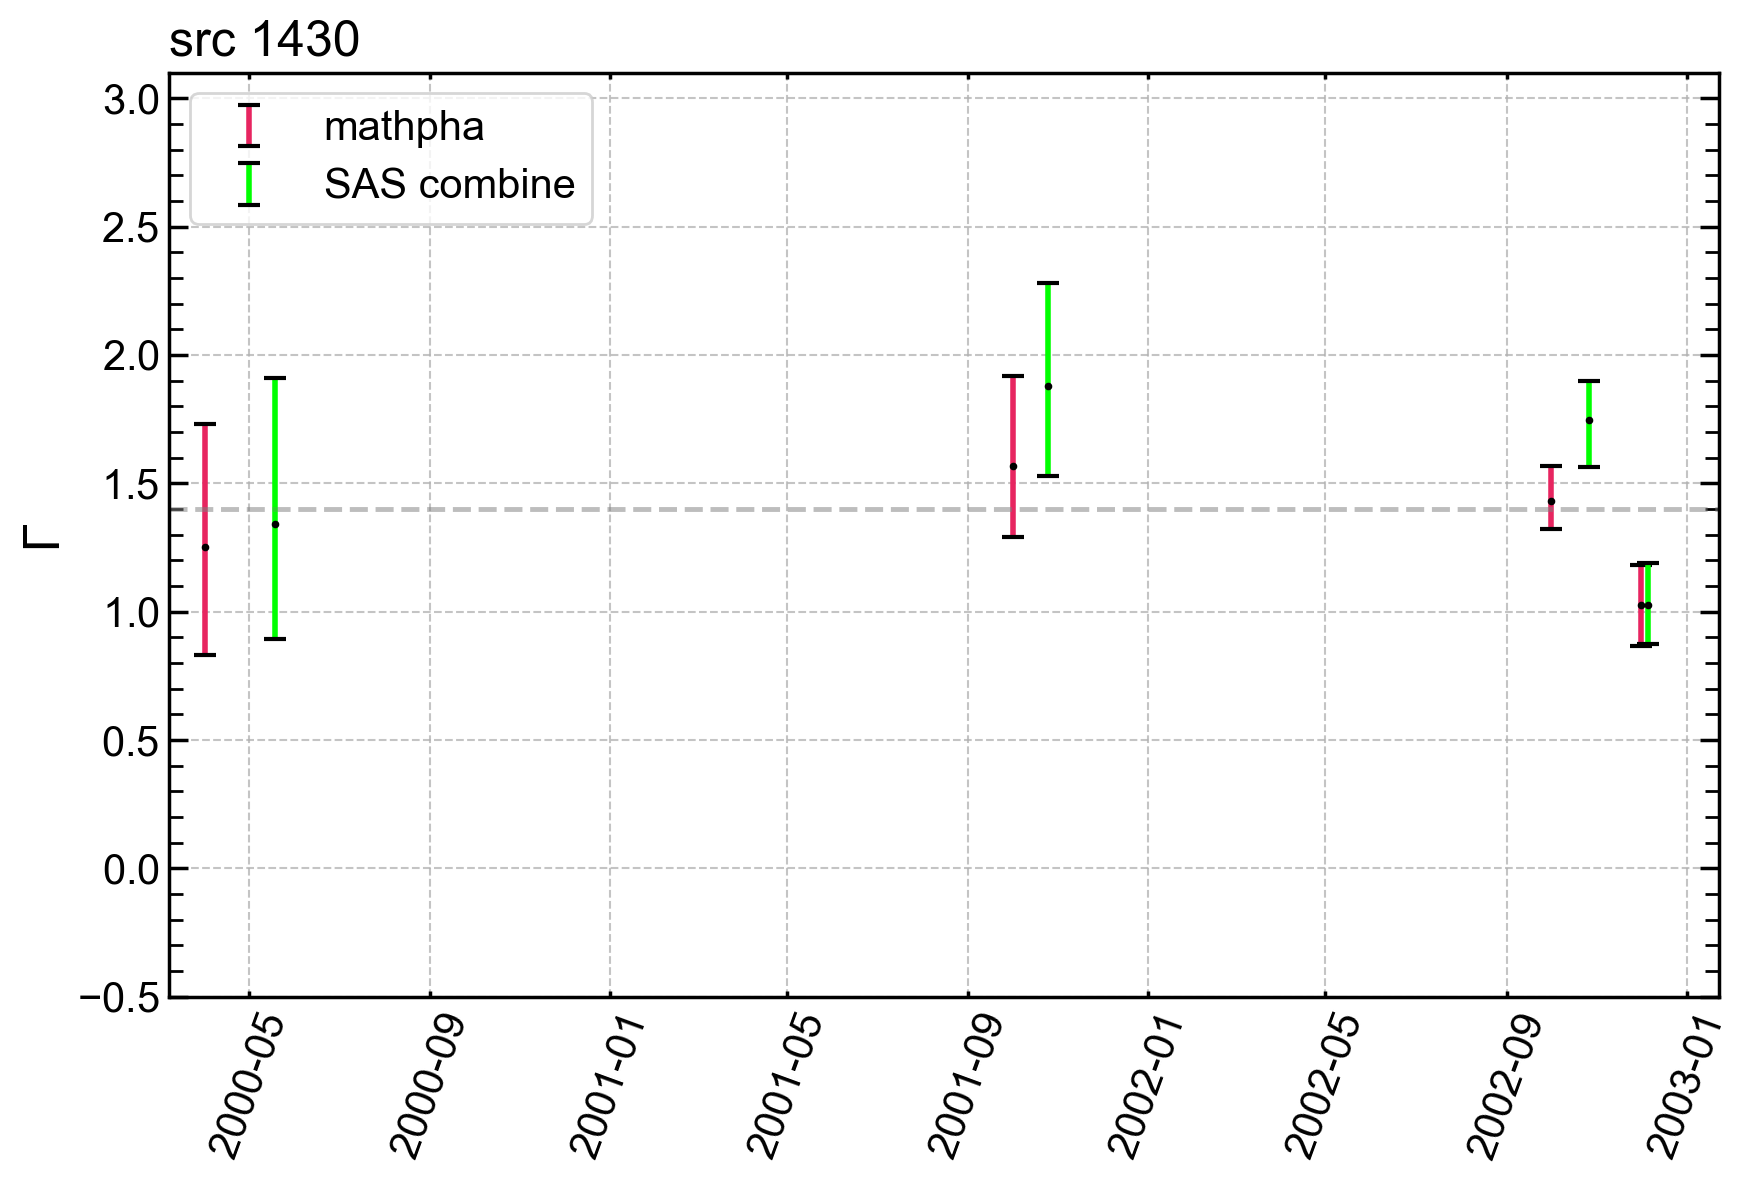

In [ ]:
# src_1430_MOS_df = pd.read_csv('../data/source_201237001015028_1430_individual_MOS_gap30_results.csv')
# ax = old_plot_date_gamma(src_1430_MOS_df, "1430 MOS", color='gray', alpha=0.2, pad=True)

src_1430_MOS_addspec_df = pd.read_csv('../data/source_201237001015028_1430_clustered_MOS_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_1430_MOS_addspec_df, "mathpha", color='C1', alpha=1)

src_1430_MOS_sascombine_df = pd.read_csv('../data/source_201237001015028_1430_clustered_MOS_gap30_epicspeccombine_results.csv')
ax = old_plot_date_gamma(src_1430_MOS_sascombine_df, "SAS combine", color='lime', alpha=1, ax=ax)

ax.set_title('src 1430', loc='left')
plt.show()

In [26]:
src_1430_pn_df = pd.read_csv('../data/source_201237001015028_1430_individual_PN_gap30_results.csv')
src_1430_m1_df = pd.read_csv('../data/source_201237001015028_1430_individual_M1_gap30_results.csv')
src_1430_m2_df = pd.read_csv('../data/source_201237001015028_1430_individual_M2_gap30_results.csv')

<Axes: ylabel='Г'>

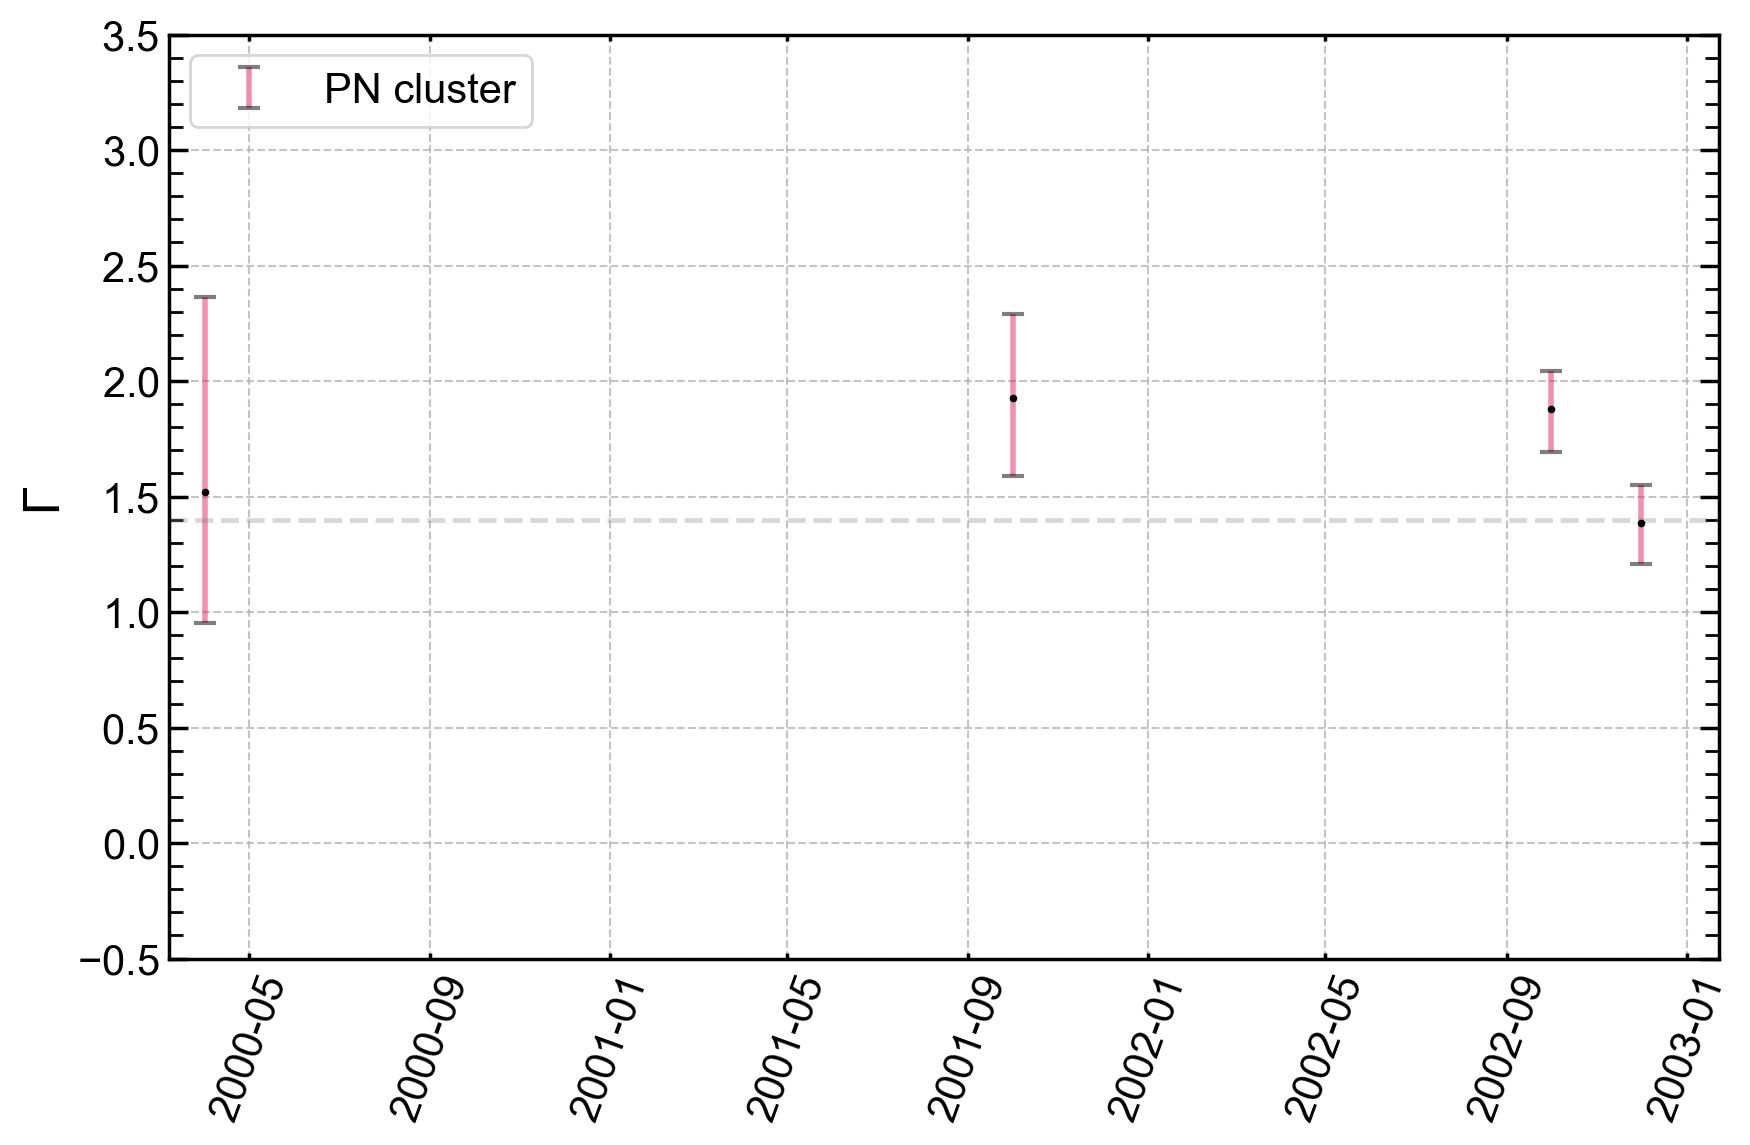

In [ ]:
src_1430_pn_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_PN_gap30_addspec_results.csv'
)

old_plot_date_gamma(src_1430_pn_clustered_df, 'PN cluster', 'C1', uplim=3.5)

<Axes: ylabel='Г'>

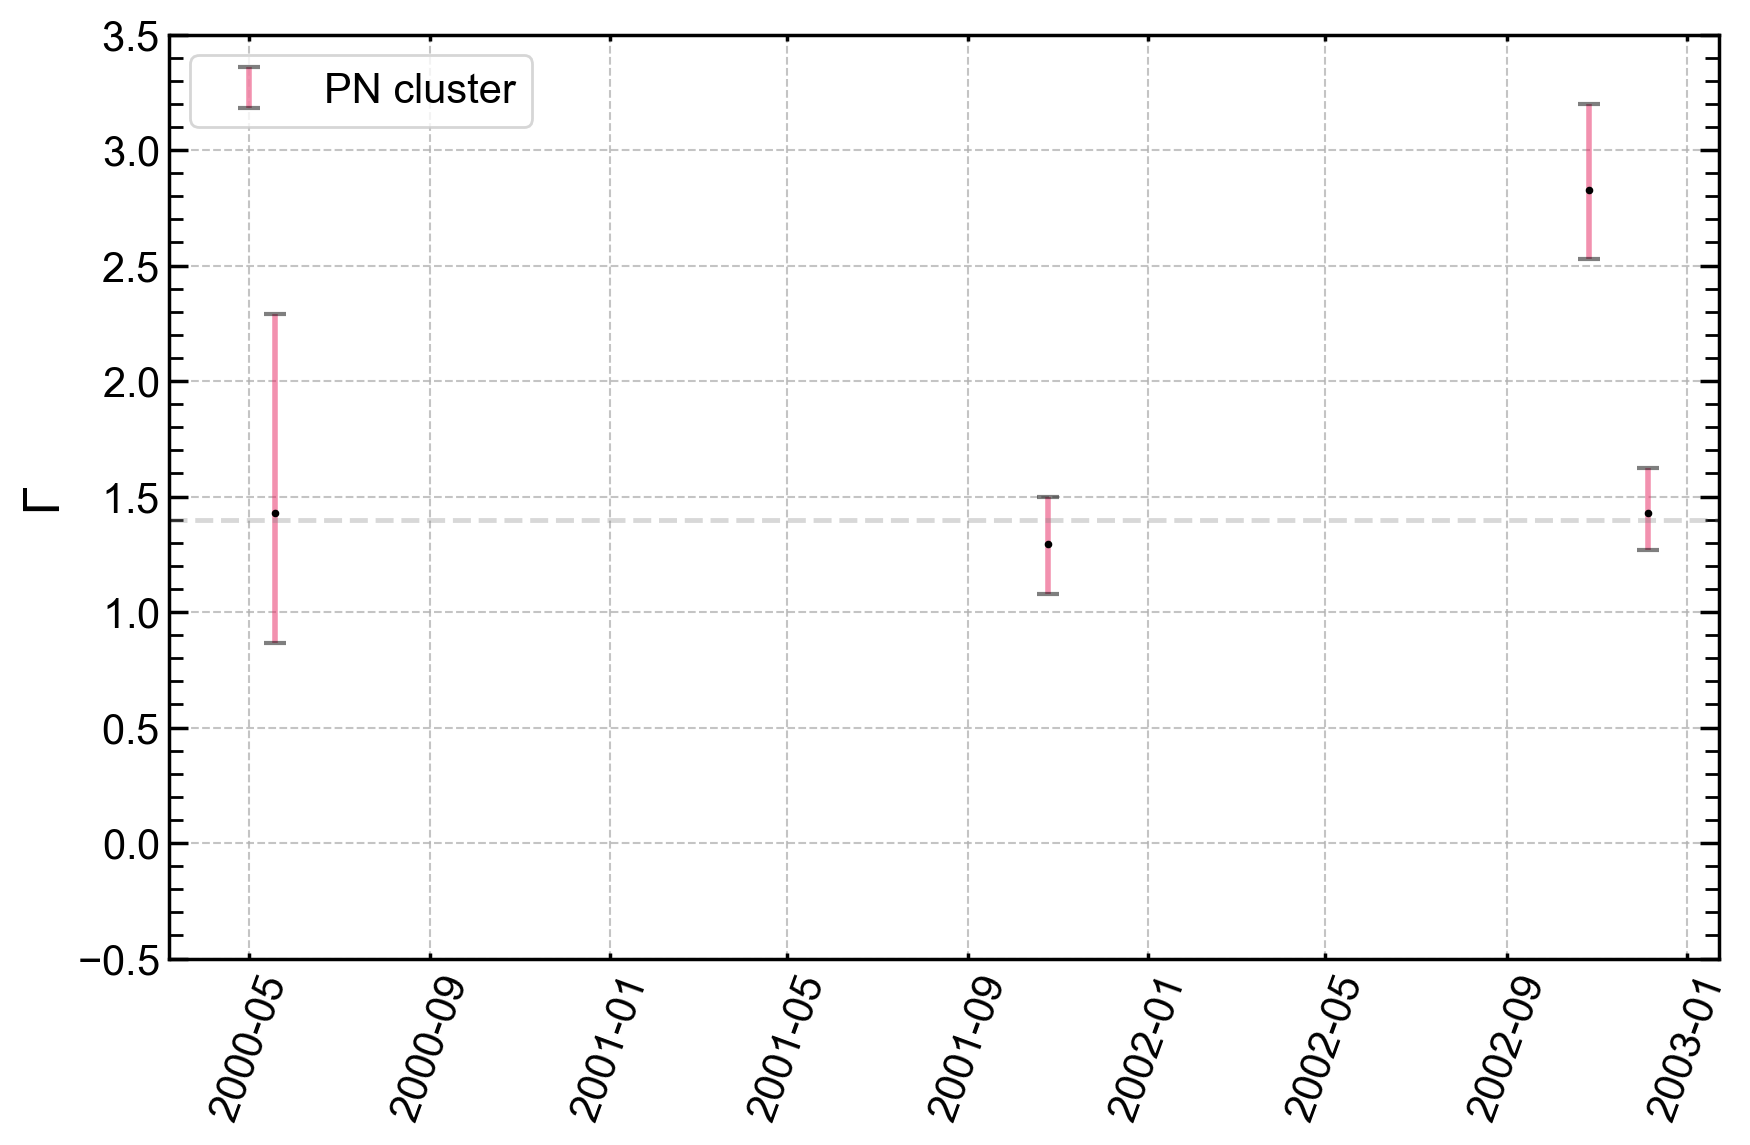

In [ ]:
src_1430_pn_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_PN_gap30_wide_step_results.csv'
)

old_plot_date_gamma(src_1430_pn_clustered_df, 'PN cluster', 'C1', uplim=3.5)

<Axes: ylabel='Г'>

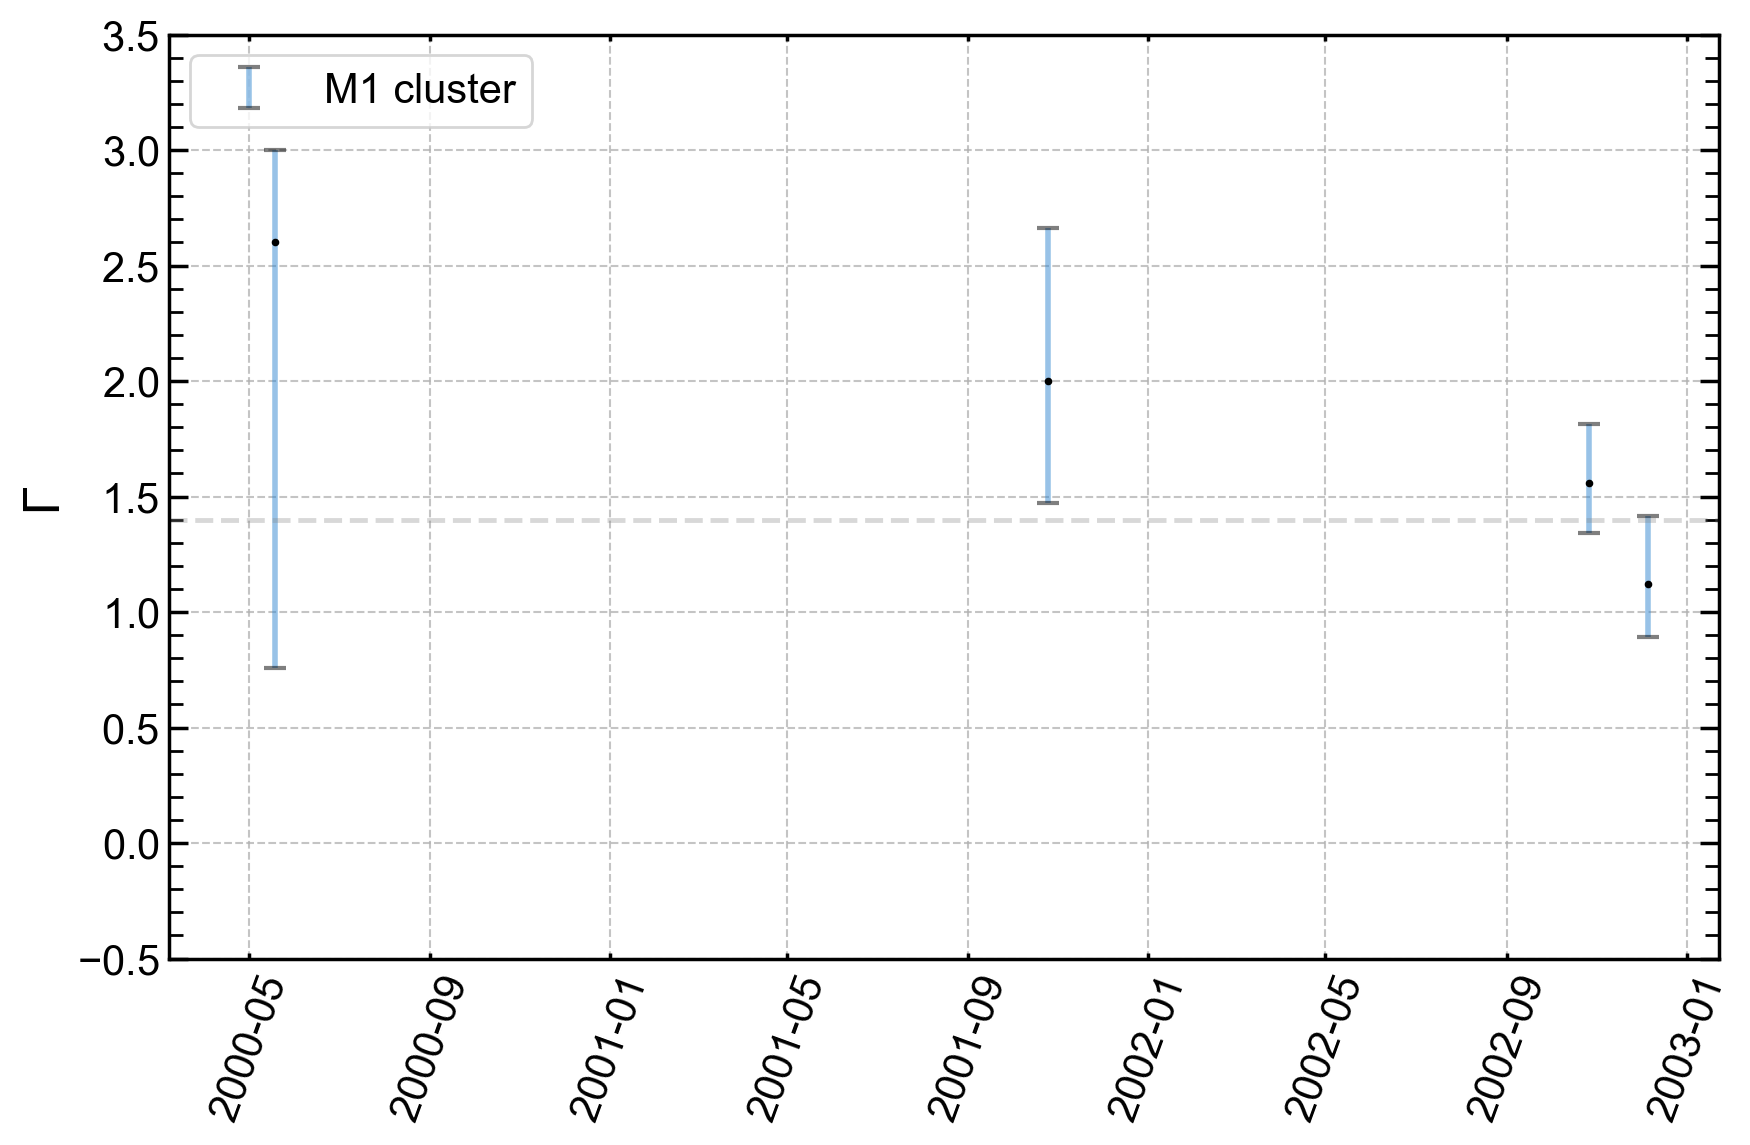

In [ ]:
src_1430_M1_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_M1_gap30_results.csv'
)

old_plot_date_gamma(src_1430_M1_clustered_df, 'M1 cluster', 'C0', uplim=3.5)

<Axes: ylabel='Г'>

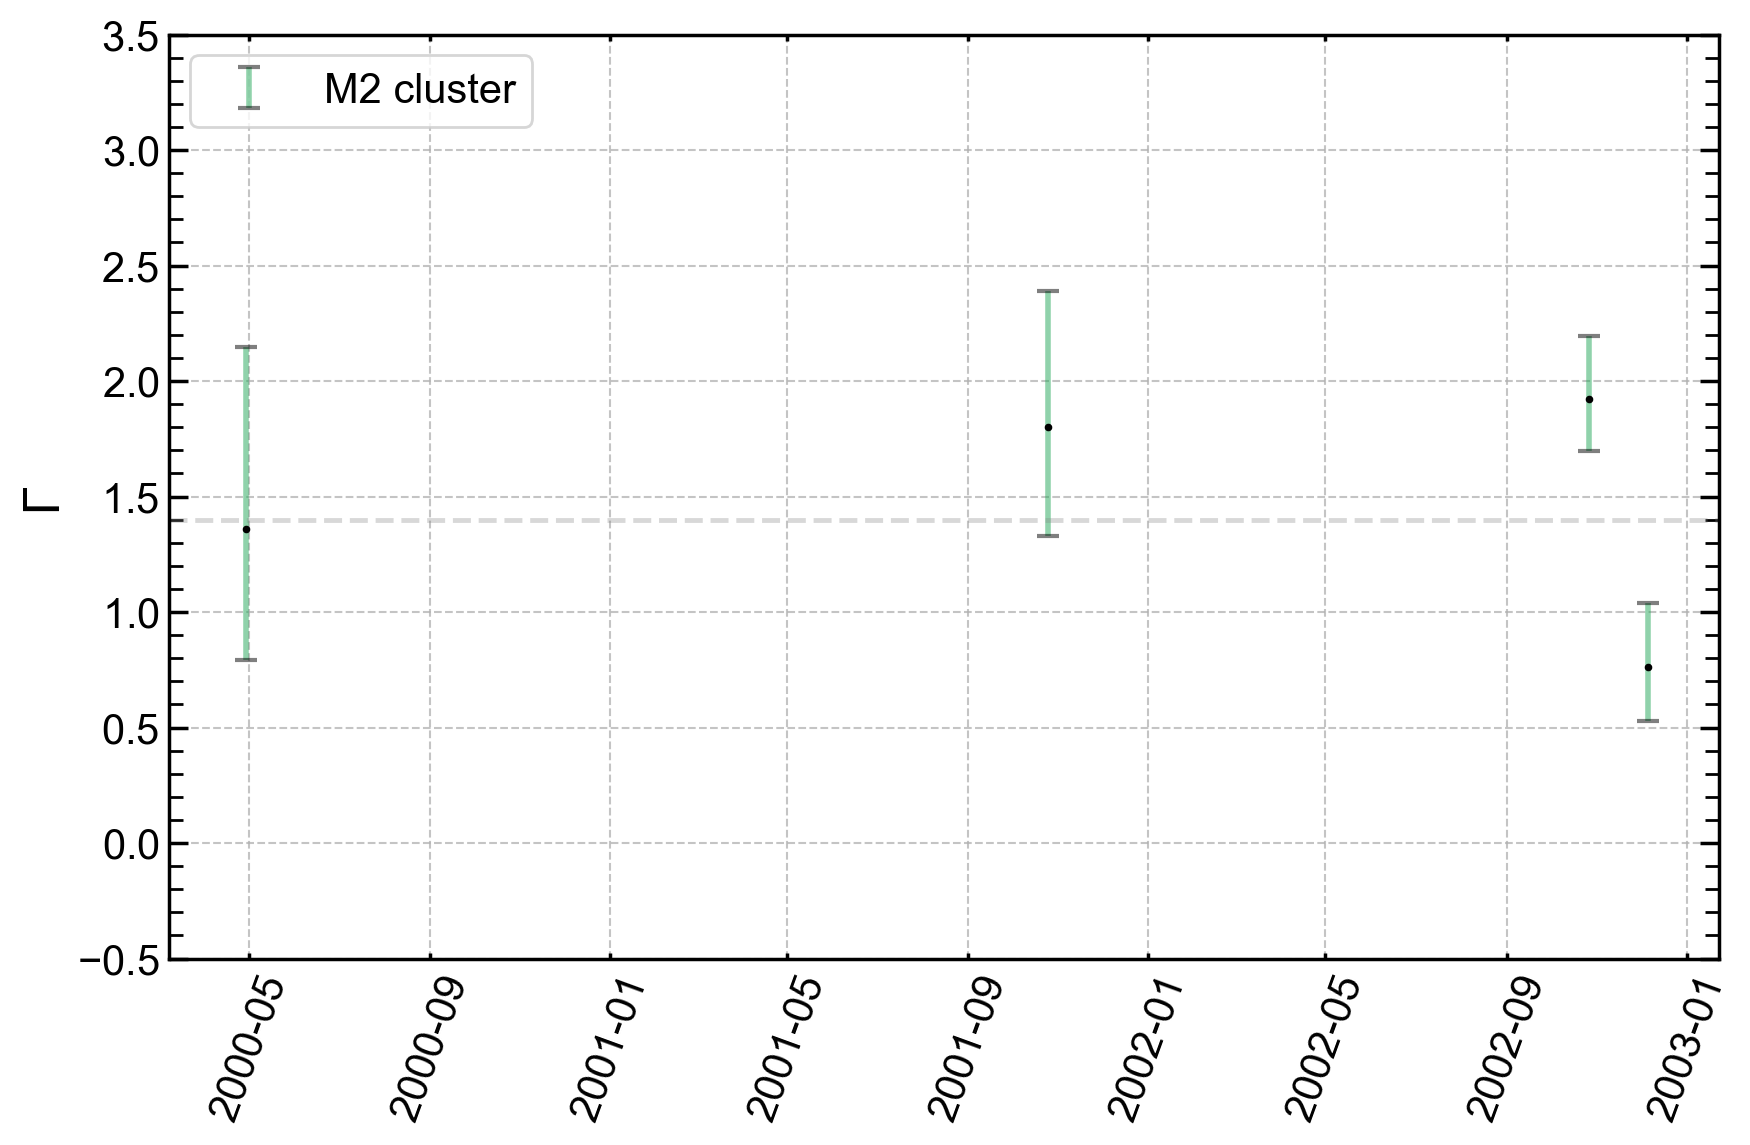

In [ ]:
src_1430_M2_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_M2_gap30_results.csv'
)

old_plot_date_gamma(src_1430_M2_clustered_df, 'M2 cluster', 'C2', uplim=3.5)

<Axes: ylabel='Г'>

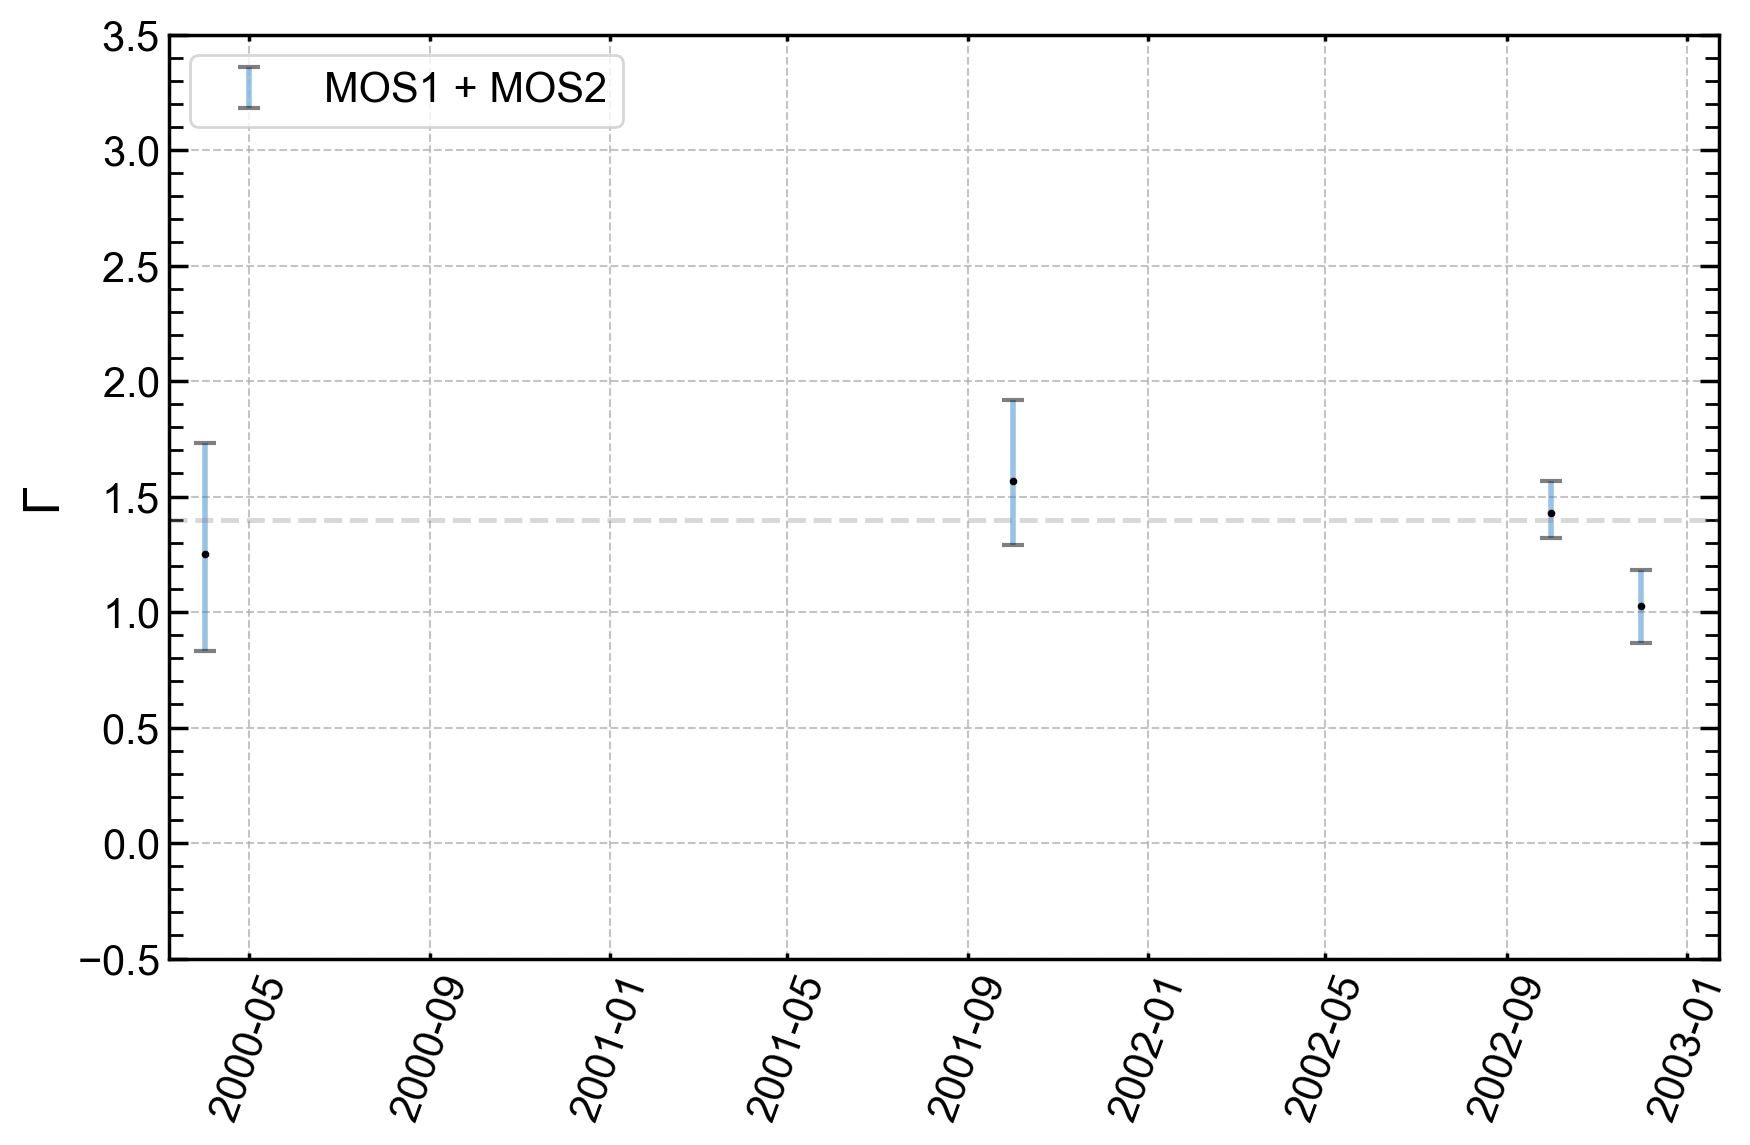

In [ ]:
src_1430_MOS_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_MOS_gap30_addspec_results.csv'
)

old_plot_date_gamma(src_1430_MOS_clustered_df, 'MOS1 + MOS2', 'C0', uplim=3.5)

<Axes: ylabel='Г'>

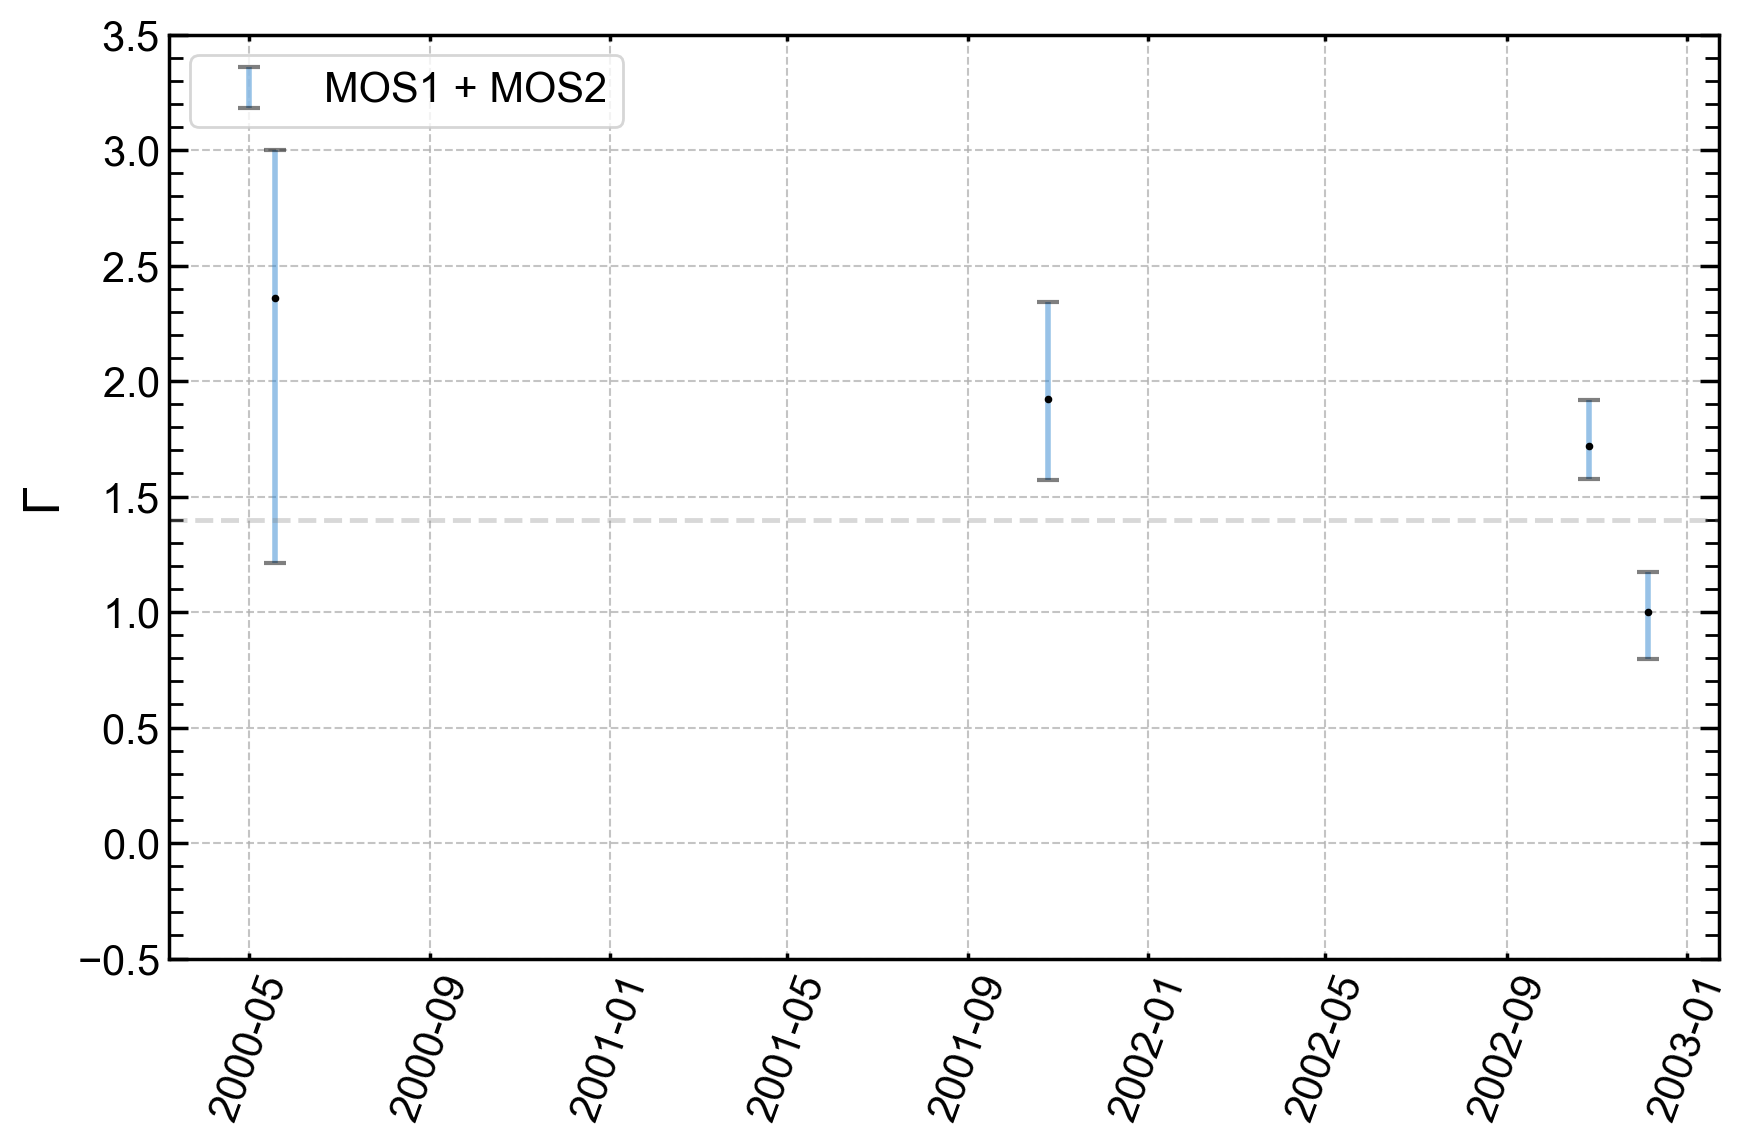

In [ ]:
src_1430_MOS_clustered_df = pd.read_csv(
    '../data/source_201237001015028_1430_clustered_MOS_gap30_results.csv'
)

old_plot_date_gamma(src_1430_MOS_clustered_df, 'MOS1 + MOS2', 'C0', uplim=3.5)

In [33]:
pn_dates_df = pd.read_pickle('/Users/mike/Yandex.Disk.localized/Работа/ИКИ/Y.repos/lh_obscurus/data/xmm_spectra/srcid_1430/mo2_fit_individual_only_2d_steppar_PN_flux_etc_eRASS_2.pkl')
pn_df = pd.read_pickle('/Users/mike/Yandex.Disk.localized/Работа/ИКИ/Y.repos/lh_obscurus/data/xmm_spectra/srcid_1430/1430_mo2_fit_2d_steppar_hd.pkl')

pn_df.columns = [
    'mo2_nH_step_2d', 'mo2_nH_step_2d_perr', 'mo2_nH_step_2d_nerr',
    'mo2_PhoIndex_step_2d', 'mo2_PhoIndex_step_2d_perr', 'mo2_PhoIndex_step_2d_nerr',
    ]

pn_df['date_obs'] = pn_dates_df[1:]['date_obs'].values
pn_df['flux'] = pn_dates_df[1:]['flux'].values
pn_df['flux_nerr'] = pn_dates_df[1:]['flux_nerr'].values
pn_df['flux_perr'] = pn_dates_df[1:]['flux_perr'].values

pn_df

,mo2_nH_step_2d,mo2_nH_step_2d_perr,mo2_nH_step_2d_nerr,mo2_PhoIndex_step_2d,mo2_PhoIndex_step_2d_perr,mo2_PhoIndex_step_2d_nerr,date_obs,flux,flux_nerr,flux_perr
0,1.135237,0.961319,0.617911,1.385714,0.483021,0.390077,2000-04-27 03:34:45,5.873586e-15,4.034901e-15,6.313091e-15
0,1.191759,0.436537,0.352293,1.614286,0.219312,0.209117,2001-10-27 19:10:18,1.250138e-14,1.148761e-14,1.311962e-14
0,0.497001,0.126184,0.126085,1.214286,0.092534,0.085680,2002-11-27 23:26:55,1.184899e-14,1.137758e-14,1.219247e-14


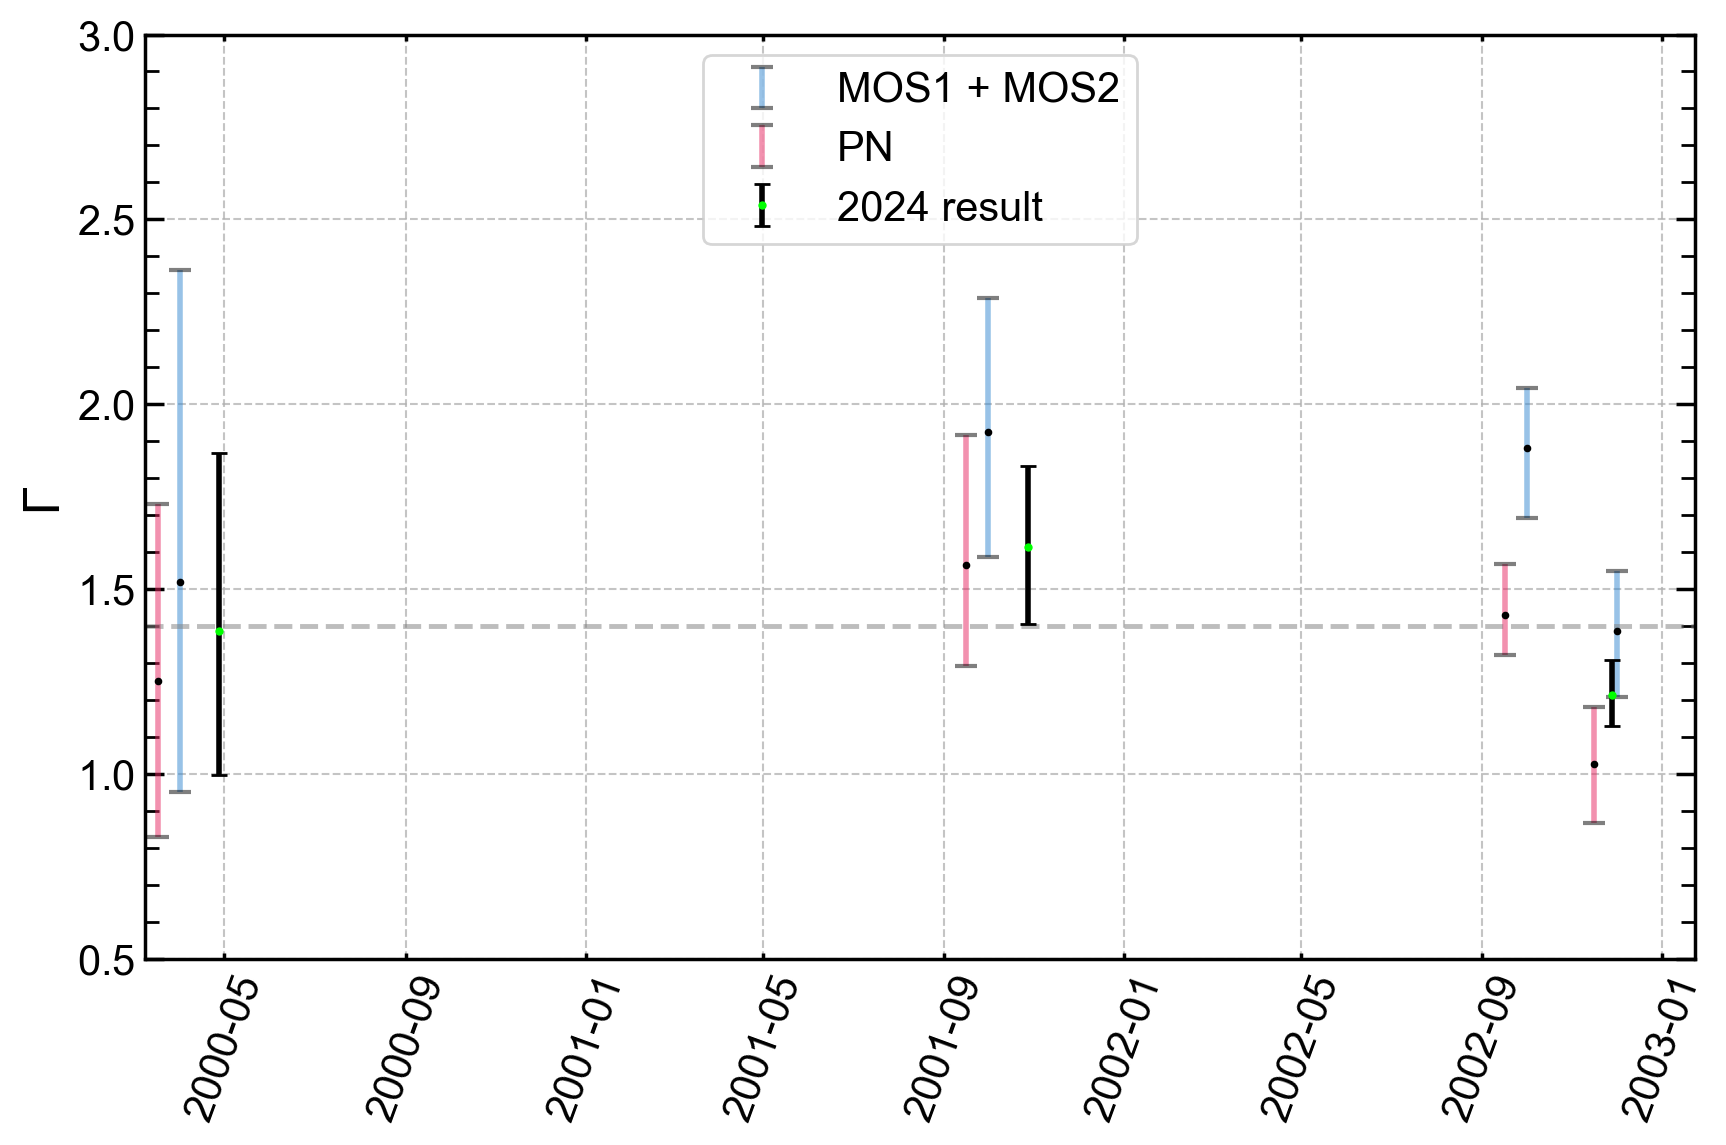

In [ ]:
src_1430_MOS_df = pd.read_csv('../data/source_201237001015028_1430_clustered_PN_gap30_addspec_results.csv')
ax = old_plot_date_gamma(src_1430_MOS_df, 'MOS1 + MOS2', color='C0', uplim=3)

src_1430_PN_df = pd.read_csv('../data/source_201237001015028_1430_clustered_MOS_gap30_addspec_results.csv')
ax = old_plot_date_gamma(
    src_1430_PN_df, "PN", color='C1', ax=ax, pad=True, lolim=0.5, uplim=3
    )

ax.errorbar(
    x=pn_df['date_obs'], y=pn_df['mo2_PhoIndex_step_2d'],
    yerr=[pn_df['mo2_PhoIndex_step_2d_nerr'], pn_df['mo2_PhoIndex_step_2d_perr']],
    fmt='o', markersize=3, color='lime', capsize=3, capthick=1, ecolor='k', lw=2,
    label='2024 result'
    )

ax.legend(loc='upper center')

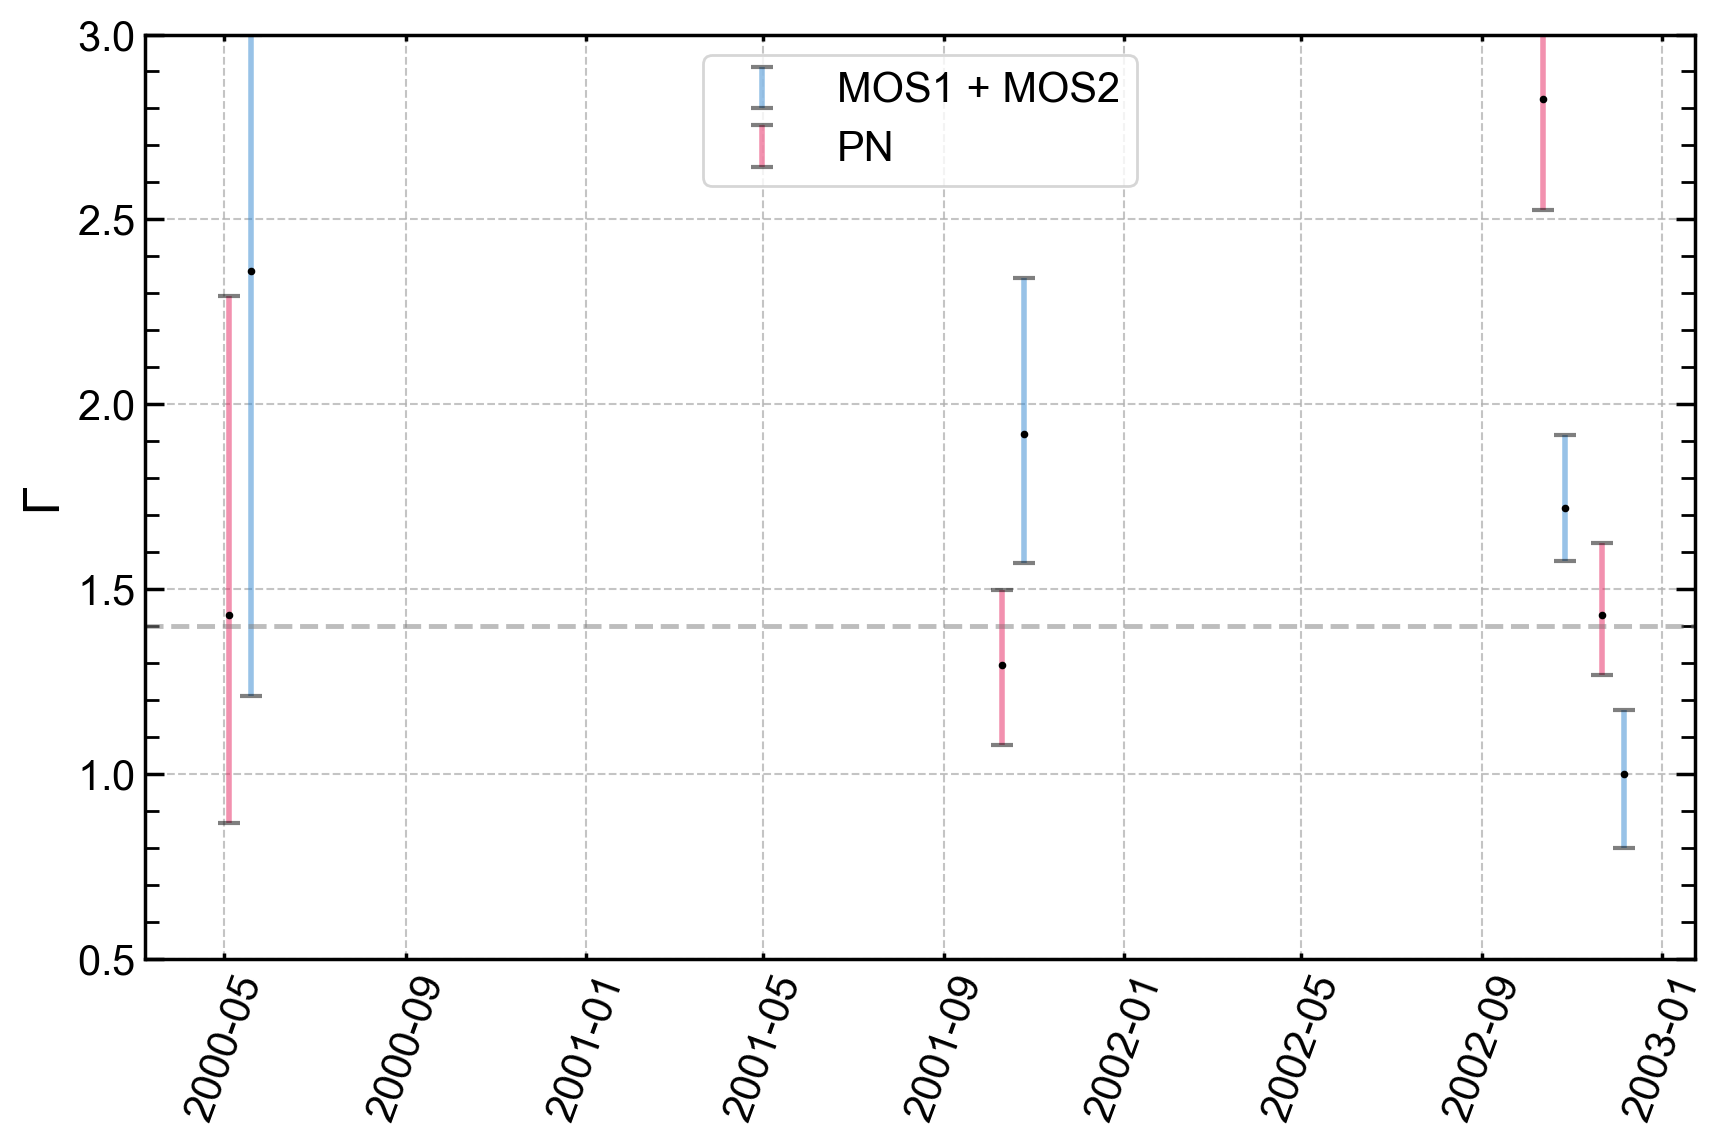

In [ ]:
src_1430_MOS_df = pd.read_csv('../data/source_201237001015028_1430_clustered_MOS_gap30_results.csv')
ax = old_plot_date_gamma(src_1430_MOS_df, 'MOS1 + MOS2', color='C0', uplim=3)

src_1430_PN_df = pd.read_csv('../data/source_201237001015028_1430_clustered_PN_gap30_wide_step_results.csv')
ax = old_plot_date_gamma(
    src_1430_PN_df, "PN", color='C1', ax=ax, pad=True, lolim=0.5, uplim=3
    )

# ax.errorbar(
#     x=pn_df['date_obs'], y=pn_df['mo2_PhoIndex_step_2d'],
#     yerr=[pn_df['mo2_PhoIndex_step_2d_nerr'], pn_df['mo2_PhoIndex_step_2d_perr']],
#     fmt='o', markersize=3, color='lime', capsize=3, capthick=1, ecolor='k', lw=2,
#     label='2024 result'
#     )

ax.legend(loc='upper center')

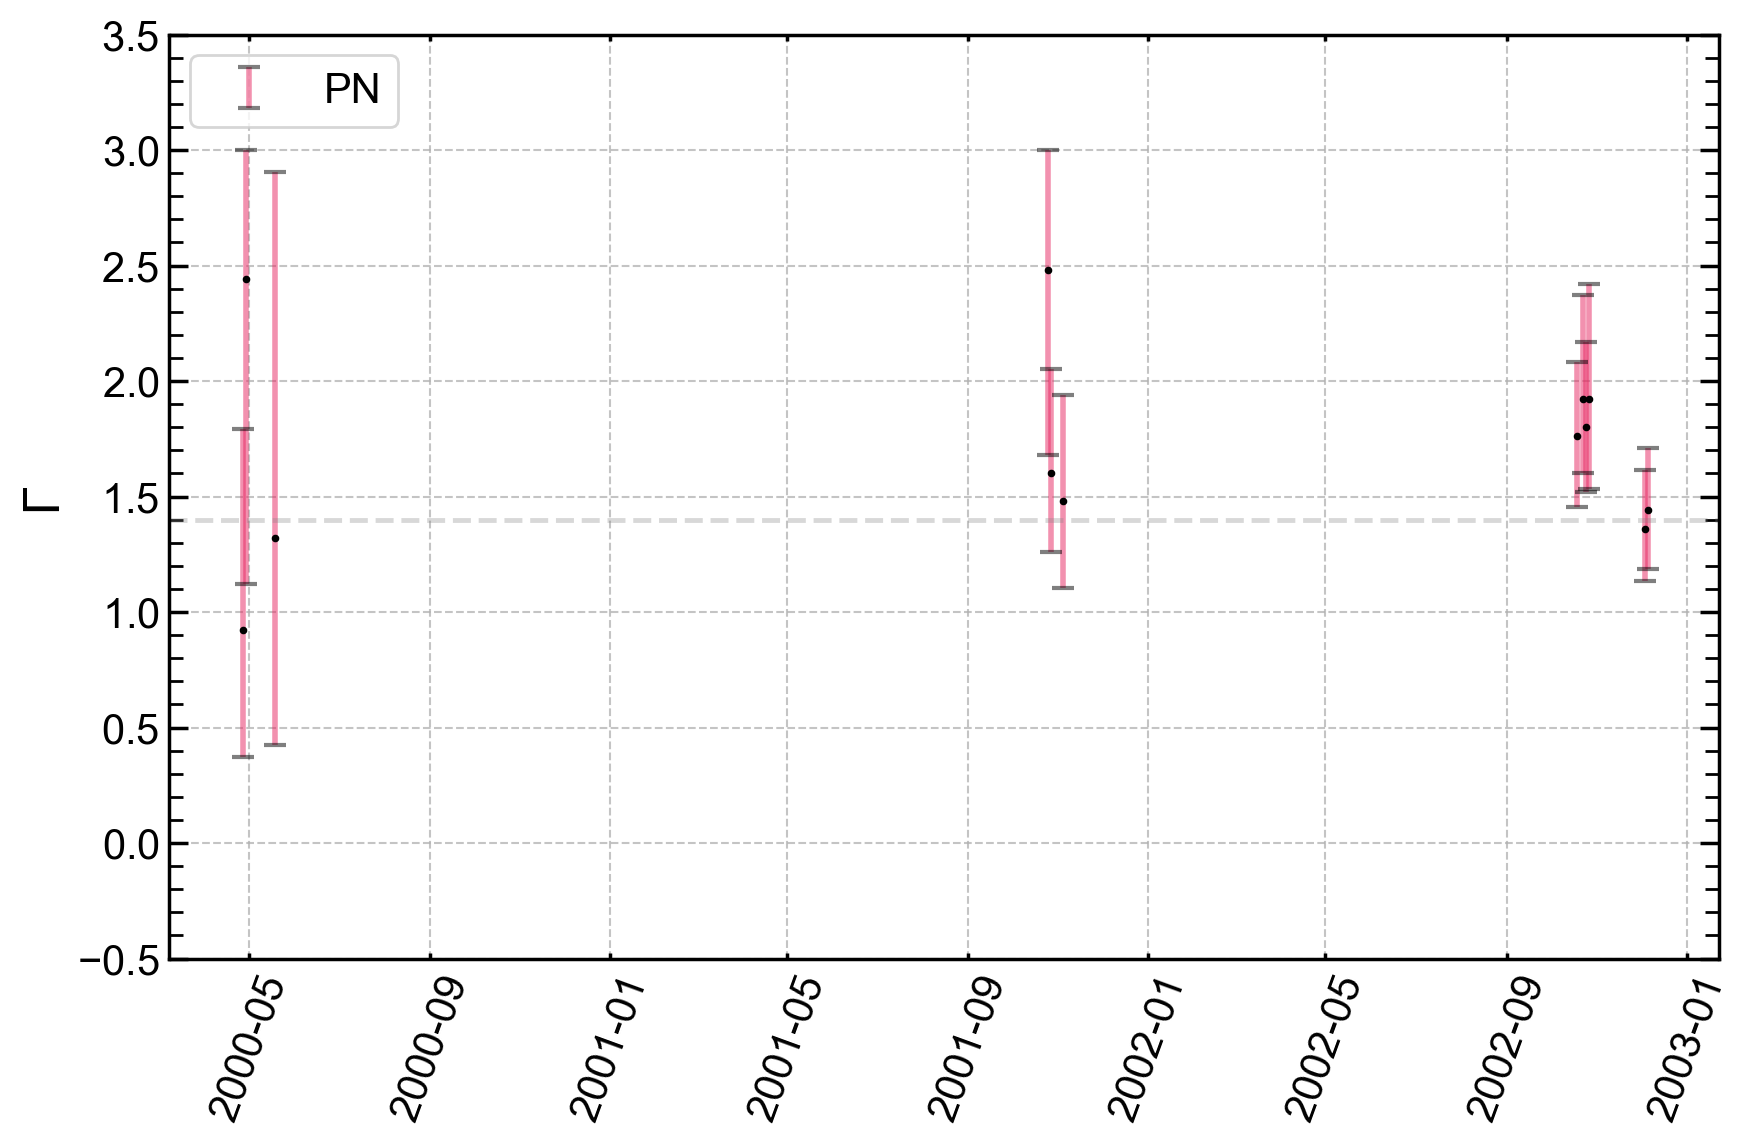

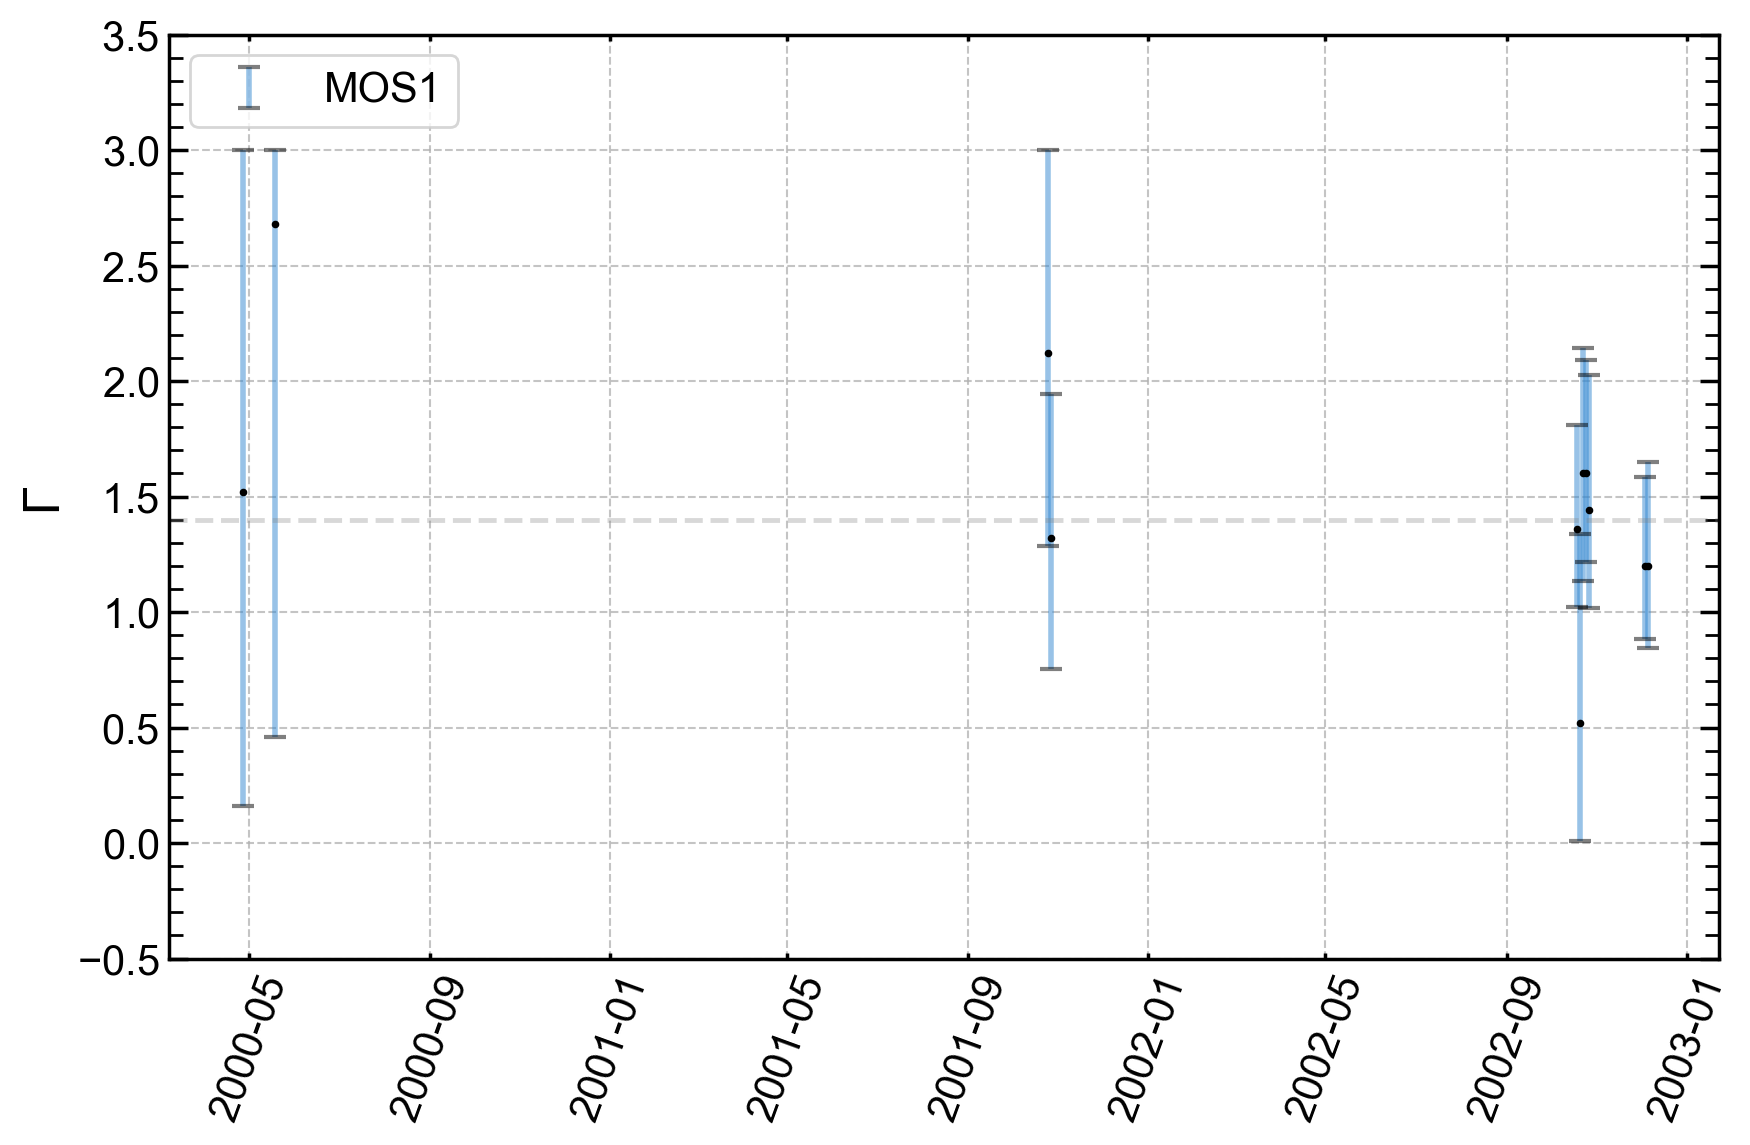

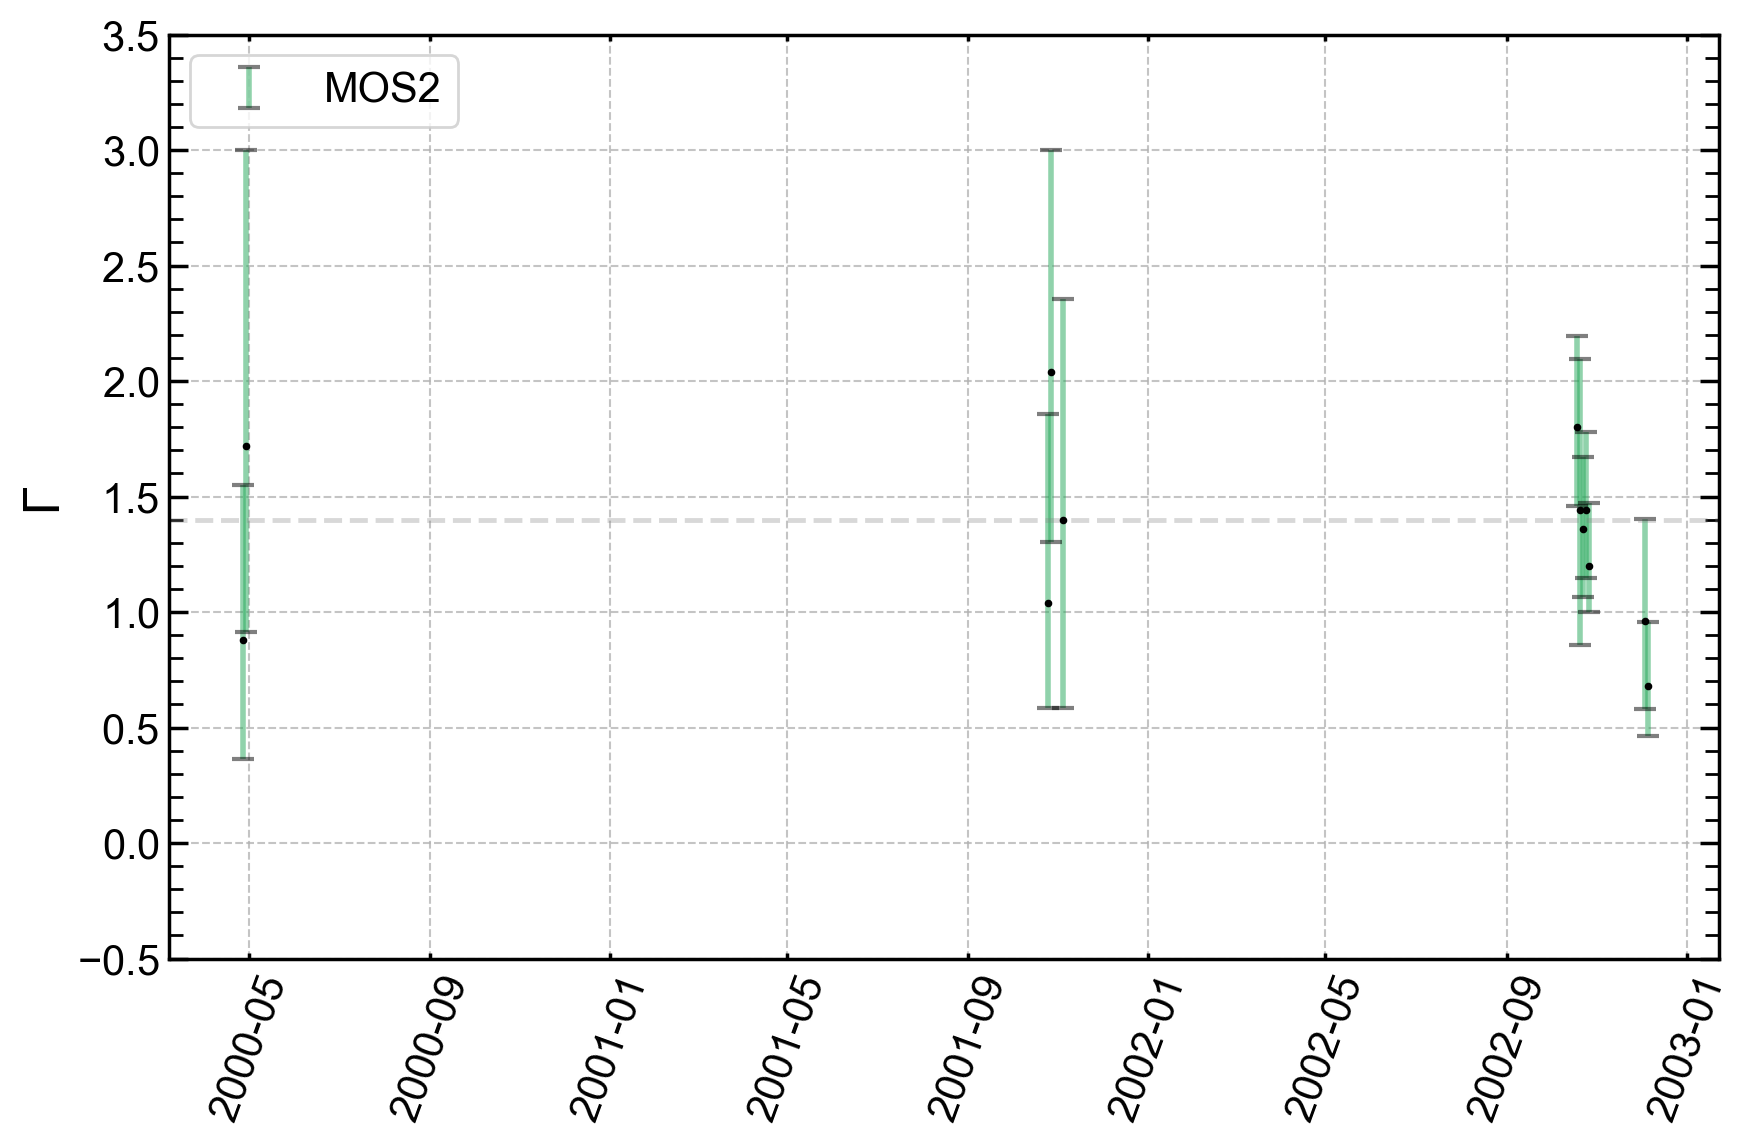

In [ ]:
for df, title, color in zip(
    [src_1430_pn_df, src_1430_m1_df, src_1430_m2_df],
    ['PN', 'MOS1', 'MOS2'],
    ['C1', 'C0', 'C2']
):

    old_plot_date_gamma(df, title, color, uplim=3.5)